In [1]:
#%pip install scienceplots

In [2]:
# TODO: Y_EU is 0 for some. Is that reasonable?
# TODO: The diagonal wedges seem to be all 1. Is that correct?

In [3]:
# Plots to add
# - share of countries winning and losing. Maybe hist with coloured bars

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd
# import scienceplots

plt.rcParams['text.usetex'] = False
# plt.style.use(["science", "nature", "no-latex"])
# use seaborn whitegrid style
plt.style.use("seaborn-v0_8-whitegrid")

# Default size for all plots
plt.rcParams["figure.figsize"] = (9, 6)
# Set default cmap to viridis
CMAP = "viridis"
plt.rcParams["image.cmap"] = CMAP
# Slightly larger default title size
plt.rcParams["axes.titlesize"] = 14
# set default grid to alpha 0.3
plt.rcParams["axes.grid"] = False
plt.rcParams["grid.alpha"] = 0.3

In [5]:
FINANCIAL_CENTRES = ["IRL", "MLT", "CYP", "LUX"]

EU27 = [
    "AUT","BEL","BGR","CZE","DNK","EST","FIN","FRA","DEU","GRC",
    "HUN","ITA","LVA","LTU","NLD","POL","PRT","ROU","SVK",
    "SVN","ESP","SWE",
    # "HRV", # missing data
]

EU27 += ["CYP","IRL","LUX"]
EU27 += ["MLT"]

OUTSIDE   = ["GBR","CHE","NOR"]
COUNTRIES = EU27 + OUTSIDE          # USA excluded; n = 31

In [6]:
# View excel sheets
xls = pd.ExcelFile('v4-simulation.xlsx')
xls.sheet_names

['Config',
 'Gravity_Coefficients',
 'Macro_Variables',
 'Wedge_Hard',
 'Wedge_Immutable',
 'Wedge_SoftPolicy',
 'Wedge_Baseline',
 'Portfolio_Data',
 'Portfolio_Baseline',
 'Capital_Reallocation',
 'Financial_Capital_Decomposition',
 'EU_Summary',
 'Output_Country',
 'Country_Detail_Main',
 'MPK_Dispersion',
 'Robustness',
 'Portfolio_CMU_Snapshots',
 'Portfolio_Flows']

In [7]:
# Load the main country-level output sheet — used for all plotting
df_output_country = pd.read_excel(xls, 'Output_Country')
df_output_country_EU = df_output_country[df_output_country['in_EU27'] == 1].copy()
print(f"Output_Country: {df_output_country.shape[0]:,} rows, {df_output_country.shape[1]} columns")
print(f"EU27 subset:    {df_output_country_EU.shape[0]:,} rows")
df_output_country.head(2)

Output_Country: 232,000 rows, 50 columns
EU27 subset:    208,000 rows


,theta,omega,gamma,country,in_EU27,is_financial_ctr,alpha,A_bar,L,R_normalised,...,y_cmu_pc,dy_pc_pct,capital_effect_pct,tfp_amplification_pct,total_effect_pct,capital_share_of_dy,mpk_baseline,mpk_cmu,dmpk,dmpk_pct
0,0.0,0.0,0.0,AUT,1,0,0.395158,618.170824,4.524948,0.796871,...,124295.112195,0.0,0.0,0.0,0.0,NaN,0.072827,0.072827,0.0,0.0
1,0.0,0.0,0.0,BEL,1,0,0.403642,553.122029,4.880036,0.764741,...,130243.048615,0.0,0.0,0.0,0.0,NaN,0.069891,0.069891,0.0,0.0


In [8]:
df_output_country["country"].unique()

array(['AUT', 'BEL', 'BGR', 'CHE', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP',
       'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HUN', 'IRL', 'ITA', 'LTU',
       'LUX', 'LVA', 'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SVK',
       'SVN', 'SWE'], dtype=object)

In [9]:
# Define the central scenario values of CMU
# impact and therefore central scenario values
# of omega, gamma, theta
_CMU_OMEGA = 0.3
_CMU_GAMMA = 0.1
_CMU_THETA = 0.03

# Now load and get the nearest ones from the real
# dataset. Since we have a grid between 0 and 1.
df_eu_summary = pd.read_excel(xls, 'EU_Summary')

gammas = df_eu_summary['gamma'].unique()
omegas = df_eu_summary['omega'].unique()
thetas = df_eu_summary['theta'].unique()

CMU_OMEGA = omegas[np.argmin(np.abs(omegas - _CMU_OMEGA))]
CMU_GAMMA = gammas[np.argmin(np.abs(gammas - _CMU_GAMMA))]
CMU_THETA = thetas[np.argmin(np.abs(thetas - _CMU_THETA))]

print(f"Central scenario omega: {CMU_OMEGA}")
print(f"Central scenario gamma: {CMU_GAMMA}")
print(f"Central scenario theta: {CMU_THETA}")

Central scenario omega: 0.316
Central scenario gamma: 0.105
Central scenario theta: 0.032


In [10]:
EU27 = [
    "AUT","BEL","BGR","CZE","DNK","EST","FIN","FRA","DEU","GRC",
    "HUN","ITA","LVA","LTU","NLD","POL","PRT","ROU","SVK",
    "SVN","ESP","SWE",
] # "HRV",

EU27 += ["CYP","MLT","IRL","LUX"]
OUTSIDE   = ["GBR","CHE","NOR"] # "USA",
COUNTRIES = EU27 + OUTSIDE          # n = 31

## Gravity

In [11]:
# Load the ppml output table from excel
df_grav = pd.read_excel(xls, 'Gravity_Coefficients')
df_grav

,regressor,coeff_scaled,coeff_original,std_error,t_stat,p_value,CI_lower,CI_upper
0,Intercept,3.922292,3.922292,3.708855,1.057548,2.902615e-01,-3.346930,11.191514
1,C(year)[T.2016],-0.149287,-0.149287,0.039829,-3.748223,1.780919e-04,-0.227351,-0.071224
2,C(year)[T.2017],-0.033394,-0.033394,0.034248,-0.975059,3.295308e-01,-0.100520,0.033731
3,C(year)[T.2018],-0.125388,-0.125388,0.036821,-3.405357,6.607769e-04,-0.197556,-0.053221
4,C(year)[T.2019],-0.018500,-0.018500,0.043979,-0.420651,6.740100e-01,-0.104696,0.067697
5,C(year)[T.2020],0.234186,0.234186,0.047385,4.942186,7.725145e-07,0.141313,0.327060
6,d_ling,-2.040674,-2.040674,0.447323,-4.561973,5.067506e-06,-2.917410,-1.163938
7,d_num_articles,-7.189846,-7.189846,3.575466,-2.010883,4.433778e-02,-14.197631,-0.182060
8,d_financial_development_index,-4.215422,-4.215422,0.921090,-4.576557,4.726913e-06,-6.020725,-2.410118
9,d_geo,-0.000313,-0.000313,0.000124,-2.524614,1.158253e-02,-0.000556,-0.000070


## Eu summary

In [12]:
df_eu_summary = pd.read_excel(xls, 'EU_Summary')
df_eu_summary.head()

,theta,omega,gamma,Y_EU_base_level,Y_EU_cmu_level,dY_EU_abs,dY_EU_pct,cap_contribution_EU_pct,tfp_amplification_EU_pct,eu_hb_change,sigma_mpk_baseline,sigma_mpk_cmu,sigma_mpk_reduction_pct
0,0.0,0.0,0.000,2.195172e+07,2.195172e+07,0.000000,0.000000,-6.909663e-16,0.0,0.000000,0.039905,0.039905,0.000000
1,0.0,0.0,0.053,2.195172e+07,2.196593e+07,14208.971843,0.064728,7.781609e-02,0.0,-0.008392,0.039905,0.039635,0.674393
2,0.0,0.0,0.105,2.195172e+07,2.198247e+07,30748.420397,0.140073,1.690274e-01,0.0,-0.018546,0.039905,0.039330,1.439767
3,0.0,0.0,0.158,2.195172e+07,2.200155e+07,49827.871988,0.226988,2.757106e-01,0.0,-0.030857,0.039905,0.038986,2.302045
4,0.0,0.0,0.211,2.195172e+07,2.202208e+07,70363.123727,0.320536,3.927816e-01,0.0,-0.044944,0.039905,0.038624,3.210234


In [13]:
# Super high-level: total capital per scenario (all countries)
# Using only portfolio-linked capital total.

cap_total = (
    df_output_country
    .groupby(["theta", "omega", "gamma"], as_index=False)
    .agg(total_capital=("k_fin_cmu", "sum"))
)

baseline_total = cap_total["total_capital"].iloc[0]
min_cap = cap_total["total_capital"].min()
max_cap = cap_total["total_capital"].max()
span = max_cap - min_cap
span_pct = span / baseline_total * 100

print("=" * 58)
print("TOTAL CAPITAL PER SCENARIO (ALL COUNTRIES)")
print("=" * 58)
print(f"Scenarios: {len(cap_total)}")
print(f"Baseline total: {baseline_total:,.0f} USD mn")
print(f"Min total:      {min_cap:,.0f} USD mn")
print(f"Max total:      {max_cap:,.0f} USD mn")
print(f"Range (max-min): {span:,.6f} USD mn  ({span_pct:.12f}%)")
print(f"Std across scenarios: {cap_total['total_capital'].std():,.6f} USD mn")

# Show extreme scenarios
print("\nMin scenario:")
print(cap_total.loc[cap_total['total_capital'].idxmin(), ["theta", "omega", "gamma", "total_capital"]])
print("\nMax scenario:")
print(cap_total.loc[cap_total['total_capital'].idxmax(), ["theta", "omega", "gamma", "total_capital"]])

TOTAL CAPITAL PER SCENARIO (ALL COUNTRIES)
Scenarios: 8000
Baseline total: 49,006,024 USD mn
Min total:      49,006,024 USD mn
Max total:      49,006,024 USD mn
Range (max-min): 0.000000 USD mn  (0.000000000000%)
Std across scenarios: 0.000000 USD mn

Min scenario:
theta            0.000000e+00
omega            0.000000e+00
gamma            0.000000e+00
total_capital    4.900602e+07
Name: 0, dtype: float64

Max scenario:
theta            0.000000e+00
omega            0.000000e+00
gamma            5.300000e-02
total_capital    4.900602e+07
Name: 1, dtype: float64


In [14]:
df_output_country.columns

Index(['theta', 'omega', 'gamma', 'country', 'in_EU27', 'is_financial_ctr',
       'alpha', 'A_bar', 'L', 'R_normalised', 'GDP_USDmn', 'k_PWT',
       's_total_wealth', 'delta_ii', 'delta_hard_mean', 'delta_geo_mean',
       'delta_ling_mean', 'delta_immutable_mean', 'delta_soft_policy_mean',
       'pi_home_data', 'pi_home_baseline', 'pi_home_cmu', 'd_pi_home',
       'd_pi_home_pct', 'k_fin_baseline', 'k_fin_cmu', 'dk_fin', 'dk_fin_pct',
       'k_eff_baseline', 'k_eff_cmu', 'dk_eff', 'dk_eff_pct', 'phi_i',
       'is_extreme_fc', 'A_theta', 'y_baseline', 'y_cmu', 'dy', 'dy_pct',
       'y_baseline_pc', 'y_cmu_pc', 'dy_pc_pct', 'capital_effect_pct',
       'tfp_amplification_pct', 'total_effect_pct', 'capital_share_of_dy',
       'mpk_baseline', 'mpk_cmu', 'dmpk', 'dmpk_pct'],
      dtype='object')

In [15]:
# Sum up all y from all countries across all scenarios
grp_y_scenarios = df_output_country.groupby(["theta", "omega", "gamma"], as_index=False).agg(total_y=("y_cmu", "sum"))

# Get baseline when omega, gamma, theta are all 0
baseline_y = grp_y_scenarios[
    (grp_y_scenarios['omega'] == 0) &
    (grp_y_scenarios['gamma'] == 0) &
    (grp_y_scenarios['theta'] == 0)
]['total_y'].values[0]

# Calculate the dy/y for each scenario against the baseline
grp_y_scenarios['dy_pct'] = (grp_y_scenarios['total_y'] - baseline_y) / baseline_y * 100

# Average out
grp_omega = grp_y_scenarios.groupby("omega")[["total_y", "dy_pct"]].mean().reset_index()
grp_gamma = grp_y_scenarios.groupby("gamma")[["total_y", "dy_pct"]].mean().reset_index()
grp_theta = grp_y_scenarios.groupby("theta")[["total_y", "dy_pct"]].mean().reset_index()

grp_omega.head()

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/4266056724.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  grp_y_scenarios['dy_pct'] = (grp_y_scenarios['total_y'] - baseline_y) / baseline_y * 100


,omega,total_y,dy_pct
0,0.000,2.708158e+07,1.693008
1,0.053,2.708227e+07,1.695596
2,0.105,2.708288e+07,1.697876
3,0.158,2.708341e+07,1.699880
4,0.211,2.708384e+07,1.701505


In [16]:
# CENTRAL SCENARIO

mp = grp_y_scenarios[
    (grp_y_scenarios['omega'] == CMU_OMEGA) &
    (grp_y_scenarios['gamma'] == CMU_GAMMA) &
    (grp_y_scenarios['theta'] == CMU_THETA)
]

print("Central scenario:")
print(f" Y_EU: {mp['dy_pct'].values[0]:.2f}%")

Central scenario:
 Y_EU: 0.75%


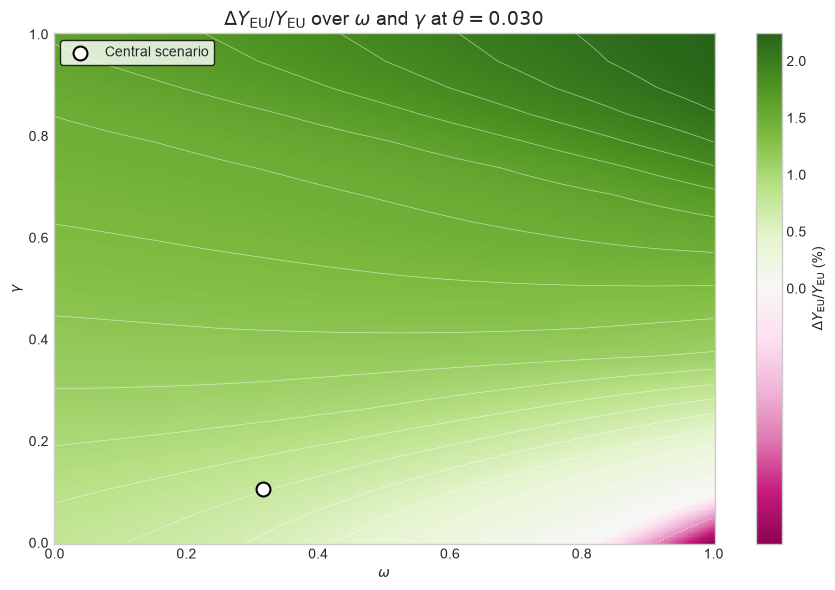

SUMMARY OF ΔY_EU/Y_EU ACROSS ALL SCENARIOS
Scenarios: 8000
Min ΔY_EU/Y_EU: -1.053161%
Max ΔY_EU/Y_EU: 3.937146%
Mean ΔY_EU/Y_EU: 1.692040%
Median ΔY_EU/Y_EU: 1.692394%
Std ΔY_EU/Y_EU: 0.908681%


In [78]:
# Add heatmap of ΔY_EU/Y_EU over gamma and omega at central scenario theta
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import TwoSlopeNorm

df_heat = grp_y_scenarios[np.isclose(grp_y_scenarios['theta'], CMU_THETA)].copy()

heat = (
    df_heat
    .pivot_table(index='gamma', columns='omega', values='dy_pct', aggfunc='mean')
    .sort_index()
    .sort_index(axis=1)
)

gamma_vals = heat.index.values
omega_vals = heat.columns.values
Z = heat.values

# Interpolate to a finer grid for smoother contour lines
gamma_fine = np.linspace(gamma_vals.min(), gamma_vals.max(), 300)
omega_fine = np.linspace(omega_vals.min(), omega_vals.max(), 300)
OMEGA_FINE, GAMMA_FINE = np.meshgrid(omega_fine, gamma_fine)

interp = RegularGridInterpolator(
    (gamma_vals, omega_vals), Z, method='linear', bounds_error=False, fill_value=np.nan
)
Z_fine = interp(np.column_stack([GAMMA_FINE.ravel(), OMEGA_FINE.ravel()])).reshape(GAMMA_FINE.shape)

zmin, zmax = np.nanmin(Z_fine), np.nanmax(Z_fine)
norm = TwoSlopeNorm(vmin=zmin, vcenter=0, vmax=zmax)

fig, ax = plt.subplots()
pcm = ax.pcolormesh(OMEGA_FINE, GAMMA_FINE, Z_fine, shading='auto', cmap='PiYG', norm=norm)

# Add smooth contour lines with more levels
levels = np.linspace(zmin, zmax, 21)
contours = ax.contour(OMEGA_FINE, GAMMA_FINE, Z_fine, levels=levels, colors='white', linewidths=0.5, alpha=0.6)
# ax.clabel(contours, inline=True, fontsize=7, fmt='%.2f')

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'$\Delta Y_{\mathrm{EU}} / Y_{\mathrm{EU}}$ (%)')

ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$\gamma$')
ax.set_title(rf'$\Delta Y_{{\mathrm{{EU}}}} / Y_{{\mathrm{{EU}}}}$ over $\omega$ and $\gamma$ at $\theta={_CMU_THETA:.3f}$')

# Add red dot for central scenario point, with a black wedge
ax.scatter(CMU_OMEGA, CMU_GAMMA, color='white', s=100, zorder=5, marker="o", label="Central scenario", edgecolor='black', linewidth=1.5)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='black')

plt.tight_layout()
# Save to imgs folder
plt.savefig("imgs/heatmap_dy_eu_pct_over_gamma_and_omega.png", dpi=150, bbox_inches="tight")
plt.show()


# Print the max, min, mean, std, median values of ΔY_EU/Y_EU across all scenarios
print("=" * 58)
print("SUMMARY OF ΔY_EU/Y_EU ACROSS ALL SCENARIOS")
print("=" * 58)
print(f"Scenarios: {len(grp_y_scenarios)}")
print(f"Min ΔY_EU/Y_EU: {grp_y_scenarios['dy_pct'].min():.6f}%")
print(f"Max ΔY_EU/Y_EU: {grp_y_scenarios['dy_pct'].max():.6f}%")
print(f"Mean ΔY_EU/Y_EU: {grp_y_scenarios['dy_pct'].mean():.6f}%")
print(f"Median ΔY_EU/Y_EU: {grp_y_scenarios['dy_pct'].median():.6f}%")
print(f"Std ΔY_EU/Y_EU: {grp_y_scenarios['dy_pct'].std():.6f}%")

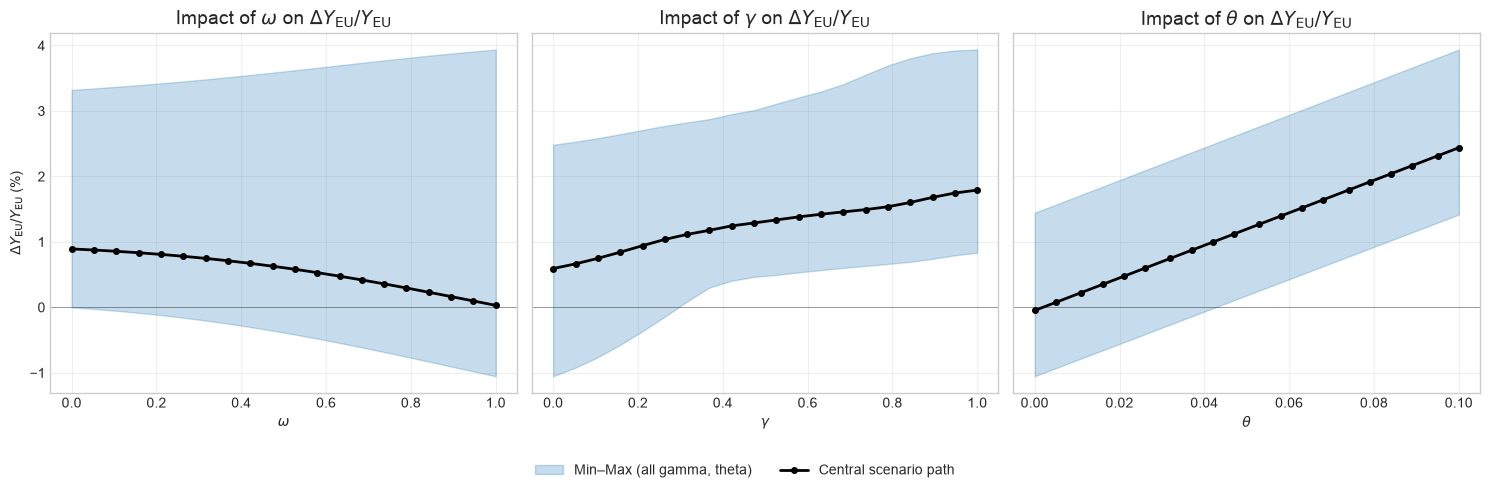

SUMMARY STATS PER PARAMETER (y = ΔY_EU/Y_EU (%))

Parameter omega ($\omega$):
  mean(y):    1.692040
  median(y):  1.692394
  std(y):     0.908681
  min(y):    -1.053161
  max(y):     3.937146
  corr(x,y): -0.010569

Parameter gamma ($\gamma$):
  mean(y):    1.692040
  median(y):  1.692394
  std(y):     0.908681
  min(y):    -1.053161
  max(y):     3.937146
  corr(x,y):  0.515200

Parameter theta ($\theta$):
  mean(y):    1.692040
  median(y):  1.692394
  std(y):     0.908681
  min(y):    -1.053161
  max(y):     3.937146
  corr(x,y):  0.831601


In [18]:
# Three 1D impact plots: uncertainty band + central scenario path
df_impact = grp_y_scenarios.copy()

configs = [
    {
        'param': 'omega',
        'others': ['gamma', 'theta'],
        'fixed': {'gamma': CMU_GAMMA, 'theta': CMU_THETA},
        'symbol': r'$\omega$',
    },
    {
        'param': 'gamma',
        'others': ['omega', 'theta'],
        'fixed': {'omega': CMU_OMEGA, 'theta': CMU_THETA},
        'symbol': r'$\gamma$',
    },
    {
        'param': 'theta',
        'others': ['omega', 'gamma'],
        'fixed': {'omega': CMU_OMEGA, 'gamma': CMU_GAMMA},
        'symbol': r'$\theta$',
    },
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, cfg in zip(axes, configs):
    p = cfg['param']
    o1, o2 = cfg['others']
    s = cfg['symbol']

    # Uncertainty band over all scenarios for each x-value of parameter p
    summary = (
        df_impact.groupby(p)['dy_pct']
        .agg(y_min='min', y_max='max', y_mean='mean')
        .reset_index()
        .sort_values(p)
    )

    # Central scenario path: vary p, keep other two at central scenario values
    mp = df_impact.copy()
    for k, v in cfg['fixed'].items():
        mp = mp[np.isclose(mp[k], v)]
    mp = (
        mp.groupby(p)['dy_pct']
        .mean()
        .reset_index()
        .sort_values(p)
    )

    ax.fill_between(
        summary[p], summary['y_min'], summary['y_max'],
        alpha=0.25, color='C0', label=rf'Min–Max (all {o1}, {o2})'
    )

    # Faint zero reference line
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)

    # Black line for central scenario path
    ax.plot(
        mp[p], mp['dy_pct'],
        color='black', linewidth=2, marker='o', markersize=4,
        label='Central scenario path'
    )

    ax.set_xlabel(s)
    ax.set_title(rf'Impact of {s} on $\Delta Y_{{\mathrm{{EU}}}}/Y_{{\mathrm{{EU}}}}$')
    ax.grid(alpha=0.3)

axes[0].set_ylabel(r'$\Delta Y_{\mathrm{EU}}/Y_{\mathrm{EU}}$ (%)')

# Centered legend below the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

plt.tight_layout()
# Save to imgs folder
plt.savefig("imgs/1d_impact_plots_with_uncertainty_bands.png", dpi=150, bbox_inches="tight")
plt.show()

# For each, print the mean, median, std, min, max, correlation with x

# For each, print the mean, median, std, min, max, correlation with x
print("=" * 80)
print("SUMMARY STATS PER PARAMETER (y = ΔY_EU/Y_EU (%))")
print("=" * 80)

for cfg in configs:
    p = cfg['param']
    s = cfg['symbol']

    d = df_impact[[p, 'dy_pct']].dropna().copy()
    corr = d[p].corr(d['dy_pct']) if d[p].nunique() > 1 else np.nan

    print(f"\nParameter {p} ({s}):")
    print(f"  mean(y):   {d['dy_pct'].mean(): .6f}")
    print(f"  median(y): {d['dy_pct'].median(): .6f}")
    print(f"  std(y):    {d['dy_pct'].std(): .6f}")
    print(f"  min(y):    {d['dy_pct'].min(): .6f}")
    print(f"  max(y):    {d['dy_pct'].max(): .6f}")
    print(f"  corr(x,y): {corr: .6f}")

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/995738640.py:33: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_omega_shock['delta_k_ratio'] = (df_omega_shock['k_fin_cmu'] - df_omega_shock['k_baseline_value']) / df_omega_s

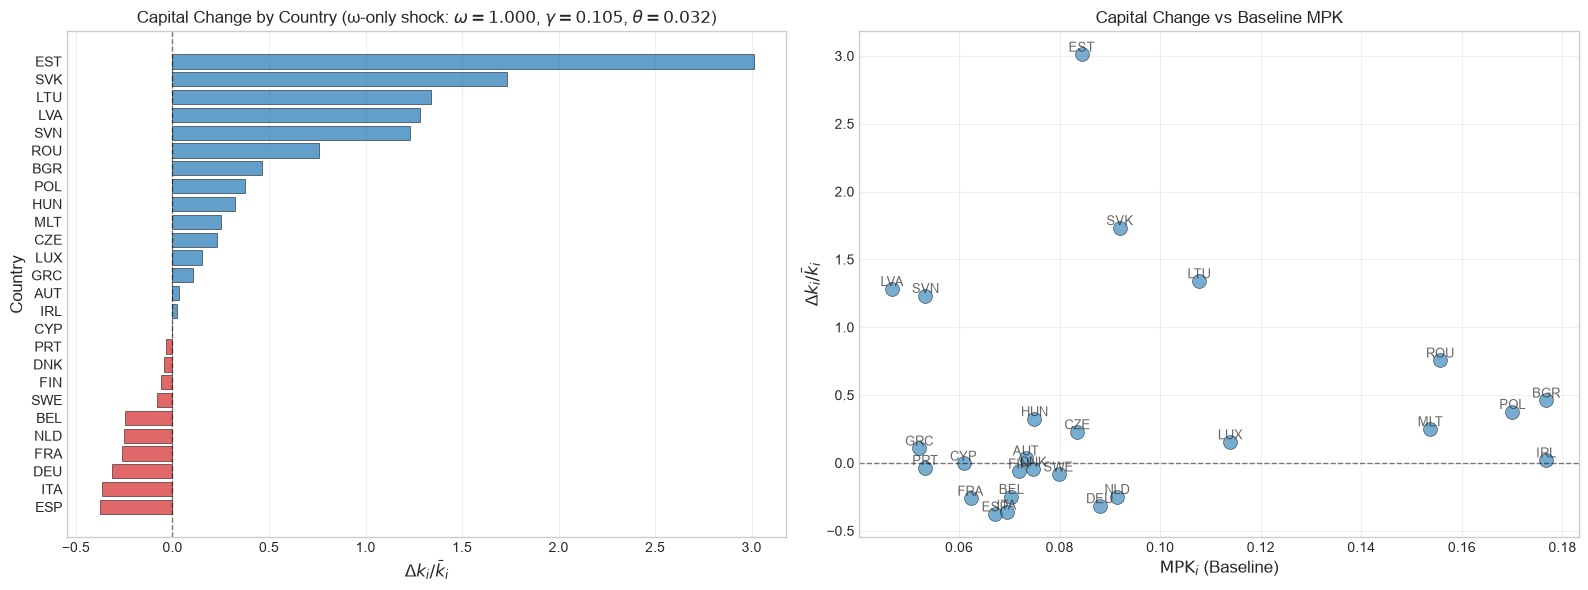

In [19]:
# Country-level capital changes under ω-only shock (omega varies, gamma=CMU_GAMMA, theta=CMU_THETA)
# and comparison with baseline returns (MPK)

# Get omega-only shock scenario: vary omega, keep gamma and theta at CMU values
df_omega_shock = df_output_country[
    (np.isclose(df_output_country['gamma'], CMU_GAMMA)) & 
    (np.isclose(df_output_country['theta'], CMU_THETA)) &
    (df_output_country['in_EU27'] == 1)
].copy()

# Get baseline (omega=gamma=theta=0)
df_baseline = df_output_country[
    (np.isclose(df_output_country['omega'], 0)) & 
    (np.isclose(df_output_country['gamma'], 0)) & 
    (np.isclose(df_output_country['theta'], 0)) &
    (df_output_country['in_EU27'] == 1)
].copy()

# Merge baseline capital to omega-shock data for comparison
df_omega_shock = df_omega_shock.merge(
    df_baseline[['country', 'k_fin_baseline']].rename(columns={'k_fin_baseline': 'k_baseline_value'}),
    on='country',
    how='left'
)

# If k_fin_baseline not available, use k_fin_baseline from same row or groupby
if df_omega_shock['k_baseline_value'].isna().all():
    df_baseline_k = df_baseline.groupby('country')['k_fin_baseline'].mean().reset_index()
    df_baseline_k.columns = ['country', 'k_baseline_value']
    df_omega_shock = df_omega_shock.merge(df_baseline_k, on='country', how='left')

# Compute relative capital change: Δk_i / k̄_i
df_omega_shock['delta_k_ratio'] = (df_omega_shock['k_fin_cmu'] - df_omega_shock['k_baseline_value']) / df_omega_shock['k_baseline_value']

# Get most extreme omega value for visualization
max_omega = df_omega_shock['omega'].max()
df_omega_max = df_omega_shock[np.isclose(df_omega_shock['omega'], max_omega)].copy()
df_omega_max = df_omega_max.sort_values('delta_k_ratio')

# Plot 1: Country-level capital changes under ω-only shock
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Bar plot of capital changes by country
countries = df_omega_max['country'].values
delta_k_values = df_omega_max['delta_k_ratio'].values
colors = ['#1f77b4' if x > 0 else '#d62728' for x in delta_k_values]

ax1.barh(countries, delta_k_values, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.set_xlabel(r'$\Delta k_i / \bar{k}_i$', fontsize=12)
ax1.set_ylabel('Country', fontsize=12)
ax1.set_title(rf'Capital Change by Country (ω-only shock: $\omega={max_omega:.3f}$, $\gamma={CMU_GAMMA:.3f}$, $\theta={CMU_THETA:.3f}$)', fontsize=12)
ax1.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.grid(axis='x', alpha=0.3)

# Right panel: Scatter plot comparing capital changes with baseline MPK
x_label = r'$\mathrm{MPK}_i$ (Baseline)'
x_data = df_omega_max['mpk_baseline'].values

ax2.scatter(x_data, delta_k_values, s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Add country labels to scatter plot
for i, country in enumerate(countries):
    ax2.annotate(country, (x_data[i], delta_k_values[i]), 
                fontsize=9, ha='center', va='bottom', alpha=0.7)

ax2.set_xlabel(x_label, fontsize=12)
ax2.set_ylabel(r'$\Delta k_i / \bar{k}_i$', fontsize=12)
ax2.set_title(r'Capital Change vs Baseline MPK', fontsize=12)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('imgs/country_capital_changes_omega_shock.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/1860291689.py:39: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  analysis_df['mpk_baseline'] = ALPHA * (analysis_df['y_base'] / analysis_df['k_base'])
/var/folders/nv/qmyxvnc573

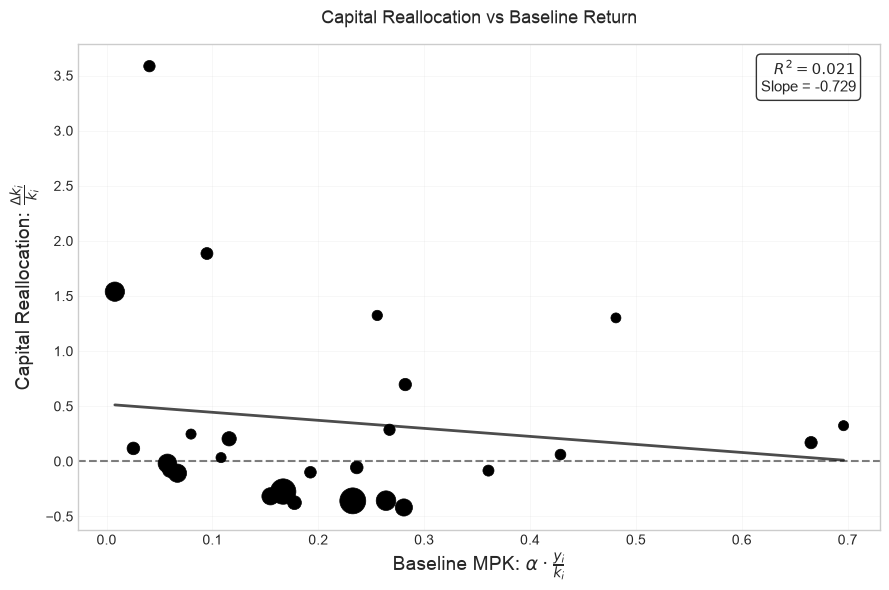

In [20]:
# Plot: Capital Reallocation vs Baseline Return
# Hard-wedge shock: ω=1, γ=0, θ=0

# Define scenario parameters
SHOCK_OMEGA = 1.0
SHOCK_GAMMA = 0.0
SHOCK_THETA = 0.0

# Capital share parameter (standard value in macroeconomics)
ALPHA = 0.3

# Get CMU scenario data (hard-wedge shock)
df_cmu = df_output_country[
    (np.isclose(df_output_country['omega'], SHOCK_OMEGA)) &
    (np.isclose(df_output_country['gamma'], SHOCK_GAMMA)) &
    (np.isclose(df_output_country['theta'], SHOCK_THETA)) &
    (df_output_country['in_EU27'] == 1)
].copy()

# Get baseline scenario data
df_base = df_output_country[
    (np.isclose(df_output_country['omega'], 0)) &
    (np.isclose(df_output_country['gamma'], 0)) &
    (np.isclose(df_output_country['theta'], 0)) &
    (df_output_country['in_EU27'] == 1)
].copy()

# Merge to get paired data
analysis_df = df_base[['country', 'y_baseline', 'k_fin_baseline']].copy()
analysis_df.columns = ['country', 'y_base', 'k_base']
analysis_df = analysis_df.merge(
    df_cmu[['country', 'y_cmu', 'k_fin_cmu']].copy().rename(columns={'y_cmu': 'y_cmu_shock', 'k_fin_cmu': 'k_cmu_shock'}),
    on='country',
    how='inner'
)

# Compute baseline MPK: MPK_i^baseline = α * (y_i / k_i)
# Using capital share α = 0.3 (standard macroeconomic value)
analysis_df['mpk_baseline'] = ALPHA * (analysis_df['y_base'] / analysis_df['k_base'])

# Compute capital change ratio: Δk_i / k_i
analysis_df['delta_k_ratio'] = (analysis_df['k_cmu_shock'] - analysis_df['k_base']) / analysis_df['k_base']

# Sort by country for display
analysis_df = analysis_df.sort_values('country').reset_index(drop=True)

# Create scatter plot - simplified styling
fig, ax = plt.subplots()

# Determine point sizes proportional to baseline capital stock
size_scale = analysis_df['k_base'] / analysis_df['k_base'].max() * 300 + 50

# Black scatter points with alpha=1, no colormapping or labels
ax.scatter(
    analysis_df['mpk_baseline'],
    analysis_df['delta_k_ratio'],
    s=size_scale,
    color='black',
    alpha=1.0,
    edgecolors='black',
    linewidth=0.5
)

# Add zero line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

# Fit regression line
z = np.polyfit(analysis_df['mpk_baseline'], analysis_df['delta_k_ratio'], 1)
p = np.poly1d(z)
x_line = np.linspace(analysis_df['mpk_baseline'].min(), analysis_df['mpk_baseline'].max(), 100)
ax.plot(x_line, p(x_line), 'black', linewidth=2, alpha=0.7)

# Compute statistics
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(analysis_df['mpk_baseline'], analysis_df['delta_k_ratio'])

# Improved axis labels
ax.set_xlabel(r'Baseline MPK: $\alpha \cdot \frac{y_i}{k_i}$', fontsize=14)
ax.set_ylabel(r'Capital Reallocation: $\frac{\Delta k_i}{k_i}$', fontsize=14)
ax.set_title('Capital Reallocation vs Baseline Return', fontsize=13, pad=15)

# Minimal grid
ax.grid(alpha=0.2, linestyle='-', linewidth=0.5)

# Add text box with R² and slope in upper right
textstr = f'$R^2 = {r_value**2:.3f}$\nSlope = {slope:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('imgs/capital_reallocation_vs_baseline_return.png', dpi=150, bbox_inches='tight')
plt.show()

## Wedge matrix

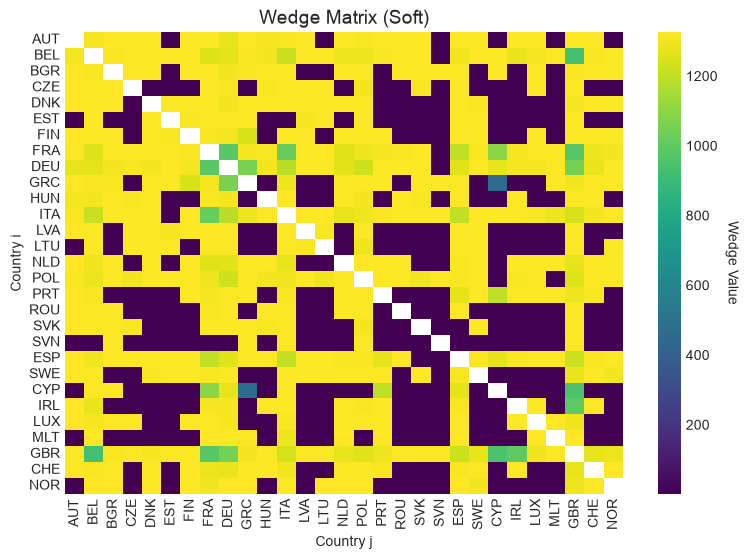

In [21]:
# Plot a wedge matrix across all pairs we have as a heatmap.
df_wedge_soft = pd.read_excel(xls, 'Wedge_SoftPolicy', index_col=0)

# Set diagonal to nan since there is nothing to show for this.
for i in range(df_wedge_soft.shape[0]):
    df_wedge_soft.iat[i, i] = np.nan

# Use sns heatmap
plt.figure()
sns.heatmap(df_wedge_soft, cmap=CMAP)
plt.title('Wedge Matrix (Soft)')
plt.xlabel('Country j')
plt.ylabel('Country i')
# Add colorbar description
cbar = plt.gcf().axes[-1].set_ylabel('Wedge Value', rotation=270, labelpad=15)
plt.show()

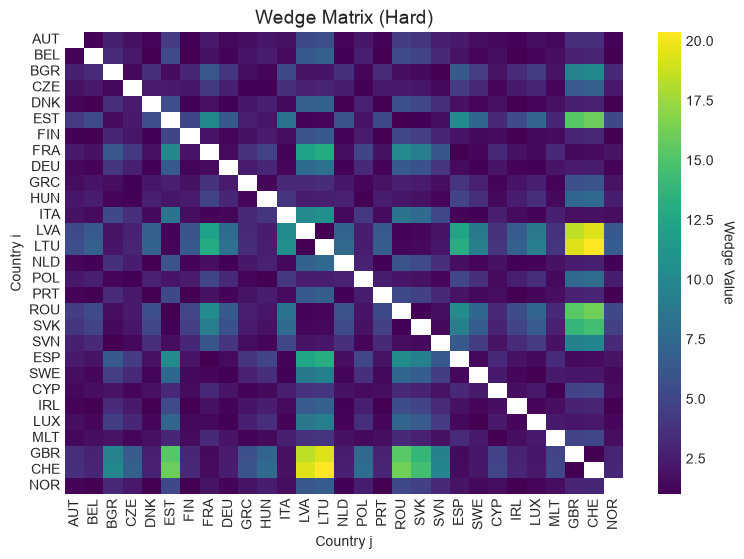

In [22]:
# Plot a wedge matrix across all pairs we have as a heatmap.

df_wedge_hard = pd.read_excel(xls, 'Wedge_Hard', index_col=0)

# Set diagonal to nan since there is nothing to show for this.
for i in range(df_wedge_hard.shape[0]):
    df_wedge_hard.iat[i, i] = np.nan

# Use sns heatmap
plt.figure()
sns.heatmap(df_wedge_hard, cmap=CMAP)
plt.title('Wedge Matrix (Hard)')
plt.xlabel('Country j')
plt.ylabel('Country i')
# Add colorbar description
cbar = plt.gcf().axes[-1].set_ylabel('Wedge Value', rotation=270, labelpad=15)
plt.show()

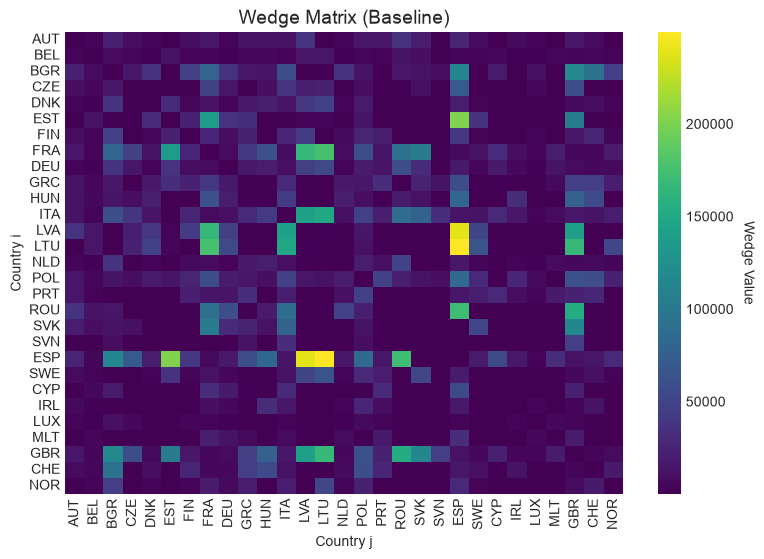

In [23]:
# Wedge baseline

df_wedge_baseline = pd.read_excel(xls, 'Wedge_Baseline', index_col=0)

# Use sns heatmap
plt.figure()
sns.heatmap(df_wedge_baseline, cmap=CMAP)
plt.title('Wedge Matrix (Baseline)')
plt.xlabel('Country j')
plt.ylabel('Country i')
# Add colorbar description
cbar = plt.gcf().axes[-1].set_ylabel('Wedge Value', rotation=270, labelpad=15)
# Save to imgs
plt.savefig('imgs/wedge_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## Gini index across EU across parameters

In [24]:
# We want to analyse how the wedges impact the wealth across the EU countries.

def gini(array):
    """Calculate the Gini coefficient of a numpy array."""
    # Based on bottom eq: http://www.statsdirect.com/help/generatedimages/equations/equation154.svg
    # All values are treated equally, arrays must be 1d:
    array = array.flatten()
    if np.amin(array) < 0:
        array -= np.amin(array)  # Values cannot be negative
    array += 0.0000001  # Values cannot be 0
    array = np.sort(array)  # Sort smallest to largest
    index = np.arange(1, array.shape[0] + 1)  # Index per array element
    n = array.shape[0]  # Number of array elements
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

In [25]:
# Run without extremes
exclude = ["IRL", "LUX", "CHE", "SVK", "CYP", "MLT"]
df_output_country_EU_extr = df_output_country_EU[~df_output_country_EU['country'].isin(exclude)]

### Output (Y)

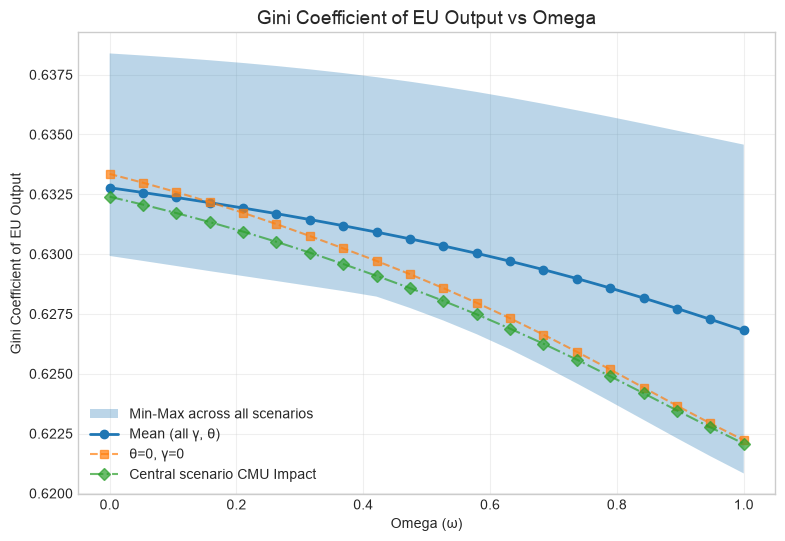

In [26]:
# x-axis: omega
# y-axis: gini index with uncertainty band (min/max across gamma, theta)

# Calculate gini statistics for output for each unique omega
gini_stats_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['y_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_omega.append({
        'omega': omega,
        'gini': gini_value
    })

gini_by_omega_df = pd.DataFrame(gini_stats_by_omega)
gini_by_omega_df = gini_by_omega_df.sort_values('omega')

# Compute min/max gini across all (gamma, theta) combinations for each omega
gini_minmax_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    
    gini_values = []
    for gamma in subset['gamma'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['gamma'] == gamma) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['y_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_omega.append({
            'omega': omega,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_omega).sort_values('omega')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['omega'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min-Max across all scenarios')
# Plot mean as line
plt.plot(gini_minmax_df['omega'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all γ, θ)', color='C0')
# Overlay the specific case (θ=0, γ=0)
plt.plot(gini_by_omega_df['omega'], gini_by_omega_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, γ=0', color='C1', alpha=0.7)
# Overlay line for central scenario case (θ=CMU_THETA, γ=CMU_GAMMA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['gamma'] == CMU_GAMMA)].copy()
most_probable = most_probable.groupby('omega')['y_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['omega'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Central scenario CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Omega (ω)')
plt.ylabel('Gini Coefficient of EU Output')
plt.title('Gini Coefficient of EU Output vs Omega')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

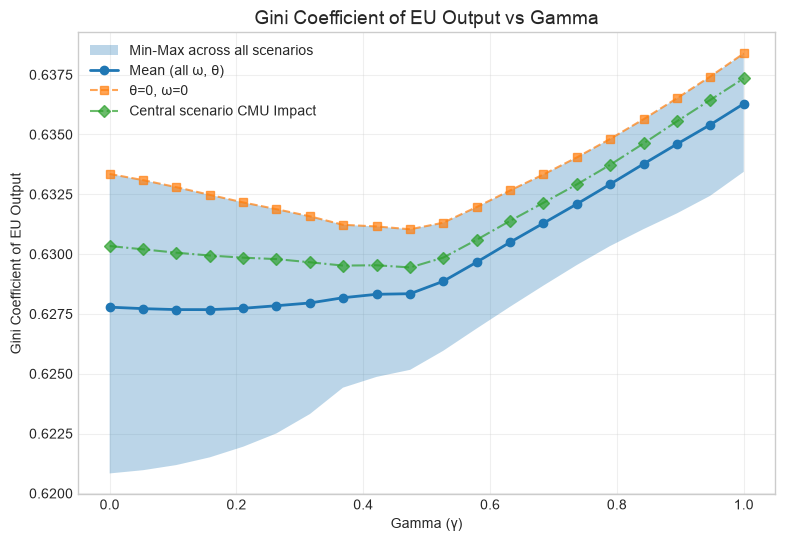

In [27]:
# x-axis: gamma
# y-axis: gini index with uncertainty band (min/max across omega, theta)

# Calculate gini statistics for output for each unique gamma
gini_stats_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    
    output_values = subset['y_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_gamma.append({
        'gamma': gamma,
        'gini': gini_value
    })

gini_by_gamma_df = pd.DataFrame(gini_stats_by_gamma)
gini_by_gamma_df = gini_by_gamma_df.sort_values('gamma')

# Compute min/max gini across all (omega, theta) combinations for each gamma
gini_minmax_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['y_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_gamma.append({
            'gamma': gamma,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_gamma).sort_values('gamma')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['gamma'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min-Max across all scenarios')
# Plot mean as line
plt.plot(gini_minmax_df['gamma'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, θ)', color='C0')
# Overlay the specific case (θ=0, ω=0)
plt.plot(gini_by_gamma_df['gamma'], gini_by_gamma_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, ω=0', color='C1', alpha=0.7)

# Overlay line for central scenario case (θ=CMU_THETA, omega=CMU_OMEGA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['omega'] == CMU_OMEGA)]
most_probable = most_probable.groupby('gamma')['y_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['gamma'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Central scenario CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Gamma (γ)')
plt.ylabel('Gini Coefficient of EU Output')
plt.title('Gini Coefficient of EU Output vs Gamma')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

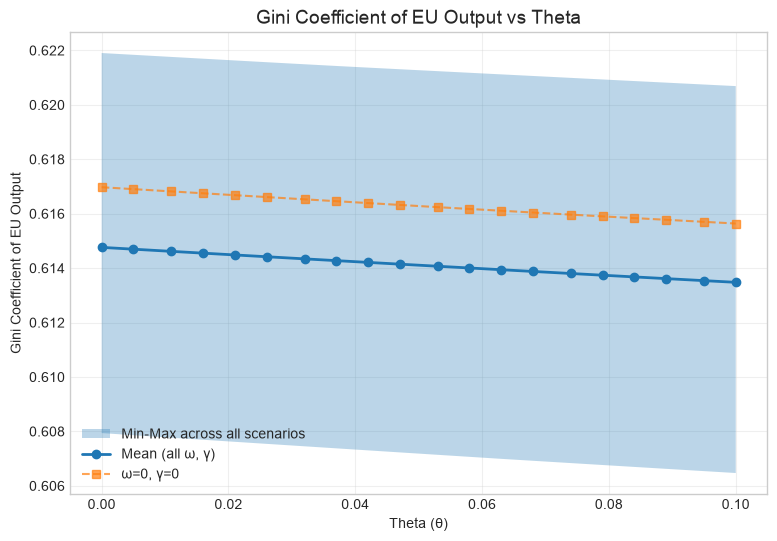

In [28]:
# x-axis: theta
# y-axis: gini index with uncertainty band (min/max across omega, gamma)

# Calculate gini statistics for output for each unique theta
gini_stats_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['y_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_theta.append({
        'theta': theta,
        'gini': gini_value
    })

gini_by_theta_df = pd.DataFrame(gini_stats_by_theta)
gini_by_theta_df = gini_by_theta_df.sort_values('theta')

# Compute min/max gini across all (omega, gamma) combinations for each theta
gini_minmax_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for gamma in subset['gamma'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['gamma'] == gamma)]
            if len(subsubset) > 0:
                output_values = subsubset['y_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_theta.append({
            'theta': theta,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_theta).sort_values('theta')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['theta'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min-Max across all scenarios')
# Plot mean as line
plt.plot(gini_minmax_df['theta'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, γ)', color='C0')
# Overlay the specific case (ω=0, γ=0)
plt.plot(gini_by_theta_df['theta'], gini_by_theta_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='ω=0, γ=0', color='C1', alpha=0.7)

plt.xlabel('Theta (θ)')
plt.ylabel('Gini Coefficient of EU Output')
plt.title('Gini Coefficient of EU Output vs Theta')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [29]:
# Build 3D dataframe: compute Gini for all (omega, gamma, theta) combinations

gini_3d_df = df_output_country.groupby(['omega', 'gamma', 'theta']).apply(
    lambda subset: gini(subset['y_cmu'].values),
    include_groups=False
).reset_index(name='gini')

print(f"3D Gini dataframe shape: {gini_3d_df.shape}")
print(f"Gini range: [{gini_3d_df['gini'].min():.4f}, {gini_3d_df['gini'].max():.4f}]")
print(gini_3d_df.head(10))

3D Gini dataframe shape: (8000, 4)
Gini range: [0.6065, 0.6219]
   omega  gamma  theta      gini
0    0.0    0.0  0.000  0.616972
1    0.0    0.0  0.005  0.616902
2    0.0    0.0  0.011  0.616819
3    0.0    0.0  0.016  0.616749
4    0.0    0.0  0.021  0.616680
5    0.0    0.0  0.026  0.616611
6    0.0    0.0  0.032  0.616528
7    0.0    0.0  0.037  0.616459
8    0.0    0.0  0.042  0.616390
9    0.0    0.0  0.047  0.616322


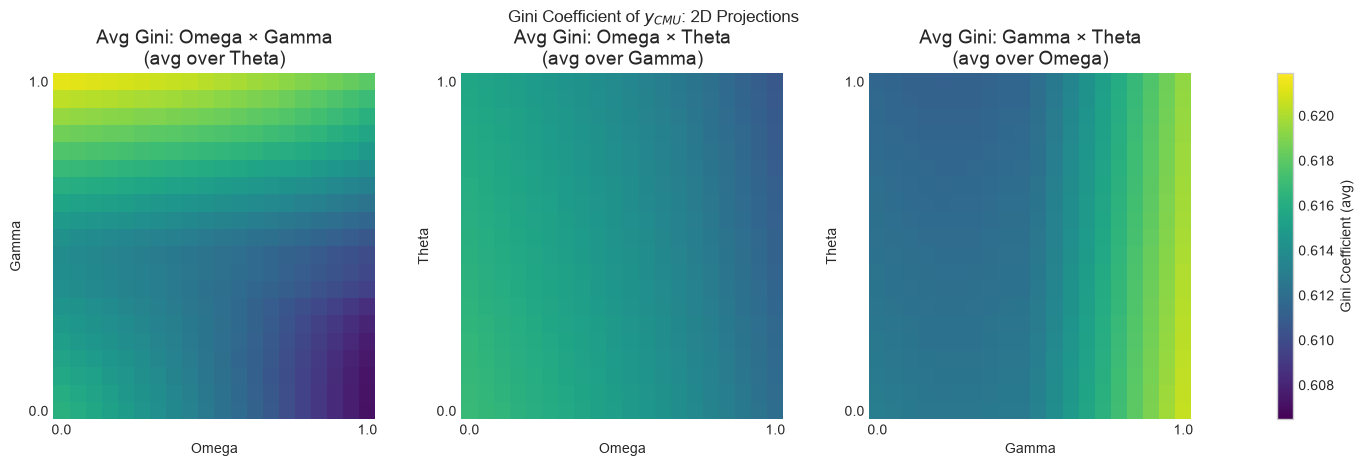

In [30]:
# 2D heatmap projections of Gini across parameter pairs
# Each heatmap averages the Gini over the third (omitted) parameter
# Contour isolines added on top

projection_configs = [
    ('omega', 'gamma', 'theta', 'Omega', 'Gamma',  'Avg Gini: Omega × Gamma\n(avg over Theta)'),
    ('omega', 'theta', 'gamma', 'Omega', 'Theta',  'Avg Gini: Omega × Theta\n(avg over Gamma)'),
    ('gamma', 'theta', 'omega', 'Gamma', 'Theta',  'Avg Gini: Gamma × Theta\n(avg over Omega)'),
]

gini_vmin = gini_3d_df['gini'].min()
gini_vmax = gini_3d_df['gini'].max()
gini_norm = plt.Normalize(gini_vmin, gini_vmax)

# Use gridspec: 3 equal heatmap cols + 1 narrow colorbar col
fig = plt.figure(figsize=(16, 4.5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax  = fig.add_subplot(gs[0, 3])

N_CONTOURS = 7

for ax, (x_col, y_col, avg_col, xlabel, ylabel, title) in zip(axes, projection_configs):
    pivot = gini_3d_df.groupby([y_col, x_col])['gini'].mean().unstack()
    sns.heatmap(
        pivot,
        ax=ax,
        cmap=CMAP,
        cbar=False,
        xticklabels=False,
        yticklabels=False,
        vmin=gini_vmin,
        vmax=gini_vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.invert_yaxis()

    # Show only min and max tick labels on each axis
    n_x = pivot.shape[1]
    n_y = pivot.shape[0]
    ax.set_xticks([0.5, n_x - 0.5])
    ax.set_xticklabels(['0.0', '1.0'])
    ax.set_yticks([0.5, n_y - 0.5])
    ax.set_yticklabels(['0.0', '1.0'])

    # Overlay contour isolines
    # heatmap cells are centred at 0.5, 1.5, ..., so use cell-centre coordinates
    x_centres = np.arange(0.5, n_x)
    y_centres = np.arange(0.5, n_y)
    Z = pivot.values  # rows = y_col, cols = x_col (already inverted by invert_yaxis)
    # cs = ax.contour(
    #     x_centres, y_centres, Z,
    #     levels=N_CONTOURS,
    #     colors='white',
    #     linewidths=0.5,
    #     alpha=0.75,
    # )
    # ax.clabel(cs, inline=True, fontsize=7, fmt='%.4f')

# Colorbar in its own dedicated axes
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=gini_norm)
sm.set_array([])
fig.colorbar(sm, cax=cax).set_label('Gini Coefficient (avg)')

plt.suptitle('Gini Coefficient of $y_{CMU}$: 2D Projections', y=1.02)
plt.show()

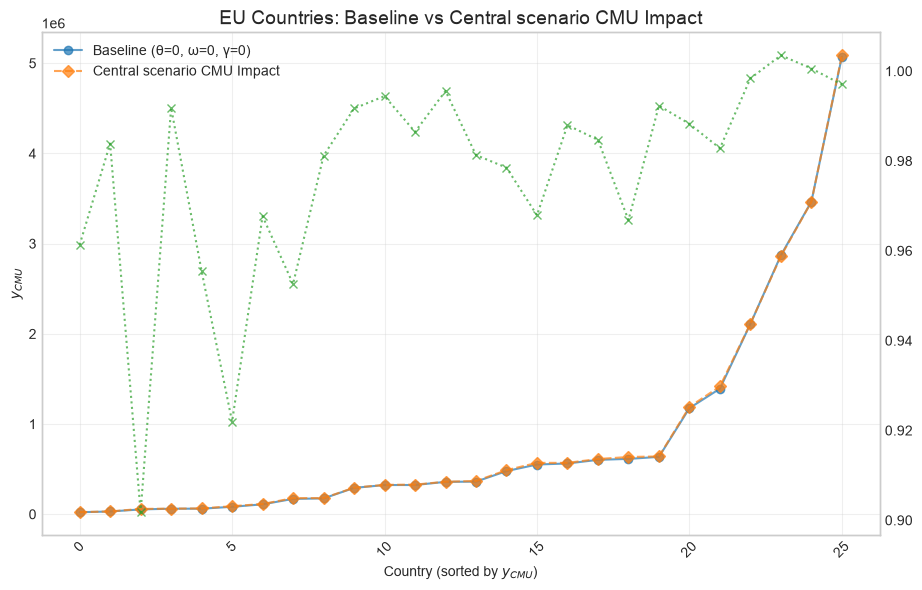

In [31]:
# Plot ln Y for best and worst. Sorting by 
# ln Y. So we line plot and see how the curve
# changes for baseline and central scenario case.

baseline = df_output_country_EU[(df_output_country_EU['theta'] == 0) & (df_output_country_EU['omega'] == 0) & (df_output_country_EU['gamma'] == 0)]
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['omega'] == CMU_OMEGA) & (df_output_country_EU['gamma'] == CMU_GAMMA)]

# Sort by y_cmu
baseline = baseline.sort_values('y_cmu')
most_probable = most_probable.sort_values('y_cmu')

# # Log
# baseline['y_cmu'] = np.log(baseline['y_cmu'])
# most_probable['y_cmu'] = np.log(most_probable['y_cmu'])

plt.figure()
# Baseline
plt.plot(baseline['y_cmu'].values, marker='o', linestyle='-', linewidth=1.5, label='Baseline (θ=0, ω=0, γ=0)', color='C0', alpha=0.7)
# Central scenario case
plt.plot(most_probable['y_cmu'].values, marker='D', linestyle='--', linewidth=1.5, label='Central scenario CMU Impact', color='C1', alpha=0.7)
plt.xlabel('Country (sorted by $y_{CMU}$)')
plt.ylabel('$y_{CMU}$')
plt.title('EU Countries: Baseline vs Central scenario CMU Impact')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()

# second axis plot difference
plt.twinx().plot(baseline['y_cmu'].values / most_probable['y_cmu'].values, marker='x', linestyle=':', linewidth=1.5, label='Difference (Baseline - Central scenario)', color='C2', alpha=0.7)
plt.savefig("imgs/eu_output_baseline_vs_probable_cmu.png", dpi=150, bbox_inches="tight")
plt.show()

### Foreign Investment (K)

In [32]:
# # x-axis: omega
# # y-axis: gini index with uncertainty band (min/max across gamma, theta)

# # Calculate gini statistics for output for each unique omega
# gini_stats_by_omega = []
# for omega in sorted(df_output_country_EU['omega'].unique()):
#     subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
#     subset = subset[subset['theta'] == 0]  # Focus on no TFP case
#     subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
#     
#     output_values = subset['k_cmu'].values
#     gini_value = gini(output_values)
#     gini_stats_by_omega.append({
#         'omega': omega,
#         'gini': gini_value
#     })

# gini_by_omega_df = pd.DataFrame(gini_stats_by_omega)
# gini_by_omega_df = gini_by_omega_df.sort_values('omega')

# # Compute min/max gini across all (gamma, theta) combinations for each omega
# gini_minmax_by_omega = []
# for omega in sorted(df_output_country_EU['omega'].unique()):
#     subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
#     
#     gini_values = []
#     for gamma in subset['gamma'].unique():
#         for theta in subset['theta'].unique():
#             subsubset = subset[(subset['gamma'] == gamma) & (subset['theta'] == theta)]
#             if len(subsubset) > 0:
#                 output_values = subsubset['k_cmu'].values
#                 gini_values.append(gini(output_values))
#     
#     if gini_values:
#         gini_minmax_by_omega.append({
#             'omega': omega,
#             'gini_min': np.min(gini_values),
#             'gini_max': np.max(gini_values),
#             'gini_mean': np.mean(gini_values)
#         })

# gini_minmax_df = pd.DataFrame(gini_minmax_by_omega).sort_values('omega')

# plt.figure()
# # Fill between min and max
# plt.fill_between(gini_minmax_df['omega'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
#                  alpha=0.3, label='Min-Max across all scenarios')
# # Plot mean as line
# plt.plot(gini_minmax_df['omega'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
#          label='Mean (all γ, θ)', color='C0')
# # Overlay the specific case (θ=0, γ=0)
# plt.plot(gini_by_omega_df['omega'], gini_by_omega_df['gini'], marker='s', linestyle='--', 
#          linewidth=1.5, label='θ=0, γ=0', color='C1', alpha=0.7)
# # Overlay line for central scenario case (θ=CMU_THETA, γ=CMU_GAMMA)
# most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['gamma'] == CMU_GAMMA)].copy()
# most_probable = most_probable.groupby('omega')['k_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
# plt.plot(most_probable['omega'], most_probable['gini'], marker='D', linestyle='-.', 
#          linewidth=1.5, label="Central scenario CMU Impact", color='C2', alpha=0.7)

# plt.xlabel('Omega (ω)')
# plt.ylabel('Gini Coefficient of EU Foreign Investment')
# plt.title('Gini Coefficient of EU Foreign Investment vs Omega')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.savefig("imgs/gini_foreign_investment_vs_omega.png", dpi=150, bbox_inches="tight")
# plt.show()

In [33]:
# # x-axis: gamma
# # y-axis: gini index with uncertainty band (min/max across omega, theta)

# # Calculate gini statistics for output for each unique gamma
# gini_stats_by_gamma = []
# for gamma in sorted(df_output_country_EU['gamma'].unique()):
#     subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
#     subset = subset[subset['theta'] == 0]  # Focus on no TFP case
#     subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
#     
#     output_values = subset['k_cmu'].values
#     gini_value = gini(output_values)
#     gini_stats_by_gamma.append({
#         'gamma': gamma,
#         'gini': gini_value
#     })

# gini_by_gamma_df = pd.DataFrame(gini_stats_by_gamma)
# gini_by_gamma_df = gini_by_gamma_df.sort_values('gamma')

# # Compute min/max gini across all (omega, theta) combinations for each gamma
# gini_minmax_by_gamma = []
# for gamma in sorted(df_output_country_EU['gamma'].unique()):
#     subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
#     
#     gini_values = []
#     for omega in subset['omega'].unique():
#         for theta in subset['theta'].unique():
#             subsubset = subset[(subset['omega'] == omega) & (subset['theta'] == theta)]
#             if len(subsubset) > 0:
#                 output_values = subsubset['k_cmu'].values
#                 gini_values.append(gini(output_values))
#     
#     if gini_values:
#         gini_minmax_by_gamma.append({
#             'gamma': gamma,
#             'gini_min': np.min(gini_values),
#             'gini_max': np.max(gini_values),
#             'gini_mean': np.mean(gini_values)
#         })

# gini_minmax_df = pd.DataFrame(gini_minmax_by_gamma).sort_values('gamma')

# plt.figure()
# # Fill between min and max
# plt.fill_between(gini_minmax_df['gamma'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
#                  alpha=0.3, label='Min-Max across all scenarios')
# # Plot mean as line
# plt.plot(gini_minmax_df['gamma'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
#          label='Mean (all ω, θ)', color='C0')
# # Overlay the specific case (θ=0, ω=0)
# plt.plot(gini_by_gamma_df['gamma'], gini_by_gamma_df['gini'], marker='s', linestyle='--', 
#          linewidth=1.5, label='θ=0, ω=0', color='C1', alpha=0.7)

# # Overlay line for central scenario case (θ=CMU_THETA, omega=CMU_OMEGA)
# most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['omega'] == CMU_OMEGA)]
# most_probable = most_probable.groupby('gamma')['k_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
# plt.plot(most_probable['gamma'], most_probable['gini'], marker='D', linestyle='-.', 
#          linewidth=1.5, label="Central scenario CMU Impact", color='C2', alpha=0.7)

# plt.xlabel('Gamma (γ)')
# plt.ylabel('Gini Coefficient of EU Foreign Investment')
# plt.title('Gini Coefficient of EU Foreign Investment vs Gamma')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.savefig("imgs/gini_foreign_investment_vs_gamma.png", dpi=150, bbox_inches="tight")
# plt.show()

In [34]:
# # x-axis: theta
# # y-axis: gini index with uncertainty band (min/max across omega, gamma)

# # Calculate gini statistics for output for each unique theta
# gini_stats_by_theta = []
# for theta in sorted(df_output_country['theta'].unique()):
#     subset = df_output_country[df_output_country['theta'] == theta]
#     subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
#     subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
#     
#     output_values = subset['k_cmu'].values
#     gini_value = gini(output_values)
#     gini_stats_by_theta.append({
#         'theta': theta,
#         'gini': gini_value
#     })

# gini_by_theta_df = pd.DataFrame(gini_stats_by_theta)
# gini_by_theta_df = gini_by_theta_df.sort_values('theta')

# # Compute min/max gini across all (omega, gamma) combinations for each theta
# gini_minmax_by_theta = []
# for theta in sorted(df_output_country['theta'].unique()):
#     subset = df_output_country[df_output_country['theta'] == theta]
#     
#     gini_values = []
#     for omega in subset['omega'].unique():
#         for gamma in subset['gamma'].unique():
#             subsubset = subset[(subset['omega'] == omega) & (subset['gamma'] == gamma)]
#             if len(subsubset) > 0:
#                 output_values = subsubset['k_cmu'].values
#                 gini_values.append(gini(output_values))
#     
#     if gini_values:
#         gini_minmax_by_theta.append({
#             'theta': theta,
#             'gini_min': np.min(gini_values),
#             'gini_max': np.max(gini_values),
#             'gini_mean': np.mean(gini_values)
#         })

# gini_minmax_df = pd.DataFrame(gini_minmax_by_theta).sort_values('theta')

# plt.figure()
# # Fill between min and max
# plt.fill_between(gini_minmax_df['theta'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
#                  alpha=0.3, label='Min-Max across all scenarios')
# # Plot mean as line
# plt.plot(gini_minmax_df['theta'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
#          label='Mean (all ω, γ)', color='C0')
# # Overlay the specific case (ω=0, γ=0)
# plt.plot(gini_by_theta_df['theta'], gini_by_theta_df['gini'], marker='s', linestyle='--', 
#          linewidth=1.5, label='ω=0, γ=0', color='C1', alpha=0.7)

# plt.xlabel('Theta (θ)')
# plt.ylabel('Gini Coefficient of EU Foreign Investment')
# plt.title('Gini Coefficient of EU Foreign Investment vs Theta')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.savefig("imgs/gini_foreign_investment_vs_theta.png", dpi=150, bbox_inches="tight")
# plt.show()

In [35]:
# # Build 3D dataframe: compute Gini for all (omega, gamma, theta) combinations

# gini_3d_df = df_output_country.groupby(['omega', 'gamma', 'theta']).apply(
#     lambda subset: gini(subset['k_cmu'].values),
#     include_groups=False
# ).reset_index(name='gini')

# print(f"3D Gini dataframe shape: {gini_3d_df.shape}")
# print(f"Gini range: [{gini_3d_df['gini'].min():.4f}, {gini_3d_df['gini'].max():.4f}]")
# print(gini_3d_df.head(10))

In [36]:
# # 2D heatmap projections of Gini across parameter pairs
# # Each heatmap averages the Gini over the third (omitted) parameter
# # Contour isolines added on top

# projection_configs = [
#     ('omega', 'gamma', 'theta', 'Omega', 'Gamma',  'Avg Gini: Omega × Gamma\n(avg over Theta)'),
#     ('omega', 'theta', 'gamma', 'Omega', 'Theta',  'Avg Gini: Omega × Theta\n(avg over Gamma)'),
#     ('gamma', 'theta', 'omega', 'Gamma', 'Theta',  'Avg Gini: Gamma × Theta\n(avg over Omega)'),
# ]

# gini_vmin = gini_3d_df['gini'].min()
# gini_vmax = gini_3d_df['gini'].max()
# gini_norm = plt.Normalize(gini_vmin, gini_vmax)

# # Use gridspec: 3 equal heatmap cols + 1 narrow colorbar col
# fig = plt.figure(figsize=(16, 4.5))
# gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
# axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
# cax  = fig.add_subplot(gs[0, 3])

# N_CONTOURS = 7

# for ax, (x_col, y_col, avg_col, xlabel, ylabel, title) in zip(axes, projection_configs):
#     pivot = gini_3d_df.groupby([y_col, x_col])['gini'].mean().unstack()
#     sns.heatmap(
#         pivot,
#         ax=ax,
#         cmap=CMAP,
#         cbar=False,
#         xticklabels=False,
#         yticklabels=False,
#         vmin=gini_vmin,
#         vmax=gini_vmax,
#     )
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel(ylabel)
#     ax.set_title(title)
#     ax.invert_yaxis()

#     # Show only min and max tick labels on each axis
#     n_x = pivot.shape[1]
#     n_y = pivot.shape[0]
#     ax.set_xticks([0.5, n_x - 0.5])
#     ax.set_xticklabels(['0.0', '1.0'])
#     ax.set_yticks([0.5, n_y - 0.5])
#     ax.set_yticklabels(['0.0', '1.0'])

#     # Overlay contour isolines
#     # heatmap cells are centred at 0.5, 1.5, ..., so use cell-centre coordinates
#     x_centres = np.arange(0.5, n_x)
#     y_centres = np.arange(0.5, n_y)
#     Z = pivot.values  # rows = y_col, cols = x_col (already inverted by invert_yaxis)
#     # cs = ax.contour(
#     #     x_centres, y_centres, Z,
#     #     levels=N_CONTOURS,
#     #     colors='white',
#     #     linewidths=0.5,
#     #     alpha=0.75,
#     # )
#     # ax.clabel(cs, inline=True, fontsize=7, fmt='%.4f')

# # Colorbar in its own dedicated axes
# sm = plt.cm.ScalarMappable(cmap=CMAP, norm=gini_norm)
# sm.set_array([])
# fig.colorbar(sm, cax=cax).set_label('Gini Coefficient (avg)')

# plt.suptitle('Gini Coefficient of $k_{CMU}$: 2D Projections', y=1.02)
# plt.savefig("imgs/gini_2d_heatmap_projections.png", dpi=150, bbox_inches="tight")
# plt.show()

## Financials per Country

In [37]:
# Plot histogram of stock market cap across the countries
df_final = pd.read_csv("Data/Clean/Final-v4.csv")
df_final

,iso3_i,iso3_j,year,total_pip_million_usd_i,total_pip_million_usd_j,a_ij,r_i,r_j,Y_i,k_i,...,legal_origin,language_proximity,lang_share,lang_official,legal_origin_i,legal_origin_j,fta_wto,d_ling,eu_i,eu_j
0,ABW,ABW,2000,NaN,NaN,NaN,NaN,NaN,3982.696289,11437.366211,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,ABW,ABW,2001,NaN,NaN,NaN,NaN,NaN,3918.971436,11965.093750,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
2,ABW,ABW,2002,NaN,NaN,NaN,NaN,NaN,3923.781006,12594.469727,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
3,ABW,ABW,2003,NaN,NaN,NaN,NaN,NaN,3944.353027,13318.708008,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,ABW,ABW,2004,NaN,NaN,NaN,NaN,NaN,4243.611328,14101.028320,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535269,ZWE,ZWE,2021,NaN,NaN,NaN,NaN,NaN,44440.199219,110979.773438,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0
1535270,ZWE,ZWE,2022,NaN,NaN,NaN,NaN,NaN,47147.550781,114134.882812,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0
1535271,ZWE,ZWE,2023,NaN,NaN,NaN,NaN,NaN,49685.757812,118669.257812,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0
1535272,ZWE,ZWE,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0


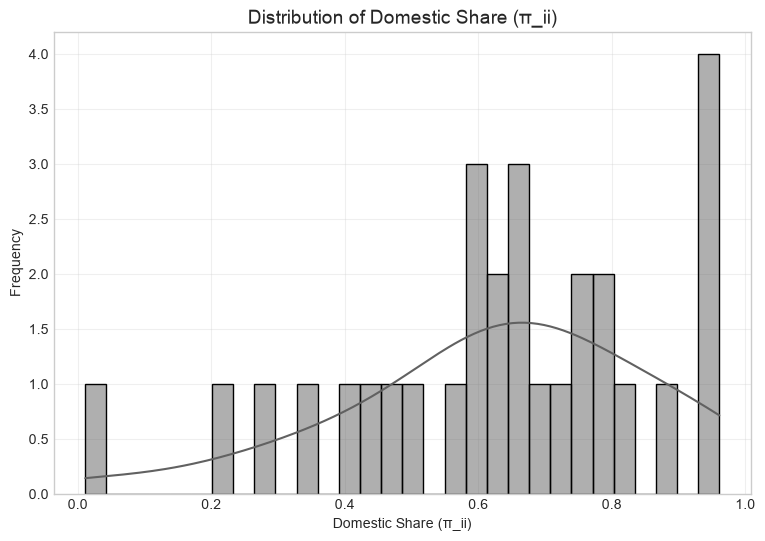

Countries with Domestic Share (π_ii) below 0.2:
['MLT']


In [38]:
# Plot home bias across countries
# Home bias = pi_ii (share of domestic holdings in total portfolio)

df_portfolio = pd.read_excel(xls, 'Portfolio_Data', index_col=0)
df_portfolio_arr = df_portfolio.values
# Flatten with numpy, get full matrix flat
portfolio_flat = df_portfolio_arr.flatten()
# Attach index (iso3_i, iso3_j) and make into series
portfolio_series = pd.Series(portfolio_flat, index=pd.MultiIndex.from_product([df_portfolio.index, df_portfolio.columns], names=['iso3_i', 'iso3_j']))

# Plot distribution of home bias (pi_ii)
home_bias = portfolio_series[portfolio_series.index.get_level_values('iso3_i') == portfolio_series.index.get_level_values('iso3_j')]
home_bias = home_bias.dropna()

plt.figure()
sns.histplot(home_bias, bins=30, kde=True, color="#616161")
plt.title('Distribution of Domestic Share (π_ii)')
plt.xlabel('Domestic Share (π_ii)')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("imgs/domestic_share_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the countries with below 0.2 in Domestic Share
low_home_bias = home_bias[home_bias < 0.2]
print("Countries with Domestic Share (π_ii) below 0.2:")
print(low_home_bias.index.get_level_values('iso3_i').unique().tolist())

## Map

In [39]:
world = gpd.read_file("Data/europe.geo.json")
world.head()

,featurecla,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,tlc,admin,...,fclass_id,fclass_pl,fclass_gr,fclass_it,fclass_nl,fclass_se,fclass_bd,fclass_ua,filename,geometry
0,Admin-0 country,5,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,USA.geojson,"MULTIPOLYGON (((-132.74688 56.52568, -132.7576..."
1,Admin-0 country,1,2,France,FR1,1,2,Country,1,France,...,None,None,None,None,None,None,None,None,FRA.geojson,"MULTIPOLYGON (((9.48037 42.80542, 9.4542 42.65..."
2,Admin-0 country,1,3,Ukraine,UKR,0,2,Sovereign country,1,Ukraine,...,None,None,None,None,None,None,None,None,UKR.geojson,"MULTIPOLYGON (((38.21436 47.09146, 38.17832 47..."
3,Admin-0 country,1,4,Belarus,BLR,0,2,Sovereign country,1,Belarus,...,None,None,None,None,None,None,None,None,BLR.geojson,"POLYGON ((31.76338 52.10107, 31.57373 52.10811..."
4,Admin-0 country,3,5,Lithuania,LTU,0,2,Sovereign country,1,Lithuania,...,None,None,None,None,None,None,None,None,LTU.geojson,"MULTIPOLYGON (((20.95781 55.27891, 20.8998 55...."


In [40]:
# Use pycountry to get the iso3 codes
import pycountry

# PyCountry mapping
records = []
for c in pycountry.countries:
    records.append({
        "country_name": c.name,
        "iso3":         c.alpha_3,
        "iso2":         c.alpha_2,
        "iso_numeric":  c.numeric,
    })
    
# Add Unites States of America as USA
records.append({
    "country_name": "United States of America",
    "iso3": "USA",
    "iso2": "US"
})

df_iso = pd.DataFrame(records)
# # Limit it to COUNTRIES
# df_iso_countries = df_iso[df_iso['iso3'].isin(COUNTRIES)]
# Set if in EU27
df_iso['in_EU27'] = df_iso['iso3'].apply(lambda x: 1 if x in EU27 else 0)
print(df_iso.shape)

(250, 5)


/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/4097102002.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_iso['in_EU27'] = df_iso['iso3'].apply(lambda x: 1 if x in EU27 else 0)


In [41]:
# Join world and df_iso_countries on admin and country name
world = world.merge(df_iso, left_on='sovereignt', right_on='country_name', how='left')
# Remove Iceland, it ruins the visualisation
world = world[world["sovereignt"] != "Iceland"]
world_eu = world[world['in_EU27'] == 1]
world_noneu = world[(world['in_EU27'] == 0) & (world['sovereignt'] != 'United States of America')]
world["in_EU27"] = world["in_EU27"].fillna(0).astype(int)
world.head(2)

,featurecla,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,tlc,admin,...,fclass_se,fclass_bd,fclass_ua,filename,geometry,country_name,iso3,iso2,iso_numeric,in_EU27
0,Admin-0 country,5,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,USA.geojson,"MULTIPOLYGON (((-132.74688 56.52568, -132.7576...",United States of America,USA,US,NaN,0
1,Admin-0 country,1,2,France,FR1,1,2,Country,1,France,...,None,None,None,FRA.geojson,"MULTIPOLYGON (((9.48037 42.80542, 9.4542 42.65...",France,FRA,FR,250,1


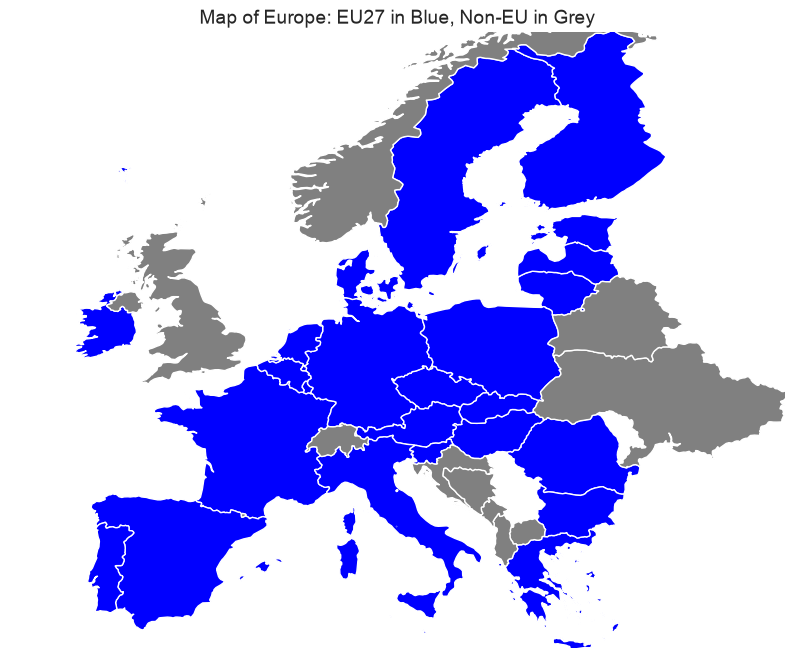

In [42]:
fig, ax = plt.subplots(figsize=(10, 8))

world_eu.plot(ax=ax, color='blue', edgecolor='white', autolim=False)
world_noneu.plot(ax=ax, color='gray', edgecolor='white', autolim=False)

ax.set_title('Map of Europe: EU27 in Blue, Non-EU in Grey')
ax.set_aspect('auto')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)

plt.savefig("imgs/map_europe_eu27.png", dpi=150, bbox_inches="tight")
plt.show()

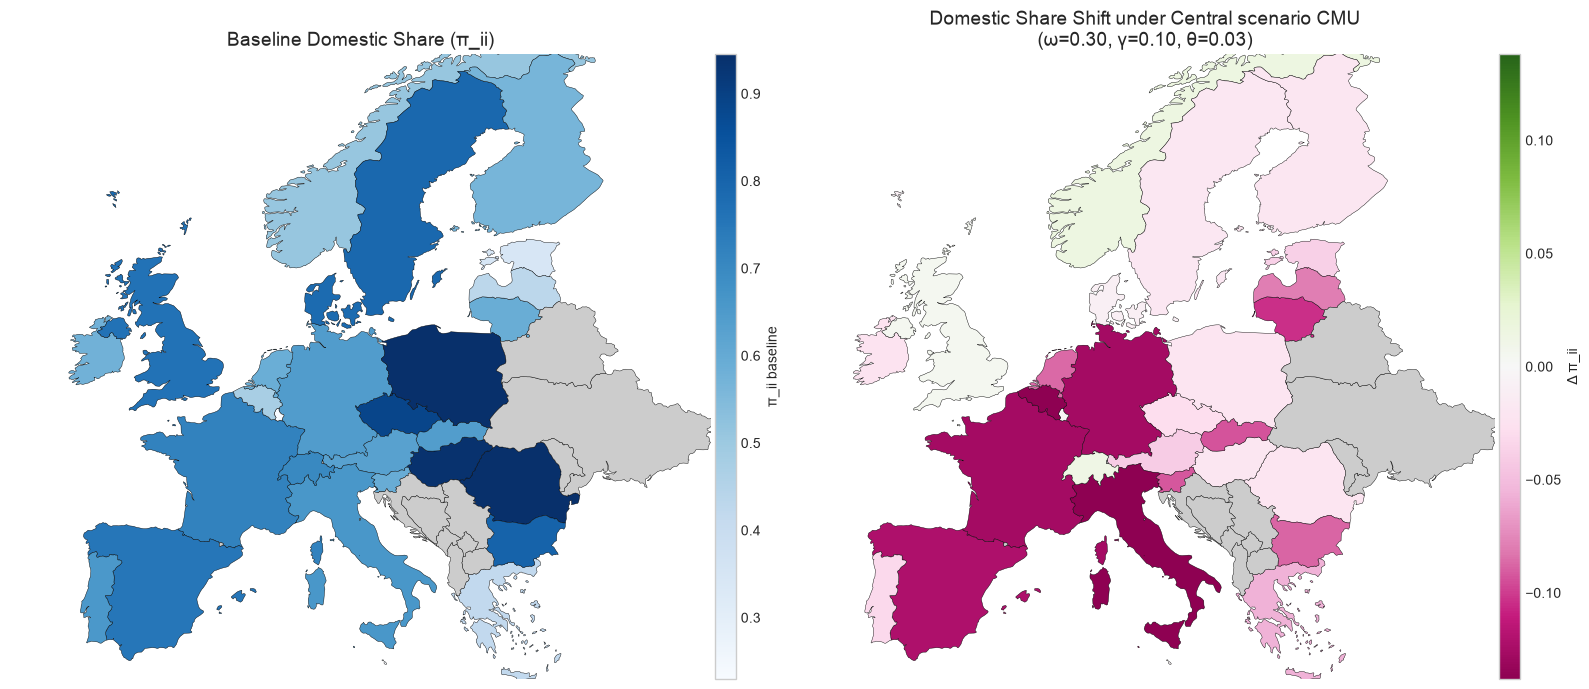

Top 5 increases in Domestic Share (π_ii):
      country  pi_home_baseline  pi_home_cmu  d_pi_home  d_pi_home_pct
73160     NOR          0.510262     0.526396   0.016134       3.161848
73141     CHE          0.699866     0.712616   0.012751       1.821850
73150     GBR          0.761550     0.765892   0.004342       0.570175
73142     CYP          0.024010     0.020953  -0.003058     -12.734275
73156     LUX          0.054826     0.050461  -0.004364      -7.960570

Top 5 decreases in Domestic Share (π_ii):
      country  pi_home_baseline  pi_home_cmu  d_pi_home  d_pi_home_pct
73154     ITA          0.661059     0.503491  -0.157568     -23.835667
73139     BEL          0.478066     0.323115  -0.154951     -32.412076
73144     DEU          0.646111     0.519230  -0.126881     -19.637670
73149     FRA          0.720840     0.593964  -0.126876     -17.601156
73146     ESP          0.750812     0.629171  -0.121641     -16.201212


In [43]:
# Map: Domestic Share — baseline level (left) and shift under central scenario CMU (right)
from mpl_toolkits.axes_grid1 import make_axes_locatable

df_hb = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA)
][['country', 'pi_home_baseline', 'pi_home_cmu', 'd_pi_home', 'd_pi_home_pct']].copy()

world_hb = world.merge(df_hb, left_on='iso3', right_on='country', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_WATER   = '#dbf4ff'
_MISSING = dict(color='#cccccc', edgecolor='black', label='No data')

# ── Left: baseline Domestic Share level ──────────────────────────
ax = axes[0]
ax.set_facecolor(_WATER)

vmin_b = world_hb['pi_home_baseline'].quantile(0.05)
vmax_b = world_hb['pi_home_baseline'].quantile(0.95)
norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_hb.plot(ax=ax, column='pi_home_baseline', cmap='Blues',
                 edgecolor='black', linewidth=0.3, legend=False,
                 norm=norm_b, missing_kwds=_MISSING)

sm_b = plt.cm.ScalarMappable(cmap='Blues', norm=norm_b)
sm_b.set_array(world_hb['pi_home_baseline'].dropna().values)
div_b = make_axes_locatable(ax)
cax_b = div_b.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_b, cax=cax_b).set_label('π_ii baseline')

ax.set_title('Baseline Domestic Share (π_ii)')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

# ── Right: shift Δπ_ii under central scenario CMU ──────────────
ax = axes[1]
ax.set_facecolor(_WATER)

vlim = world_hb['d_pi_home'].abs().quantile(0.95)
norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_hb.plot(ax=ax, column='d_pi_home', cmap='PiYG',
                 edgecolor='black', linewidth=0.3, legend=False,
                 norm=norm_d, missing_kwds=_MISSING)

sm_d = plt.cm.ScalarMappable(cmap='PiYG', norm=norm_d)
sm_d.set_array(world_hb['d_pi_home'].dropna().values)
div_d = make_axes_locatable(ax)
cax_d = div_d.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_d, cax=cax_d).set_label('Δ π_ii')

ax.set_title(f'Domestic Share Shift under Central scenario CMU\n(ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

plt.tight_layout()
plt.savefig("imgs/map_domestic_share.png", dpi=150, bbox_inches="tight")
plt.show()

# print top 5 and bottom 5 for biggest changes
top_changes = df_hb.sort_values('d_pi_home', ascending=False).head(5)
bottom_changes = df_hb.sort_values('d_pi_home').head(5)

print("Top 5 increases in Domestic Share (π_ii):")
print(top_changes[['country', 'pi_home_baseline', 'pi_home_cmu', 'd_pi_home', 'd_pi_home_pct']])

print("\nTop 5 decreases in Domestic Share (π_ii):")
print(bottom_changes[['country', 'pi_home_baseline', 'pi_home_cmu', 'd_pi_home', 'd_pi_home_pct']])

In [44]:
# # Map: Flow of money change — baseline inflows (left) and shift under central scenario CMU (right)
# from mpl_toolkits.axes_grid1 import make_axes_locatable

# df_flows = pd.read_excel(xls, 'Portfolio_Flows')

# # Total capital inflows received by each destination country j
# # baseline scenario = omega=0, gamma=0
# df_baseline_flows = (
#     df_flows[df_flows['scenario'] == 'baseline']
#     .groupby('iso3_j')['k_flow'].sum()
#     .reset_index()
#     .rename(columns={'iso3_j': 'country', 'k_flow': 'k_inflow_baseline'})
# )

# df_prob_flows = (
#     df_flows[df_flows['scenario'] == 'most_probable']
#     .groupby('iso3_j')['k_flow'].sum()
#     .reset_index()
#     .rename(columns={'iso3_j': 'country', 'k_flow': 'k_inflow_cmu'})
# )

# df_flow_change = df_baseline_flows.merge(df_prob_flows, on='country')
# df_flow_change['dk_inflow']     = df_flow_change['k_inflow_cmu'] - df_flow_change['k_inflow_baseline']
# df_flow_change['dk_inflow_pct'] = df_flow_change['dk_inflow'] / df_flow_change['k_inflow_baseline'] * 100

# world_flow = world.merge(df_flow_change, left_on='iso3', right_on='country', how='left')

# fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# _WATER   = '#a8d8ea'
# _MISSING = dict(color='#cccccc', edgecolor='black', label='No data')

# # ── Left: baseline total inflows ─────────────────────────────
# ax = axes[0]
# ax.set_facecolor(_WATER)

# vmin_b = world_flow['k_inflow_baseline'].quantile(0.05)
# vmax_b = world_flow['k_inflow_baseline'].quantile(0.95)
# norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

# world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
# world_flow.plot(ax=ax, column='k_inflow_baseline', cmap='Blues',
#                    edgecolor='black', linewidth=0.3, legend=False,
#                    norm=norm_b, missing_kwds=_MISSING)

# sm_b = plt.cm.ScalarMappable(cmap='Blues', norm=norm_b)
# sm_b.set_array(world_flow['k_inflow_baseline'].dropna().values)
# div_b = make_axes_locatable(ax)
# cax_b = div_b.append_axes("right", size="3%", pad=0.04)
# fig.colorbar(sm_b, cax=cax_b).set_label('Capital inflows (USD mn)')

# ax.set_title('Baseline Capital Inflows by Country')
# ax.set_axis_off()
# ax.set_xlim(-15, 40)
# ax.set_ylim(35, 70)
# ax.set_aspect('auto')

# # ── Right: shift in inflows under central scenario CMU ──────────
# ax = axes[1]
# ax.set_facecolor(_WATER)

# vlim = world_flow['dk_inflow_pct'].abs().quantile(0.95)
# norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

# world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
# world_flow.plot(ax=ax, column='dk_inflow_pct', cmap='PiYG',
#                    edgecolor='black', linewidth=0.3, legend=False,
#                    norm=norm_d, missing_kwds=_MISSING)

# sm_d = plt.cm.ScalarMappable(cmap='PiYG', norm=norm_d)
# sm_d.set_array(world_flow['dk_inflow_pct'].dropna().values)
# div_d = make_axes_locatable(ax)
# cax_d = div_d.append_axes("right", size="3%", pad=0.04)
# fig.colorbar(sm_d, cax=cax_d).set_label('Δ Inflows (%)')

# ax.set_title(f'Change in Capital Inflows under Central scenario CMU\n(ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
# ax.set_axis_off()
# ax.set_xlim(-15, 40)
# ax.set_ylim(35, 70)
# ax.set_aspect('auto')

# plt.tight_layout()
# plt.savefig("imgs/map_capital_inflows.png", dpi=150, bbox_inches="tight")
# plt.show()

# # Print the top 5 and bottom 5 by change in inflow, show baseline, % change, and diff in levels
# top_5 = df_flow_change.nlargest(5, 'dk_inflow_pct')
# bottom_5 = df_flow_change.nsmallest(5, 'dk_inflow_pct')

# print("Top 5 countries by change in inflow (%):")
# print(top_5[['country', 'k_inflow_baseline', 'dk_inflow_pct', 'dk_inflow']])

# print("\nBottom 5 countries by change in inflow (%):")
# print(bottom_5[['country', 'k_inflow_baseline', 'dk_inflow_pct', 'dk_inflow']])

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/2071060438.py:38: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_flow_change["dk_inflow"] = df_flow_change["k_inflow_cmu"] - df_flow_change["k_inflow_baseline"]
/var/folders/

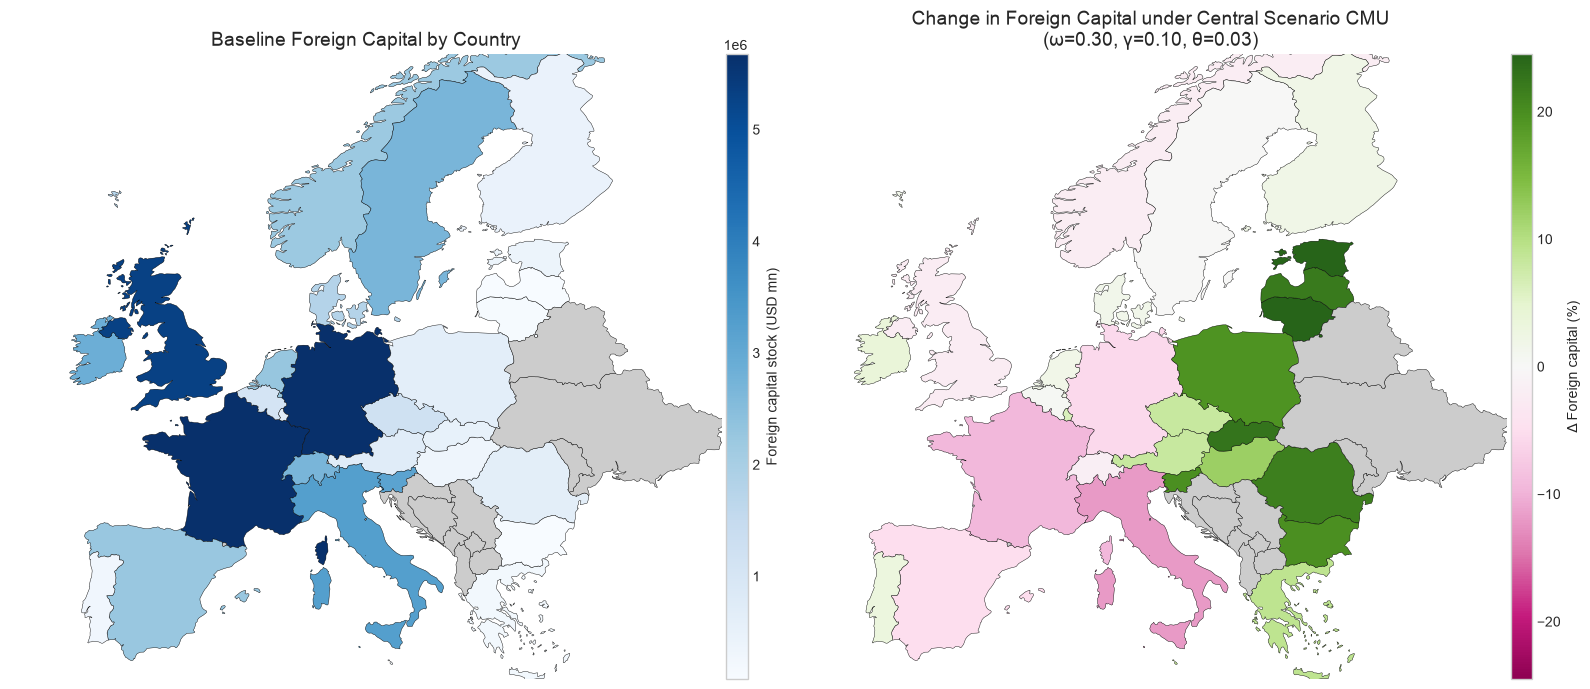

Top 5 countries by change in foreign capital (%):
   country  k_inflow_baseline  dk_inflow_pct      dk_inflow
9      EST      392546.889835      38.507152  151158.627659
17     LTU      128385.070287      27.147974   34853.945143
26     SVK      537075.272145      22.752129  122196.060468
19     LVA       37996.181052      22.181186    8428.003538
25     ROU      652192.788750      21.487914  140142.623553

Bottom 5 countries by change in foreign capital (%):
   country  k_inflow_baseline  dk_inflow_pct      dk_inflow
16     ITA       3.262827e+06     -12.001671 -391593.758806
11     FRA       6.232579e+06      -9.458616 -589515.712955
6      DEU       6.543954e+06      -5.705088 -373338.335384
8      ESP       2.254570e+06      -5.156366 -116253.889439
12     GBR       5.304342e+06      -2.356478 -124995.648667


In [45]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import numpy as np

# NOTE:
# This uses country-level foreign capital stock from Output_Country:
# - baseline: k_fin_baseline
# - CMU:      k_fin_cmu at (CMU_OMEGA, CMU_GAMMA, CMU_THETA)

# Baseline rows
base_mask = (
    np.isclose(df_output_country["omega"], 0.0) &
    np.isclose(df_output_country["gamma"], 0.0) &
    np.isclose(df_output_country["theta"], 0.0)
)

df_baseline_cap = (
    df_output_country.loc[base_mask, ["country", "k_fin_baseline"]]
    .drop_duplicates(subset=["country"])
    .rename(columns={"k_fin_baseline": "k_inflow_baseline"})
)

# Central scenario rows
cmu_mask = (
    np.isclose(df_output_country["omega"], CMU_OMEGA) &
    np.isclose(df_output_country["gamma"], CMU_GAMMA) &
    np.isclose(df_output_country["theta"], CMU_THETA)
)

df_cmu_cap = (
    df_output_country.loc[cmu_mask, ["country", "k_fin_cmu"]]
    .drop_duplicates(subset=["country"])
    .rename(columns={"k_fin_cmu": "k_inflow_cmu"})
)

# Merge and compute changes
df_flow_change = df_baseline_cap.merge(df_cmu_cap, on="country", how="inner")
df_flow_change["dk_inflow"] = df_flow_change["k_inflow_cmu"] - df_flow_change["k_inflow_baseline"]
df_flow_change["dk_inflow_pct"] = np.where(
    np.isclose(df_flow_change["k_inflow_baseline"], 0.0),
    np.nan,
    df_flow_change["dk_inflow"] / df_flow_change["k_inflow_baseline"] * 100
)

world_flow = world.merge(df_flow_change, left_on="iso3", right_on="country", how="left")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_WATER   = "#a8d8ea"
_MISSING = dict(color="#cccccc", edgecolor="black", label="No data")

# ── Left: baseline foreign capital (stock) ─────────────────────
ax = axes[0]
ax.set_facecolor(_WATER)

vmin_b = world_flow["k_inflow_baseline"].quantile(0.05)
vmax_b = world_flow["k_inflow_baseline"].quantile(0.95)
norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

world_noneu.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.3)
world_flow.plot(
    ax=ax, column="k_inflow_baseline", cmap="Blues",
    edgecolor="black", linewidth=0.3, legend=False,
    norm=norm_b, missing_kwds=_MISSING
)

sm_b = plt.cm.ScalarMappable(cmap="Blues", norm=norm_b)
sm_b.set_array(world_flow["k_inflow_baseline"].dropna().values)
div_b = make_axes_locatable(ax)
cax_b = div_b.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_b, cax=cax_b).set_label("Foreign capital stock (USD mn)")

ax.set_title("Baseline Foreign Capital by Country")
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect("auto")

# ── Right: % change under central scenario ─────────────────────
ax = axes[1]
ax.set_facecolor(_WATER)

vlim = world_flow["dk_inflow_pct"].abs().quantile(0.95)
norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

world_noneu.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.3)
world_flow.plot(
    ax=ax, column="dk_inflow_pct", cmap="PiYG",
    edgecolor="black", linewidth=0.3, legend=False,
    norm=norm_d, missing_kwds=_MISSING
)

sm_d = plt.cm.ScalarMappable(cmap="PiYG", norm=norm_d)
sm_d.set_array(world_flow["dk_inflow_pct"].dropna().values)
div_d = make_axes_locatable(ax)
cax_d = div_d.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_d, cax=cax_d).set_label("Δ Foreign capital (%)")

ax.set_title(
    f"Change in Foreign Capital under Central Scenario CMU\n"
    f"(ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})"
)
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect("auto")

plt.tight_layout()
plt.savefig("imgs/map_capital_inflows.png", dpi=150, bbox_inches="tight")
plt.show()

# Top/bottom movers
top_5 = df_flow_change.nlargest(5, "dk_inflow_pct")
bottom_5 = df_flow_change.nsmallest(5, "dk_inflow_pct")

print("Top 5 countries by change in foreign capital (%):")
print(top_5[["country", "k_inflow_baseline", "dk_inflow_pct", "dk_inflow"]])

print("\nBottom 5 countries by change in foreign capital (%):")
print(bottom_5[["country", "k_inflow_baseline", "dk_inflow_pct", "dk_inflow"]])

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/2518903057.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_gdp_mp['dy_pct'] = (df_gdp_mp['y_cmu'] - df_gdp_mp['y_baseline']) / df_gdp_mp['y_baseline'] * 100


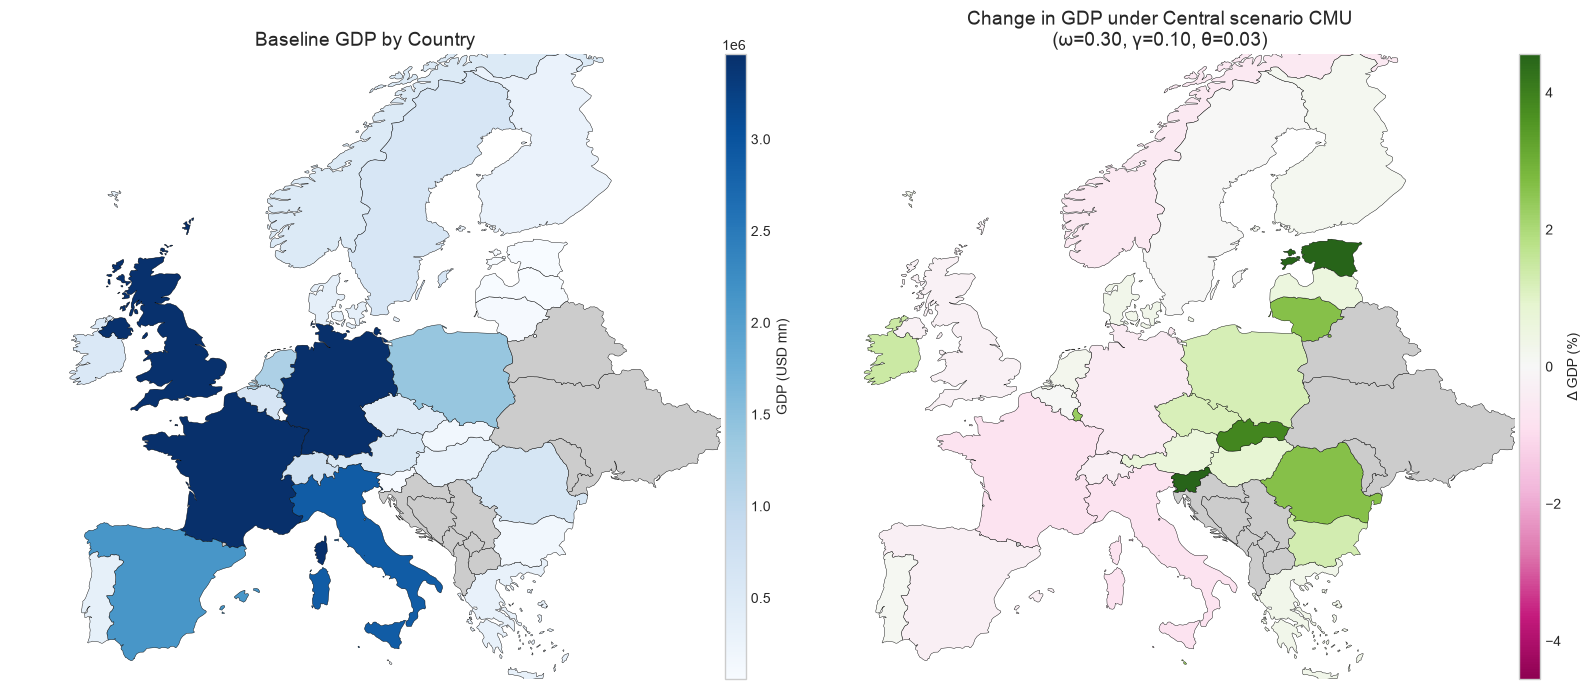

Top 5 countries by change in GDP (%):
   country    dy_pct      dy_level
7      EST  8.791007   4748.338062
33     SVN  5.591938   4712.205366
21     SVK  3.868251   6647.676749
4      LTU  2.625216   2892.409924
19     ROU  2.603195  16095.484015

Bottom 5 countries by change in GDP (%):
   country    dy_pct      dy_level
27     ITA -0.810101 -23363.058686
1      FRA -0.808323 -28224.188415
9      NOR -0.537859  -2815.776160
6      DEU -0.486227 -24858.328597
17     ESP -0.314038  -6658.789841


In [46]:
# MAP GDP
# Map: GDP baseline level (left) and % change under central scenario CMU (right)
from mpl_toolkits.axes_grid1 import make_axes_locatable

df_gdp_mp = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA)
] .copy()

df_gdp_mp['dy_pct'] = (df_gdp_mp['y_cmu'] - df_gdp_mp['y_baseline']) / df_gdp_mp['y_baseline'] * 100

world_gdp = world.merge(
    df_gdp_mp[['country', 'y_baseline', 'dy_pct']],
    left_on='iso3', right_on='country', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_WATER   = '#a8d8ea'
_MISSING = dict(color='#cccccc', edgecolor='black', label='No data')

# ── Left: baseline GDP ───────────────────────────────────────
ax = axes[0]
ax.set_facecolor(_WATER)

vmin_b = world_gdp['y_baseline'].quantile(0.05)
vmax_b = world_gdp['y_baseline'].quantile(0.95)
norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_gdp.plot(ax=ax, column='y_baseline', cmap='Blues',
                  edgecolor='black', linewidth=0.3, legend=False,
                  norm=norm_b, missing_kwds=_MISSING)

sm_b = plt.cm.ScalarMappable(cmap='Blues', norm=norm_b)
sm_b.set_array(world_gdp['y_baseline'].dropna().values)
div_b = make_axes_locatable(ax)
cax_b = div_b.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_b, cax=cax_b).set_label('GDP (USD mn)')

ax.set_title('Baseline GDP by Country')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

# ── Right: % change in GDP under central scenario CMU ───────────
ax = axes[1]
ax.set_facecolor(_WATER)

vlim = world_gdp['dy_pct'].abs().quantile(0.95)
norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_gdp.plot(ax=ax, column='dy_pct', cmap='PiYG',
                  edgecolor='black', linewidth=0.3, legend=False,
                  norm=norm_d, missing_kwds=_MISSING)

sm_d = plt.cm.ScalarMappable(cmap='PiYG', norm=norm_d)
sm_d.set_array(world_gdp['dy_pct'].dropna().values)
div_d = make_axes_locatable(ax)
cax_d = div_d.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_d, cax=cax_d).set_label('Δ GDP (%)')

ax.set_title(f'Change in GDP under Central scenario CMU\n(ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

plt.tight_layout()
plt.savefig("imgs/map_gdp.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the top 5 and bottom 5 by change in inflow, show %change, diff in levels
# Compute GDP change in levels (USD mn) from % change
world_gdp['dy_level'] = world_gdp['y_baseline'] * (world_gdp['dy_pct'] / 100.0)

# Print the top 5 and bottom 5 by GDP % change, showing % and level difference
top_5_gdp = world_gdp.nlargest(5, 'dy_pct')
bottom_5_gdp = world_gdp.nsmallest(5, 'dy_pct')

print("Top 5 countries by change in GDP (%):")
print(top_5_gdp[['country', 'dy_pct', 'dy_level']])

print("\nBottom 5 countries by change in GDP (%):")
print(bottom_5_gdp[['country', 'dy_pct', 'dy_level']])

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/274731269.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  capital_change['dk_cap_pct'] = (capital_change['k_fin_cmu'] - capital_change['k_fin_baseline']) / np.abs(capital_

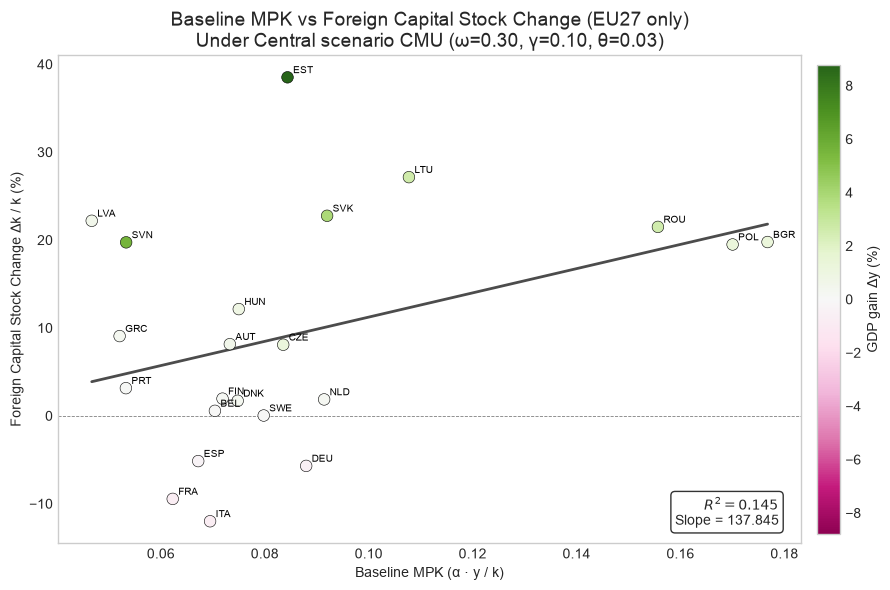

In [47]:
# Scatter: baseline MPK vs CAPITAL STOCK CHANGE under central scenario CMU
# Uses Output_Country sheet to measure total foreign capital stock (not flows)
# Each point = one country; colour = GDP gain (dy_pct)
# EU27 only, excluding financial centres

# Get baseline and CMU capital stock by country
df_base_cap = df_output_country[
    (df_output_country['theta'] == 0) &
    (df_output_country['omega'] == 0) &
    (df_output_country['gamma'] == 0)
][['country', 'k_fin_baseline']].drop_duplicates(subset=['country'])

df_cmu_cap = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA)
][['country', 'k_fin_cmu']].drop_duplicates(subset=['country'])

# Compute capital stock change
capital_change = df_base_cap.merge(df_cmu_cap, on='country', how='outer').fillna(0)
capital_change['dk_cap_pct'] = (capital_change['k_fin_cmu'] - capital_change['k_fin_baseline']) / np.abs(capital_change['k_fin_baseline']) * 100

# Merge with country-level output data (central scenario CMU) — EU27 only
df_scatter = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA) &
    (df_output_country['in_EU27'] == 1) &
    (~df_output_country['country'].isin(FINANCIAL_CENTRES))
][['country', 'mpk_baseline', 'dy_pct', 'is_financial_ctr']].drop_duplicates(subset=['country']).copy()

df_scatter = df_scatter.merge(capital_change[['country', 'dk_cap_pct']], on='country', how='left')

# Separate financial centres from regular countries
df_main = df_scatter[df_scatter['is_financial_ctr'] == 0]
df_fc   = df_scatter[df_scatter['is_financial_ctr'] == 1]

fig, ax = plt.subplots(figsize=(9, 6))

# Colour by dy_pct — symmetric around 0
max_abs = max(np.abs(df_main['dy_pct'].min()), np.abs(df_main['dy_pct'].max()))
vmin_c = -max_abs
vmax_c = max_abs
norm_c = mcolors.TwoSlopeNorm(vmin=vmin_c, vcenter=0, vmax=vmax_c)
cmap_c = plt.cm.PiYG

sc = ax.scatter(
    df_main['mpk_baseline'],
    df_main['dk_cap_pct'],
    c=df_main['dy_pct'],
    cmap=cmap_c,
    norm=norm_c,
    s=70,
    zorder=3,
    edgecolors='black',
    linewidths=0.4,
)

# Plot financial centres as hollow grey markers
ax.scatter(
    df_fc['mpk_baseline'],
    df_fc['dk_cap_pct'],
    c='none',
    edgecolors='grey',
    linewidths=0.8,
    s=60,
    zorder=3,
    label='Financial centre',
    marker='D',
)

# Country labels
for _, row in df_scatter.iterrows():
    ax.annotate(
        row['country'],
        xy=(row['mpk_baseline'], row['dk_cap_pct']),
        xytext=(4, 3),
        textcoords='offset points',
        fontsize=7,
        color='grey' if row['is_financial_ctr'] else 'black',
    )

# Horizontal zero line
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)

# Fit regression to main data only
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df_main['mpk_baseline'], df_main['dk_cap_pct'])
x_line = np.linspace(df_main['mpk_baseline'].min(), df_main['mpk_baseline'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'black', linewidth=2, alpha=0.7)

cb = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('GDP gain Δy (%)')

ax.set_xlabel('Baseline MPK (α · y / k)')
ax.set_ylabel('Foreign Capital Stock Change Δk / k (%)')
ax.set_title(f'Baseline MPK vs Foreign Capital Stock Change (EU27 only)\nUnder Central scenario CMU (ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')

textstr = f'$R^2 = {r_value**2:.3f}$\nSlope = {slope:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(0.97, 0.03, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig("imgs/scatter_mpk_vs_foreign_inflow_change.png", dpi=150, bbox_inches="tight")
plt.show()

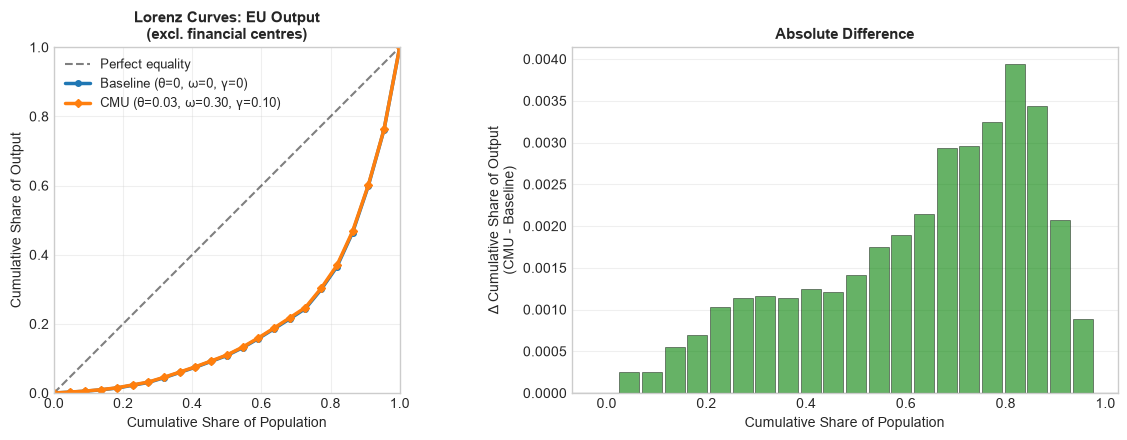

Gini Coefficient (Baseline): 0.6014
Gini Coefficient (Central scenario CMU): 0.5982
Change in Gini: -0.0032

Max absolute difference in cumulative output: 0.0039 at pop share 0.82
Mean absolute difference: 0.0016


In [48]:
# Lorenz curve: baseline vs central scenario CMU scenario
# Financial centres excluded from distributional analysis
FINANCIAL_CENTRES = ["IRL", "LUX", "CYP", "MLT"]
df_eu_excl = df_output_country_EU[~df_output_country_EU['country'].isin(FINANCIAL_CENTRES)].copy()

def lorenz_curve(values):
    """Return (cum_population_share, cum_wealth_share) for a Lorenz curve."""
    values = np.sort(np.array(values, dtype=float))
    cum_wealth = np.cumsum(values) / values.sum()
    cum_pop = np.arange(1, len(values) + 1) / len(values)
    # Prepend origin
    return np.concatenate([[0], cum_pop]), np.concatenate([[0], cum_wealth])

baseline      = df_eu_excl[(df_eu_excl['theta'] == 0) & (df_eu_excl['omega'] == 0) & (df_eu_excl['gamma'] == 0)]
most_probable = df_eu_excl[(df_eu_excl['theta'] == CMU_THETA) & (df_eu_excl['omega'] == CMU_OMEGA) & (df_eu_excl['gamma'] == CMU_GAMMA)]

cum_pop_base, cum_wealth_base = lorenz_curve(baseline['y_cmu'].values)
cum_pop_cmu,  cum_wealth_cmu  = lorenz_curve(most_probable['y_cmu'].values)

# Interpolate to same grid for difference calculation
cum_wealth_cmu_interp = np.interp(cum_pop_base, cum_pop_cmu, cum_wealth_cmu)
wealth_diff = cum_wealth_cmu_interp - cum_wealth_base

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ─── Left: Standard Lorenz Curves ───────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect equality', alpha=0.5)
ax.plot(cum_pop_base, cum_wealth_base, marker='o', linewidth=2.5, 
        label='Baseline (θ=0, ω=0, γ=0)', color='C0', markersize=4)
ax.plot(cum_pop_cmu, cum_wealth_cmu, marker='D', linewidth=2.5, 
        label=f'CMU (θ={_CMU_THETA:.2f}, ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f})', 
        color='C1', markersize=4)
ax.set_xlabel('Cumulative Share of Population', fontsize=10)
ax.set_ylabel('Cumulative Share of Output', fontsize=10)
ax.set_title('Lorenz Curves: EU Output\n(excl. financial centres)', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
ax.set_aspect('equal')

# ─── Right: Absolute Difference ────────────────────────────
ax = axes[1]
colors = ['red' if d < 0 else 'green' for d in wealth_diff]
ax.bar(cum_pop_base[:-1], wealth_diff[:-1], width=0.04, color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cumulative Share of Population', fontsize=10)
ax.set_ylabel('Δ Cumulative Share of Output\n(CMU - Baseline)', fontsize=10)
ax.set_title('Absolute Difference', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("imgs/lorenz_curves_output.png", dpi=150, bbox_inches="tight")
plt.show()

# Print statistics
gini_baseline = gini(baseline['y_cmu'].values)
gini_cmu = gini(most_probable['y_cmu'].values)
max_diff = np.max(np.abs(wealth_diff))
max_diff_idx = np.argmax(np.abs(wealth_diff))

print(f"Gini Coefficient (Baseline): {gini_baseline:.4f}")
print(f"Gini Coefficient (Central scenario CMU): {gini_cmu:.4f}")
print(f"Change in Gini: {gini_cmu - gini_baseline:+.4f}")
print(f"\nMax absolute difference in cumulative output: {max_diff:.4f} at pop share {cum_pop_base[max_diff_idx]:.2f}")
print(f"Mean absolute difference: {np.mean(np.abs(wealth_diff[:-1])):.4f}")


/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/1903084701.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  country_data_copy['dy_pct'] = (country_data_copy['y_cmu'] - country_data_copy['y_baseline']) / country_data_copy

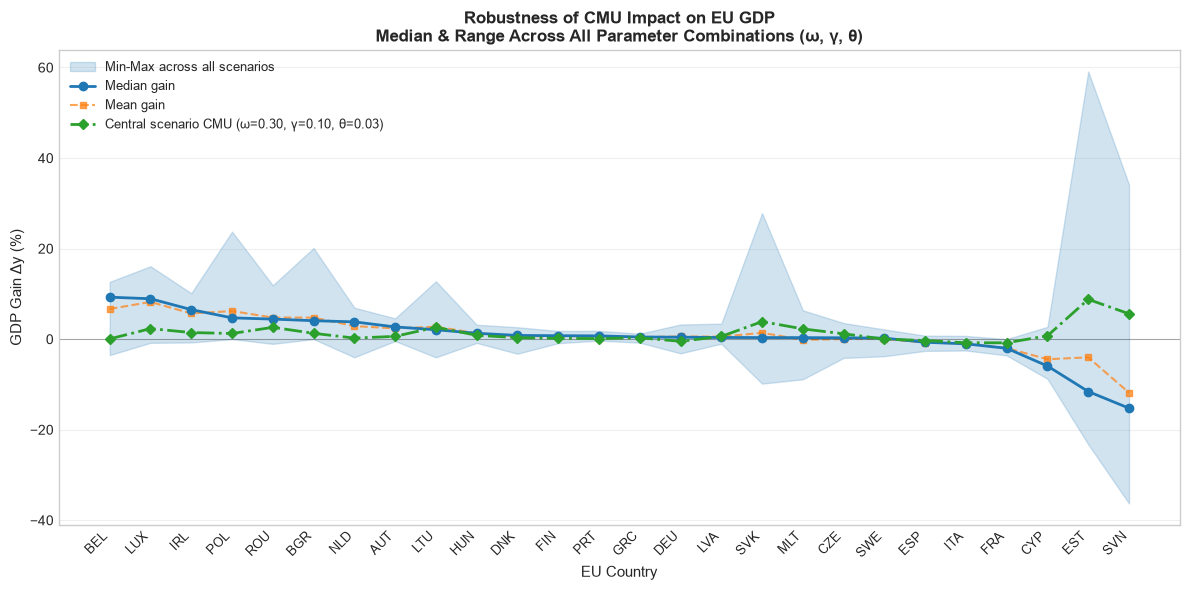

EU GDP Gain Robustness Summary
Country    Central scenario Median       Mean         Min          Max          Range       
--------------------------------------------------------------------------------
BEL              0.051%       9.267%       6.665%      -3.521%      12.656%      16.177%
LUX              2.323%       8.920%       8.219%      -0.819%      16.095%      16.915%
IRL              1.451%       6.516%       5.675%      -0.736%      10.143%      10.879%
POL              1.243%       4.696%       6.195%       0.000%      23.732%      23.732%
ROU              2.603%       4.424%       4.776%      -1.045%      11.885%      12.930%
BGR              1.287%       4.071%       4.746%       0.000%      20.118%      20.118%
NLD              0.228%       3.812%       2.879%      -4.017%       6.946%      10.963%
AUT              0.608%       2.698%       2.373%      -0.422%       4.586%       5.007%
LTU              2.625%       2.071%       2.736%      -4.025%      12.776%      16

In [49]:
# Robustness bands: EU GDP gain - median line + min/max band across all omega*gamma*theta combinations

# For each country, calculate GDP gain across all parameter combinations
df_robustness = []

for country in df_output_country_EU['country'].unique():
    country_data = df_output_country_EU[df_output_country_EU['country'] == country]
    
    # Calculate GDP gain percentage for each parameter combination
    country_data_copy = country_data.copy()
    country_data_copy['dy_pct'] = (country_data_copy['y_cmu'] - country_data_copy['y_baseline']) / country_data_copy['y_baseline'] * 100
    
    # Get all unique parameter combinations
    for (omega, gamma, theta), group in country_data_copy.groupby(['omega', 'gamma', 'theta']):
        dy_pct = group['dy_pct'].values[0]
        df_robustness.append({
            'country': country,
            'omega': omega,
            'gamma': gamma,
            'theta': theta,
            'dy_pct': dy_pct
        })

df_robustness = pd.DataFrame(df_robustness)

# Group by country and calculate statistics
robustness_stats = []
for country in sorted(df_robustness['country'].unique()):
    country_gains = df_robustness[df_robustness['country'] == country]['dy_pct']
    
    robustness_stats.append({
        'country': country,
        'dy_median': country_gains.median(),
        'dy_mean': country_gains.mean(),
        'dy_min': country_gains.min(),
        'dy_max': country_gains.max(),
        'dy_std': country_gains.std()
    })

df_stats = pd.DataFrame(robustness_stats).sort_values('dy_median', ascending=False)

# Get central scenario case for each country
most_prob_gains = []
for country in sorted(df_output_country_EU['country'].unique()):
    country_data = df_output_country_EU[
        (df_output_country_EU['country'] == country) &
        (df_output_country_EU['theta'] == CMU_THETA) &
        (df_output_country_EU['omega'] == CMU_OMEGA) &
        (df_output_country_EU['gamma'] == CMU_GAMMA)
    ]
    if len(country_data) > 0:
        dy_pct = (country_data['y_cmu'].values[0] - country_data['y_baseline'].values[0]) / country_data['y_baseline'].values[0] * 100
        most_prob_gains.append({'country': country, 'dy_prob': dy_pct})

df_prob = pd.DataFrame(most_prob_gains)
df_stats = df_stats.merge(df_prob, on='country', how='left')

# Plot robustness bands
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(df_stats))

# Min-max band (light shading)
ax.fill_between(x_pos, df_stats['dy_min'], df_stats['dy_max'], 
                alpha=0.2, color='C0', label='Min-Max across all scenarios')

# Median line
ax.plot(x_pos, df_stats['dy_median'], marker='o', linewidth=2, 
        markersize=6, color='C0', label='Median gain', zorder=3)

# Mean line (optional, dashed)
ax.plot(x_pos, df_stats['dy_mean'], marker='s', linewidth=1.5, 
        markersize=4, linestyle='--', color='C1', alpha=0.7, label='Mean gain', zorder=2)

# Central scenario CMU case
ax.plot(x_pos, df_stats['dy_prob'], marker='D', linewidth=2, 
        markersize=5, linestyle='-.', color='C2', label=f"Central scenario CMU (ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})", zorder=3)

# Horizontal zero line
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

# Formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(df_stats['country'], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('EU Country', fontsize=11)
ax.set_ylabel('GDP Gain Δy (%)', fontsize=11)
ax.set_title('Robustness of CMU Impact on EU GDP\nMedian & Range Across All Parameter Combinations (ω, γ, θ)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.savefig("imgs/robustness_bands_gdp_gain.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary statistics
print("EU GDP Gain Robustness Summary")
print("=" * 80)
print(f"{'Country':<10} {'Central scenario':<12} {'Median':<12} {'Mean':<12} {'Min':<12} {'Max':<12} {'Range':<12}")
print("-" * 80)
for _, row in df_stats.iterrows():
    range_val = row['dy_max'] - row['dy_min']
    print(f"{row['country']:<10} {row['dy_prob']:>11.3f}% {row['dy_median']:>11.3f}% {row['dy_mean']:>11.3f}% {row['dy_min']:>11.3f}% {row['dy_max']:>11.3f}% {range_val:>11.3f}%")
print("-" * 80)

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/1774160431.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pred["a_ij"]      = pred["a_ij"] * 1e6
/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/177416043

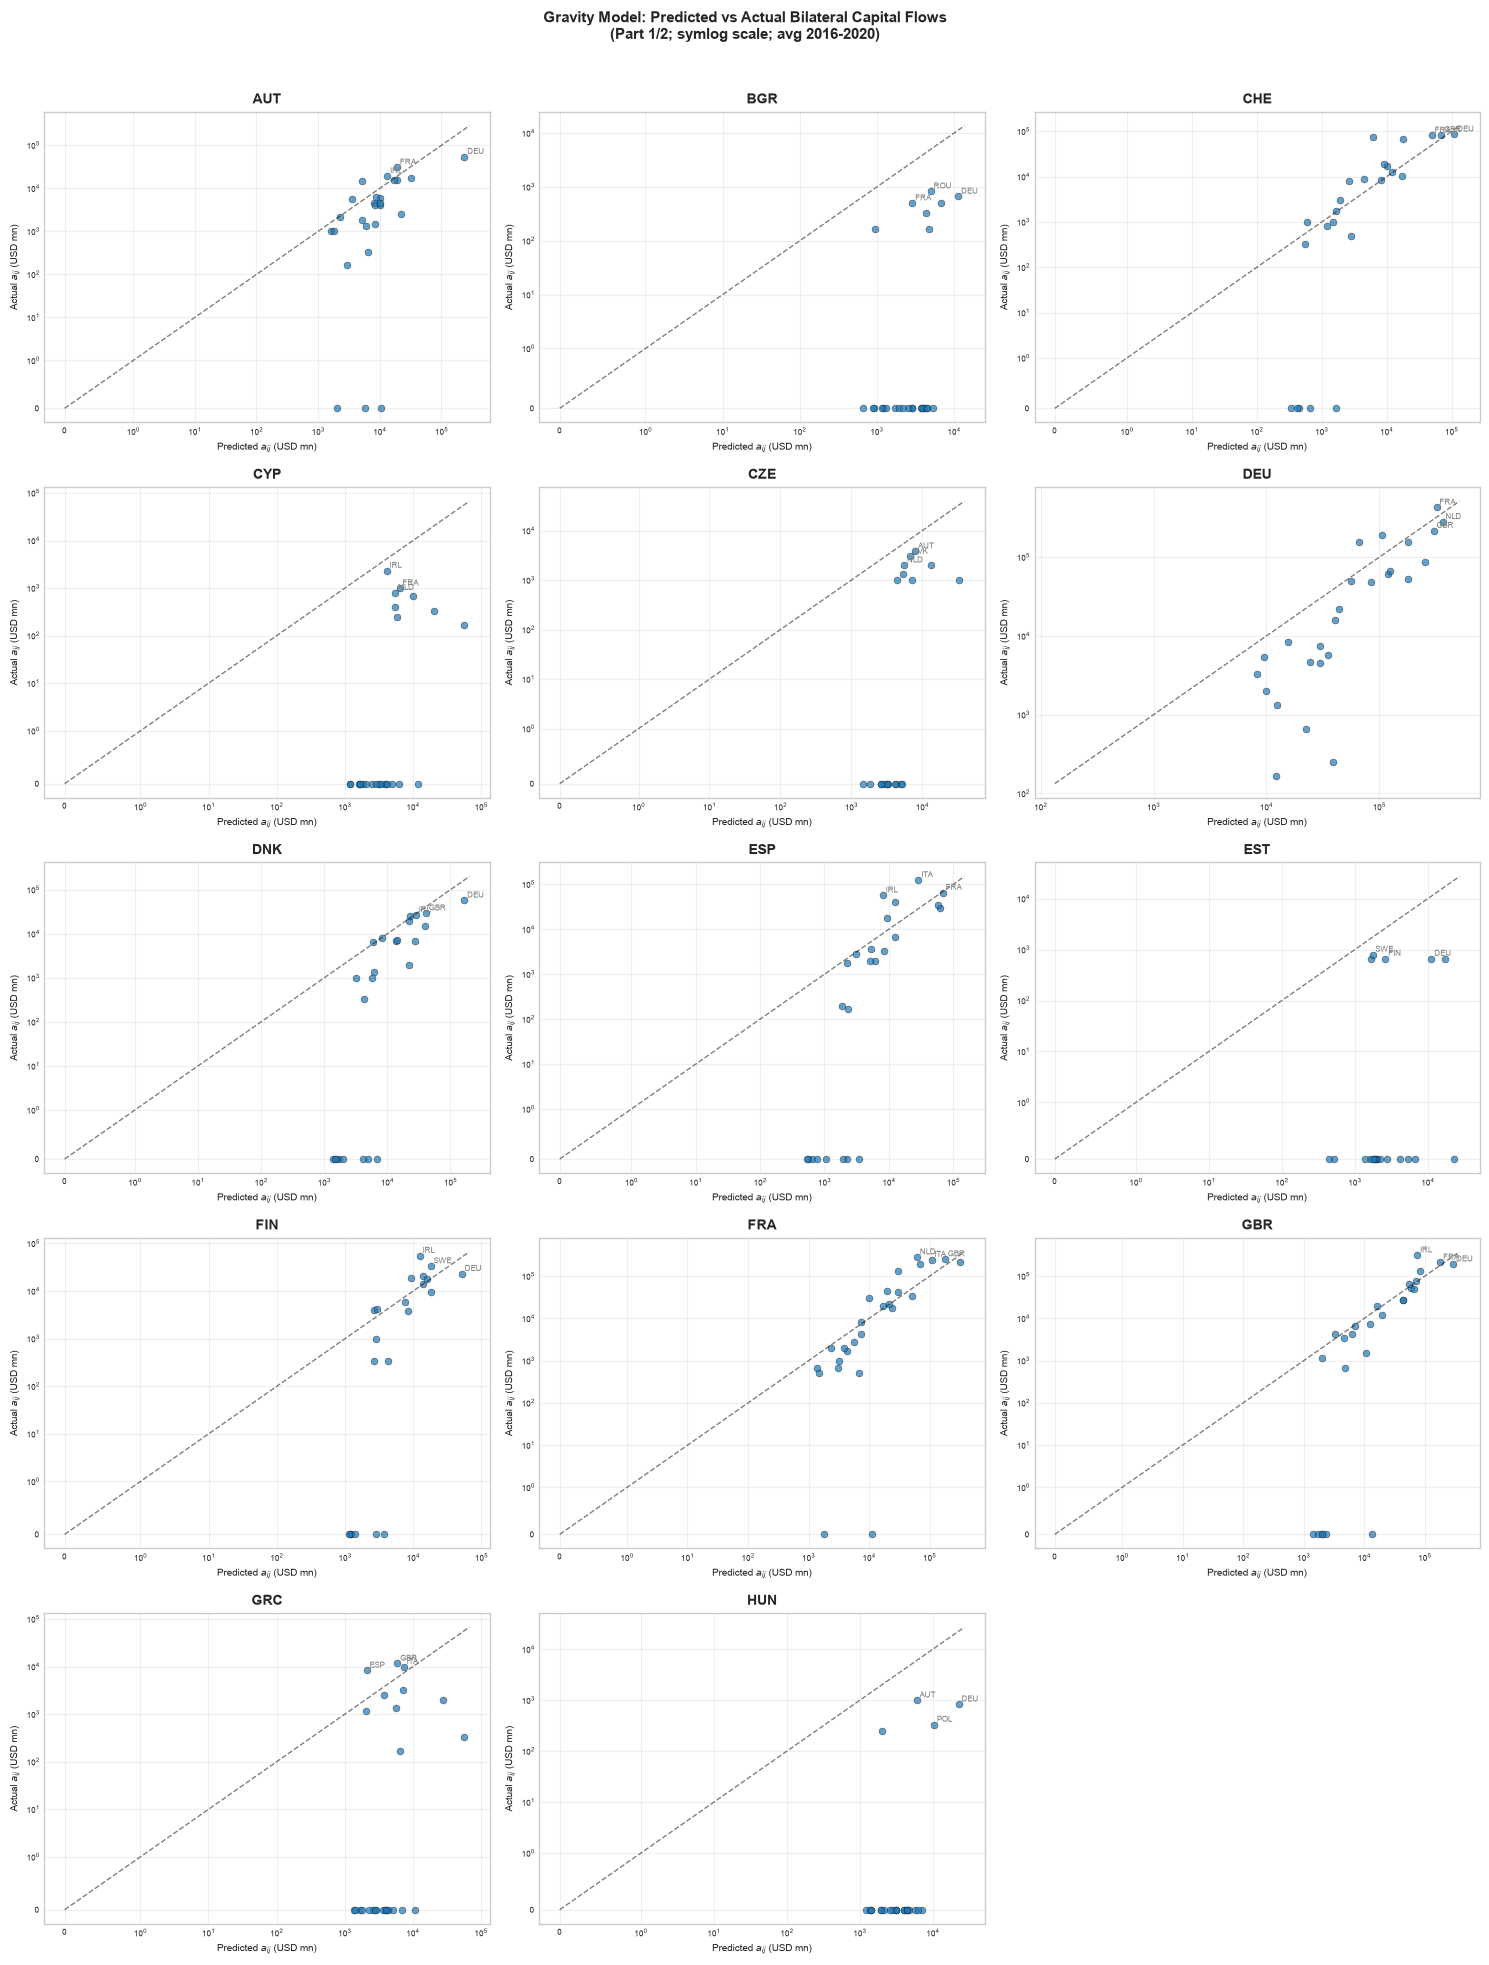

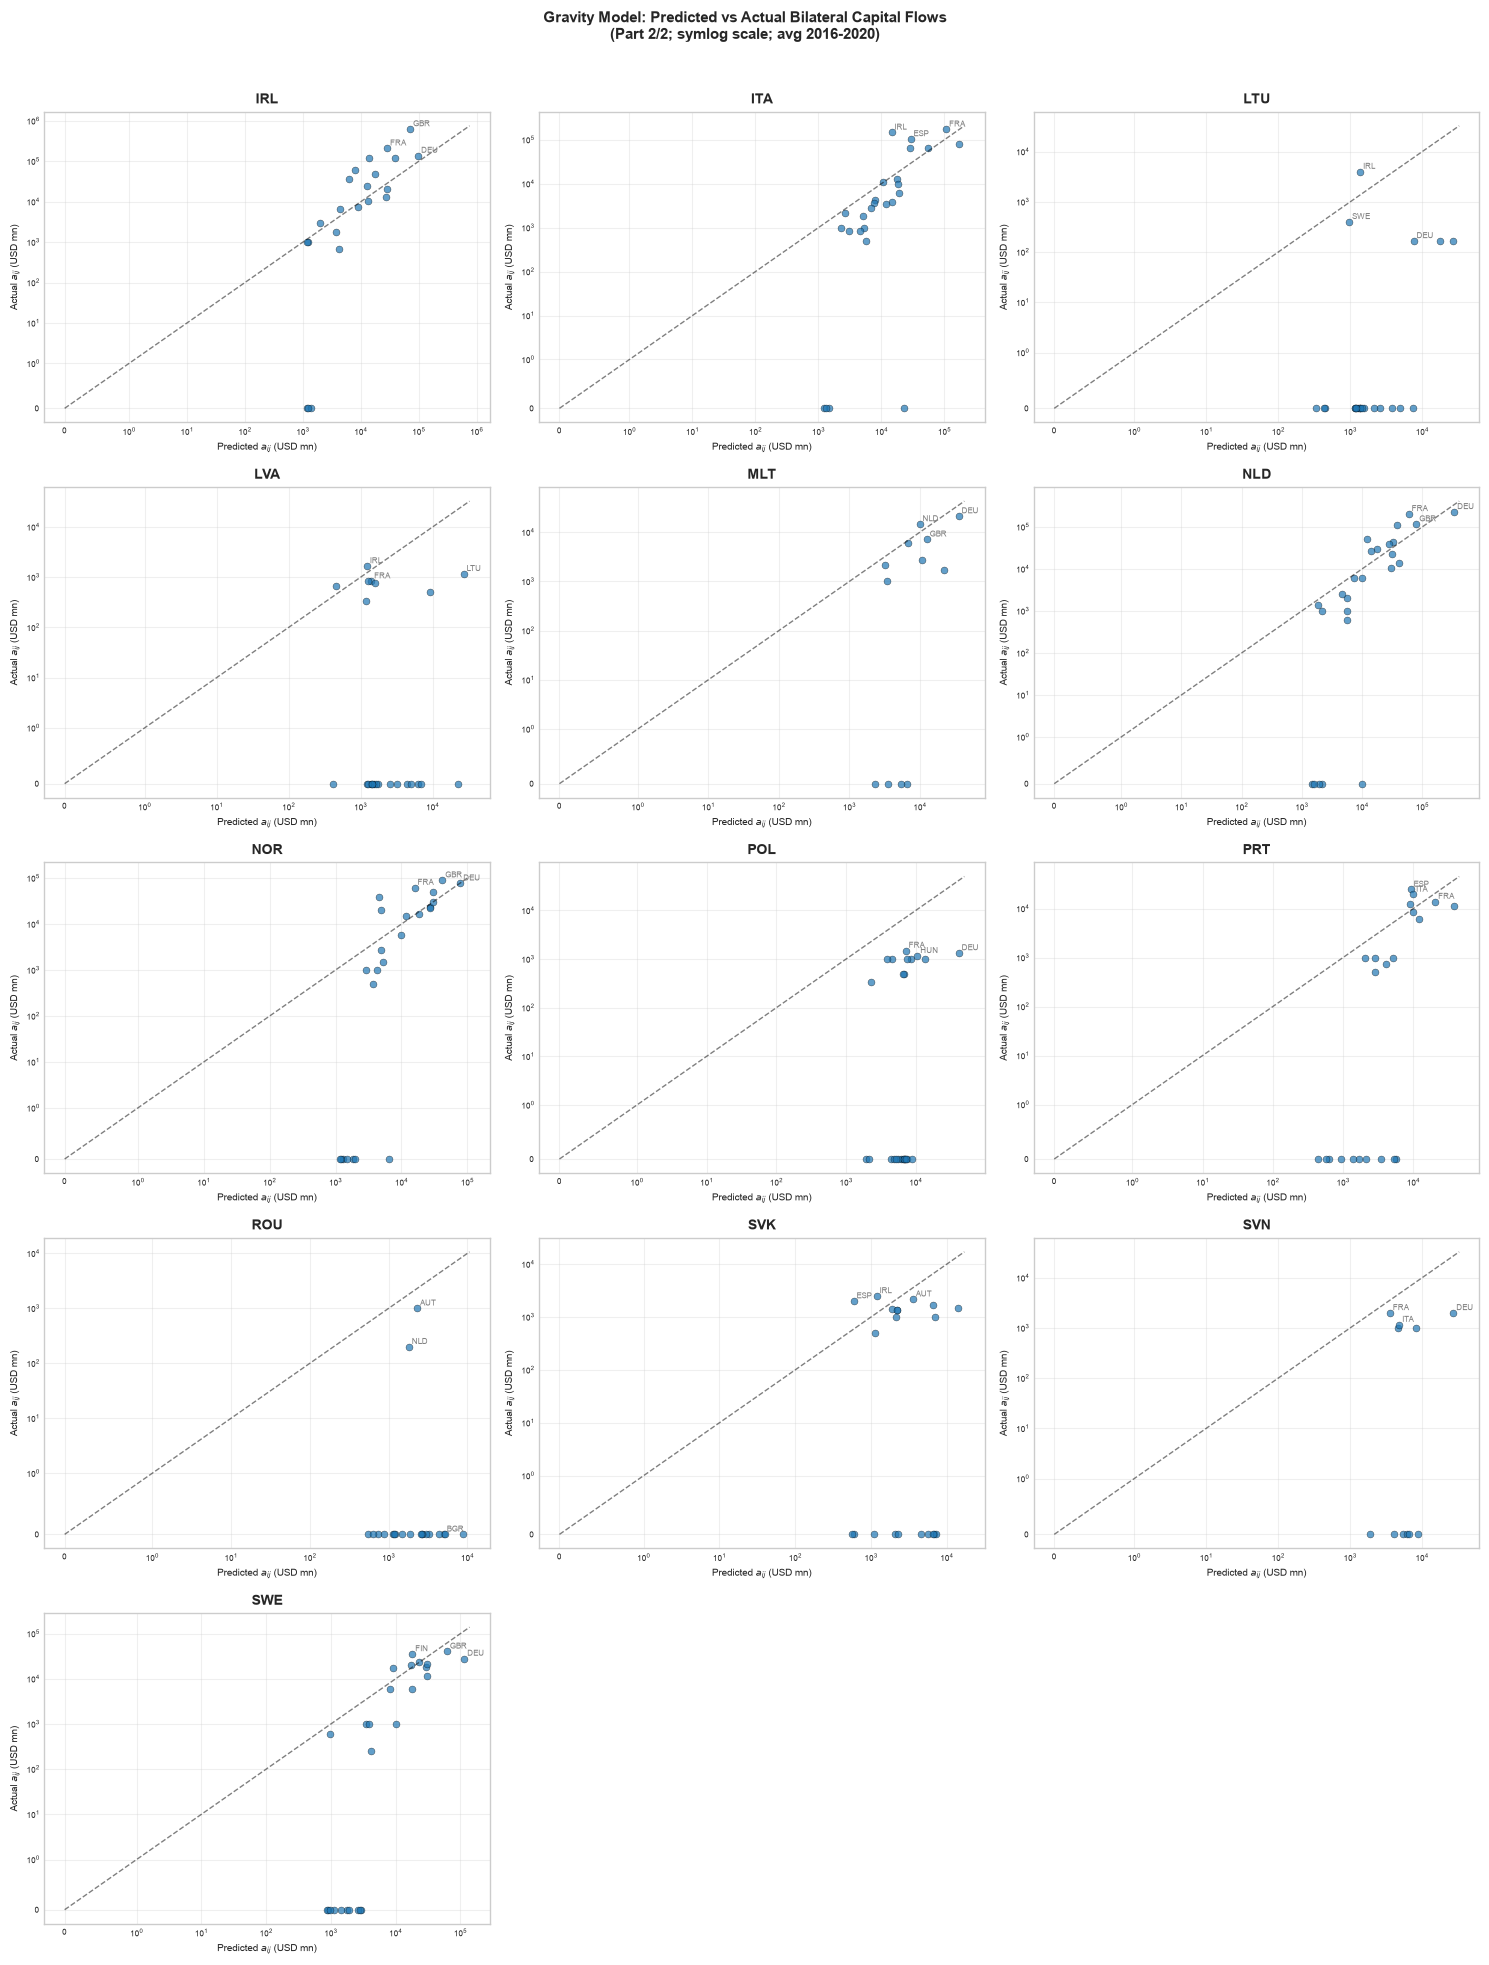

In [50]:
# ── Gravity model: predicted vs actual bilateral flows per source country (split in 2 figures) ──
import math
import numpy as np

pred = pd.read_csv("v4-gravity_pred.csv")

# Values in the CSV were divided by 1e6 before fitting; convert back to USD mn
pred["a_ij"]      = pred["a_ij"] * 1e6
pred["a_ij_pred"] = pred["a_ij_pred"] * 1e6

# Average over years so each (i,j) pair has one point
pred_avg = pred.groupby(["iso3_i", "iso3_j"])[["a_ij", "a_ij_pred"]].mean().reset_index()

countries = sorted(pred_avg["iso3_i"].unique())
country_chunks = np.array_split(countries, 2)  # split into two figures
ncols = 3

for part_idx, chunk in enumerate(country_chunks, start=1):
    chunk = list(chunk)
    n_countries = len(chunk)
    nrows = math.ceil(n_countries / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = np.atleast_1d(axes).flatten()

    for ax, country in zip(axes, chunk):
        sub = pred_avg[pred_avg["iso3_i"] == country].copy()

        x = sub["a_ij_pred"]
        y = sub["a_ij"]

        ax.scatter(x, y, s=25, alpha=0.7, edgecolors="black", linewidths=0.3, color="C0")

        # 45-degree perfect-fit line across the data range
        lim_min = min(x.min(), y.min()) * 0.8
        lim_max = max(x.max(), y.max()) * 1.2
        ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, alpha=0.5, label="y = x")

        # Label a few outlier destination points
        for _, row in sub.nlargest(3, "a_ij").iterrows():
            ax.annotate(
                row["iso3_j"],
                xy=(row["a_ij_pred"], row["a_ij"]),
                fontsize=5.5,
                color="grey",
                xytext=(2, 2),
                textcoords="offset points",
            )

        ax.set_xscale("symlog", linthresh=1)
        ax.set_yscale("symlog", linthresh=1)
        ax.set_title(country, fontsize=10, fontweight="bold")
        ax.set_xlabel("Predicted $a_{ij}$ (USD mn)", fontsize=7)
        ax.set_ylabel("Actual $a_{ij}$ (USD mn)", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.3)

    # Hide unused subplot panels
    for ax in axes[n_countries:]:
        ax.set_visible(False)

    plt.suptitle(
        "Gravity Model: Predicted vs Actual Bilateral Capital Flows\n"
        f"(Part {part_idx}/2; symlog scale; avg 2016-2020)",
        fontsize=11,
        fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f"imgs/gravity_pred_vs_actual_grid_part{part_idx}.png", dpi=150, bbox_inches="tight")
    plt.show()

# New Visualisations

In [51]:
# Load extra sheets needed for new visualisations
df_mpk        = pd.read_excel(xls, 'MPK_Dispersion')
df_robustness = pd.read_excel(xls, 'Robustness')

print("MPK_Dispersion columns:", list(df_mpk.columns[:6]), "...")
print("Robustness columns:    ", list(df_robustness.columns))
print(f"Robustness rows: {len(df_robustness):,}")


MPK_Dispersion columns: ['country', 'mpk_baseline_theta0.100', 'mpk_om0.000_gm0.000', 'mpk_om0.000_gm0.053', 'mpk_om0.000_gm0.105', 'mpk_om0.000_gm0.158'] ...
Robustness columns:     ['label', 'eta', 'theta', 'omega', 'gamma', 'ΔY_EU/Y_EU (%)', 'Avg ΔHomeBias (EU)']
Robustness rows: 24,000


In [52]:
# Calculate capital flows from non-EU to EU countries — DECOMPOSED BY (ω, γ, θ)
import numpy as np
import pandas as pd

# Define sets
EU_SET = set(EU27)
COUNTRIES_SET = set(COUNTRIES)
NON_EU_SET = COUNTRIES_SET - EU_SET

# Load bilateral flows
df_flows = pd.read_excel(xls, 'Portfolio_Flows')

# Filter: source is non-EU, destination is EU
df_noneu_to_eu = df_flows[
    (df_flows['iso3_i'].isin(NON_EU_SET)) &
    (df_flows['iso3_j'].isin(EU_SET))
].copy()

# Aggregate by (omega, gamma, theta) — not by scenario name
flows_by_params = (
    df_noneu_to_eu
    .groupby(['omega', 'gamma', 'theta'])['k_flow']
    .sum()
    .reset_index()
    .rename(columns={'k_flow': 'noneu_to_eu_inflow'})
    .sort_values(['omega', 'gamma', 'theta'])
)

print("=" * 70)
print("NON-EU → EU CAPITAL FLOWS (DECOMPOSED BY ω, γ, θ)")
print("=" * 70)
print(flows_by_params)
print()

# Calculate percentage change from baseline (0, 0, 0)
baseline_val = flows_by_params[
    (flows_by_params['omega'] == 0) &
    (flows_by_params['gamma'] == 0) &
    (flows_by_params['theta'] == 0)
]['noneu_to_eu_inflow'].values[0]

flows_by_params['pct_change_vs_baseline'] = (
    (flows_by_params['noneu_to_eu_inflow'] - baseline_val) / baseline_val * 100
)

print("With percentage change vs baseline:")
print(flows_by_params[['omega', 'gamma', 'theta', 'noneu_to_eu_inflow', 'pct_change_vs_baseline']])
print()

# Summary stats
print("Summary by individual parameters (averaged over the other two):")
print("\nBy ω (averaged over γ, θ):")
print(flows_by_params.groupby('omega')[['noneu_to_eu_inflow', 'pct_change_vs_baseline']].agg(['mean', 'std', 'min', 'max']).round(4))
print("\nBy γ (averaged over ω, θ):")
print(flows_by_params.groupby('gamma')[['noneu_to_eu_inflow', 'pct_change_vs_baseline']].agg(['mean', 'std', 'min', 'max']).round(4))
print("\nBy θ (averaged over ω, γ):")
print(flows_by_params.groupby('theta')[['noneu_to_eu_inflow', 'pct_change_vs_baseline']].agg(['mean', 'std', 'min', 'max']).round(4))

NON-EU → EU CAPITAL FLOWS (DECOMPOSED BY ω, γ, θ)
   omega  gamma  theta  noneu_to_eu_inflow
0  0.000  0.000  0.000        2.594883e+06
1  0.316  0.105  0.032        2.519916e+06
2  0.474  0.474  0.053        2.356798e+06
3  1.000  1.000  0.100        1.993590e+06

With percentage change vs baseline:
   omega  gamma  theta  noneu_to_eu_inflow  pct_change_vs_baseline
0  0.000  0.000  0.000        2.594883e+06                0.000000
1  0.316  0.105  0.032        2.519916e+06               -2.889042
2  0.474  0.474  0.053        2.356798e+06               -9.175161
3  1.000  1.000  0.100        1.993590e+06              -23.172241

Summary by individual parameters (averaged over the other two):

By ω (averaged over γ, θ):
      noneu_to_eu_inflow                                  \
                    mean std           min           max   
omega                                                      
0.000       2.594883e+06 NaN  2.594883e+06  2.594883e+06   
0.316       2.519916e+06 NaN  

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/280469492.py:42: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  flows_by_params['pct_change_vs_baseline'] = (


In [53]:
# Calculate total foreign-investor capital in EU — DECOMPOSED BY (ω, γ, θ)
import numpy as np
import pandas as pd

# Use country-level output data (already loaded earlier)
required_cols = {'omega', 'gamma', 'theta', 'in_EU27', 'k_fin_cmu'}
missing = required_cols - set(df_output_country.columns)
if missing:
    raise KeyError(f"Missing required columns in df_output_country: {missing}")

# Keep EU destination countries only
df_eu_cap = df_output_country[df_output_country['in_EU27'] == 1].copy()

# Aggregate total foreign-investor capital by parameter triplet
cap_by_params = (
    df_eu_cap
    .groupby(['omega', 'gamma', 'theta'], as_index=False)['k_fin_cmu']
    .sum()
    .rename(columns={'k_fin_cmu': 'eu_foreign_capital_total'})
    .sort_values(['omega', 'gamma', 'theta'])
)

print("=" * 70)
print("EU TOTAL FOREIGN-INVESTOR CAPITAL (DECOMPOSED BY ω, γ, θ)")
print("=" * 70)
print(cap_by_params)
print()

# Baseline at (0,0,0)
baseline_val = cap_by_params[
    np.isclose(cap_by_params['omega'], 0) &
    np.isclose(cap_by_params['gamma'], 0) &
    np.isclose(cap_by_params['theta'], 0)
]['eu_foreign_capital_total'].values[0]

cap_by_params['pct_change_vs_baseline'] = (
    (cap_by_params['eu_foreign_capital_total'] - baseline_val) / baseline_val * 100
)

print("With percentage change vs baseline:")
print(cap_by_params[['omega', 'gamma', 'theta', 'eu_foreign_capital_total', 'pct_change_vs_baseline']])
print()

print("Summary by individual parameters (averaged over the other two):")
print("\nBy ω (averaged over γ, θ):")
print(cap_by_params.groupby('omega')[['eu_foreign_capital_total', 'pct_change_vs_baseline']].agg(['mean', 'std', 'min', 'max']).round(4))
print("\nBy γ (averaged over ω, θ):")
print(cap_by_params.groupby('gamma')[['eu_foreign_capital_total', 'pct_change_vs_baseline']].agg(['mean', 'std', 'min', 'max']).round(4))
print("\nBy θ (averaged over ω, γ):")
print(cap_by_params.groupby('theta')[['eu_foreign_capital_total', 'pct_change_vs_baseline']].agg(['mean', 'std', 'min', 'max']).round(4))

EU TOTAL FOREIGN-INVESTOR CAPITAL (DECOMPOSED BY ω, γ, θ)
      omega  gamma  theta  eu_foreign_capital_total
0       0.0    0.0  0.000              3.880330e+07
1       0.0    0.0  0.005              3.880330e+07
2       0.0    0.0  0.011              3.880330e+07
3       0.0    0.0  0.016              3.880330e+07
4       0.0    0.0  0.021              3.880330e+07
...     ...    ...    ...                       ...
7995    1.0    1.0  0.079              4.079882e+07
7996    1.0    1.0  0.084              4.079882e+07
7997    1.0    1.0  0.089              4.079882e+07
7998    1.0    1.0  0.095              4.079882e+07
7999    1.0    1.0  0.100              4.079882e+07

[8000 rows x 4 columns]

With percentage change vs baseline:
      omega  gamma  theta  eu_foreign_capital_total  pct_change_vs_baseline
0       0.0    0.0  0.000              3.880330e+07                0.000000
1       0.0    0.0  0.005              3.880330e+07                0.000000
2       0.0    0.0  0.011   

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/2982475681.py:36: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  cap_by_params['pct_change_vs_baseline'] = (


In [54]:
# # ...existing code...
# # Styled 3-panel impact plots from cap_by_params only
# # Uses: min/max band from group stats + central scenario path
# import numpy as np
# import matplotlib.pyplot as plt

# # Safety checks
# required_cols = {'omega', 'gamma', 'theta', 'eu_foreign_capital_total', 'pct_change_vs_baseline'}
# missing = required_cols - set(cap_by_params.columns)
# if missing:
#     raise KeyError(f"cap_by_params missing columns: {missing}")

# configs = [
#     {
#         'param': 'omega',
#         'others': ['gamma', 'theta'],
#         'fixed': {'gamma': CMU_GAMMA, 'theta': CMU_THETA},
#         'symbol': r'$\omega$',
#     },
#     {
#         'param': 'gamma',
#         'others': ['omega', 'theta'],
#         'fixed': {'omega': CMU_OMEGA, 'theta': CMU_THETA},
#         'symbol': r'$\gamma$',
#     },
#     {
#         'param': 'theta',
#         'others': ['omega', 'gamma'],
#         'fixed': {'omega': CMU_OMEGA, 'gamma': CMU_GAMMA},
#         'symbol': r'$\theta$',
#     },
# ]

# fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

# for ax, cfg in zip(axes, configs):
#     p = cfg['param']
#     o1, o2 = cfg['others']
#     s = cfg['symbol']

#     # Min-max band over all combinations of the other two parameters
#     summary = (
#         cap_by_params.groupby(p)['pct_change_vs_baseline']
#         .agg(y_min='min', y_max='max', y_mean='mean')
#         .reset_index()
#         .sort_values(p)
#     )

#     # Central scenario path: vary p, keep other two at CMU values
#     mp = cap_by_params.copy()
#     for k, v in cfg['fixed'].items():
#         mp = mp[np.isclose(mp[k], v)]

#     mp = (
#         mp.groupby(p)['pct_change_vs_baseline']
#         .mean()
#         .reset_index()
#         .sort_values(p)
#     )

#     ax.fill_between(
#         summary[p], summary['y_min'], summary['y_max'],
#         alpha=0.25, color='C0', label=rf'Min–Max (all {o1}, {o2})'
#     )
#     ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
#     ax.plot(
#         mp[p], mp['pct_change_vs_baseline'],
#         color='black', linewidth=2, marker='o', markersize=4,
#         label='Central scenario path'
#     )

#     ax.set_xlabel(s)
#     ax.set_title(rf'Impact of {s} on EU foreign-investor capital')
#     ax.grid(alpha=0.3)

# axes[0].set_ylabel(r'$\Delta$ capital / capital$_{baseline}$ (%)')

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

# plt.tight_layout()
# plt.savefig("imgs/eu_foreign_capital_1d_impact_bands.png", dpi=150, bbox_inches="tight")
# plt.show()
# # ...existing code...

In [55]:
# # PLOT HERE
# # Three 1D impact plots: EU net transfer from reallocation (inflow - outflow), scaled by baseline EU capital

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Build scenario-country flow frame
# flow_cols = ["theta", "omega", "gamma", "country", "in_EU27", "k_fin_baseline", "k_fin_cmu"]
# missing_cols = [c for c in flow_cols if c not in df_output_country.columns]
# if missing_cols:
#     raise KeyError(f"Missing required columns in df_output_country: {missing_cols}")

# df_flow = df_output_country[flow_cols].copy()
# df_flow = df_flow.drop_duplicates(subset=["theta", "omega", "gamma", "country"]).copy()
# df_flow["net_flow"] = df_flow["k_fin_cmu"] - df_flow["k_fin_baseline"]

# # EU-only data
# eu_flow = df_flow[df_flow["in_EU27"] == 1].copy()

# # Scenario-level EU inflow/outflow/net transfer from reallocation
# grp_eu = (
#     eu_flow
#     .groupby(["theta", "omega", "gamma"], as_index=False)
#     .agg(
#         eu_inflow=("net_flow", lambda s: s[s > 0].sum()),
#         eu_outflow=("net_flow", lambda s: -s[s < 0].sum()),
#         eu_baseline_capital=("k_fin_baseline", "sum"),
#     )
# )
# grp_eu["eu_net_transfer"] = grp_eu["eu_inflow"] - grp_eu["eu_outflow"]

# # Baseline EU capital stock at (theta, omega, gamma) = (0, 0, 0)
# base_mask = (
#     np.isclose(grp_eu["theta"], 0.0) &
#     np.isclose(grp_eu["omega"], 0.0) &
#     np.isclose(grp_eu["gamma"], 0.0)
# )
# if not base_mask.any():
#     raise ValueError("No baseline scenario found at theta=0, omega=0, gamma=0.")

# eu_capital_base = grp_eu.loc[base_mask, "eu_baseline_capital"].mean()
# if np.isclose(eu_capital_base, 0.0):
#     raise ValueError("Baseline EU capital stock is zero; cannot scale net transfer.")

# # This is the meaningful percentage metric:
# # net transfer to EU as % of baseline EU financial capital stock
# grp_eu["eu_net_transfer_pct_of_base"] = grp_eu["eu_net_transfer"] / eu_capital_base * 100

# # Print the central scenario change as a percentage
# mp_mask = (
#     np.isclose(grp_eu["theta"], CMU_THETA) &
#     np.isclose(grp_eu["omega"], CMU_OMEGA) &
#     np.isclose(grp_eu["gamma"], CMU_GAMMA)
# )
# if mp_mask.any():
#     mp_change_pct = grp_eu.loc[mp_mask, "eu_net_transfer_pct_of_base"].mean()
#     print(
#         f"Central scenario EU net-transfer change = {mp_change_pct:.4f}% "
#         f"(ω={CMU_OMEGA:.3f}, γ={CMU_GAMMA:.3f}, θ={CMU_THETA:.3f})"
#     )
# else:
#     print("WARNING: Central scenario (ω,γ,θ) scenario not found on current grid.")

# configs = [
#     {
#         'param': 'omega',
#         'others': ['gamma', 'theta'],
#         'fixed': {'gamma': CMU_GAMMA, 'theta': CMU_THETA},
#         'symbol': r'$\omega$',
#     },
#     {
#         'param': 'gamma',
#         'others': ['omega', 'theta'],
#         'fixed': {'omega': CMU_OMEGA, 'theta': CMU_THETA},
#         'symbol': r'$\gamma$',
#     },
#     {
#         'param': 'theta',
#         'others': ['omega', 'gamma'],
#         'fixed': {'omega': CMU_OMEGA, 'gamma': CMU_GAMMA},
#         'symbol': r'$\theta$',
#     },
# ]

# fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

# for ax, cfg in zip(axes, configs):
#     p = cfg['param']
#     o1, o2 = cfg['others']
#     s = cfg['symbol']

#     # Uncertainty band over all scenarios for each x-value of parameter p
#     summary = (
#         grp_eu.groupby(p)["eu_net_transfer_pct_of_base"]
#         .agg(y_min='min', y_max='max', y_mean='mean')
#         .reset_index()
#         .sort_values(p)
#     )

#     # Central scenario path: vary p, keep other two at central scenario values
#     mp = grp_eu.copy()
#     for k, v in cfg['fixed'].items():
#         mp = mp[np.isclose(mp[k], v)]
#     mp = (
#         mp.groupby(p)["eu_net_transfer_pct_of_base"]
#         .mean()
#         .reset_index()
#         .sort_values(p)
#     )

#     ax.fill_between(
#         summary[p], summary['y_min'], summary['y_max'],
#         alpha=0.25, color='C0', label=rf'Min–Max (all {o1}, {o2})'
#     )

#     # Zero reference line
#     ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)

#     # Black line for central scenario scenario path
#     ax.plot(
#         mp[p], mp['eu_net_transfer_pct_of_base'],
#         color='black', linewidth=2, marker='o', markersize=4,
#         label='Central scenario path'
#     )

#     ax.set_xlabel(s)
#     ax.set_title(rf'Impact of {s} on EU net transfer')
#     ax.grid(alpha=0.3)

# axes[0].set_ylabel('EU net transfer (% of baseline EU capital)')

# # Centered legend below the plots
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

# plt.tight_layout()
# plt.savefig("imgs/eu_net_transfer_pct_of_baseline_capital_1d.png", dpi=150, bbox_inches="tight")
# plt.show()

# # For each parameter path, print mean, median, std, min, max, and corr(x,y)
# print("=" * 80)
# print("SUMMARY STATS PER PARAMETER (y = EU net transfer % of baseline EU capital)")
# print("=" * 80)

# for cfg in configs:
#     p = cfg["param"]
#     s = cfg["symbol"]

#     d = grp_eu[[p, "eu_net_transfer_pct_of_base"]].dropna().copy()
#     corr = d[p].corr(d["eu_net_transfer_pct_of_base"]) if d[p].nunique() > 1 else np.nan

#     print(f"\nParameter {p} ({s}):")
#     print(f"  mean(y):   {d['eu_net_transfer_pct_of_base'].mean(): .6f}")
#     print(f"  median(y): {d['eu_net_transfer_pct_of_base'].median(): .6f}")
#     print(f"  std(y):    {d['eu_net_transfer_pct_of_base'].std(): .6f}")
#     print(f"  min(y):    {d['eu_net_transfer_pct_of_base'].min(): .6f}")
#     print(f"  max(y):    {d['eu_net_transfer_pct_of_base'].max(): .6f}")
#     print(f"  corr(x,y): {corr: .6f}")

EU → EU investment, including domestic:
Baseline EU → EU investment: 36,208,421.84
CMU EU → EU investment:      36,513,645.01
Change:                     305,223.17
Change (%):                 0.84%

Cross-border EU → EU investment only:
Baseline cross-border EU → EU: 12,113,059.23
CMU cross-border EU → EU:      16,107,475.77
Change:                       3,994,416.54
Change (%):                   32.98%

EU → non-EU investment:
Baseline EU → non-EU investment: 3,093,672.93
CMU EU → non-EU investment:      2,788,449.75
Change:                         -305,223.17
Change (%):                     -9.87%

Non-EU → EU investment:
Baseline Non-EU → EU investment: 2,594,882.78
CMU Non-EU → EU investment:      2,519,915.52
Change:                         -74,967.26
Change (%):                     -2.89%


/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/918805386.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_flows["origin_in_eu"] = df_flows["iso3_i"].isin(EU_SET)
/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipyker

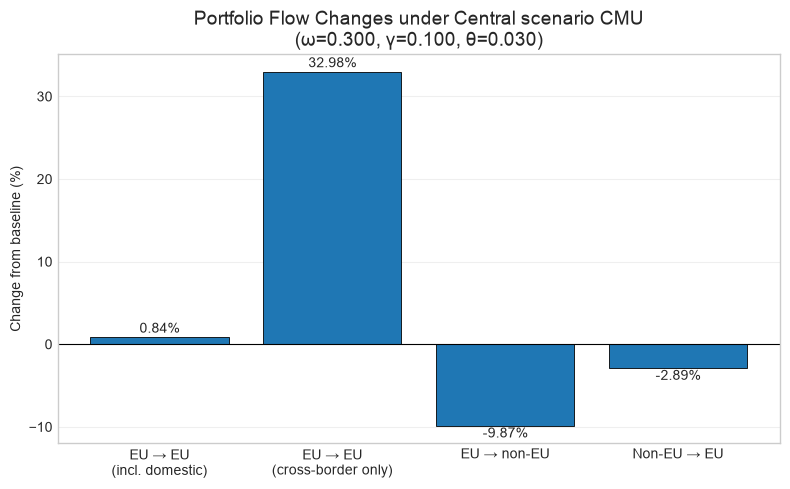

,flow_type,change_pct
0,EU → EU\n(incl. domestic),0.843
1,EU → EU\n(cross-border only),32.976
2,EU → non-EU,-9.866
3,Non-EU → EU,-2.889


In [56]:
df_flows = pd.read_excel(xls, "Portfolio_Flows")

EU_SET = set(EU27)

df_flows["origin_in_eu"] = df_flows["iso3_i"].isin(EU_SET)
df_flows["dest_in_eu"] = df_flows["iso3_j"].isin(EU_SET)
df_flows["is_domestic"] = df_flows["iso3_i"] == df_flows["iso3_j"]

# ------------------------------------------------------------
# 1. EU investors investing in EU destinations
#    This includes domestic + cross-border intra-EU investment.
# ------------------------------------------------------------
df_eu_to_eu = df_flows[
    (df_flows["origin_in_eu"]) &
    (df_flows["dest_in_eu"])
].copy()

baseline_eu_to_eu = (
    df_eu_to_eu[df_eu_to_eu["scenario"] == "baseline"]["k_flow"].sum()
)

cmu_eu_to_eu = (
    df_eu_to_eu[df_eu_to_eu["scenario"] == "most_probable"]["k_flow"].sum()
)

change_abs = cmu_eu_to_eu - baseline_eu_to_eu
change_pct = change_abs / baseline_eu_to_eu

print("EU → EU investment, including domestic:")
print(f"Baseline EU → EU investment: {baseline_eu_to_eu:,.2f}")
print(f"CMU EU → EU investment:      {cmu_eu_to_eu:,.2f}")
print(f"Change:                     {change_abs:,.2f}")
print(f"Change (%):                 {change_pct:.2%}")


# ------------------------------------------------------------
# 2. Cross-border intra-EU investment only
#    This excludes domestic i = j flows.
# ------------------------------------------------------------
df_eu_to_eu_crossborder = df_flows[
    (df_flows["origin_in_eu"]) &
    (df_flows["dest_in_eu"]) &
    (~df_flows["is_domestic"])
].copy()

baseline_eu_crossborder = (
    df_eu_to_eu_crossborder[
        df_eu_to_eu_crossborder["scenario"] == "baseline"
    ]["k_flow"].sum()
)

cmu_eu_crossborder = (
    df_eu_to_eu_crossborder[
        df_eu_to_eu_crossborder["scenario"] == "most_probable"
    ]["k_flow"].sum()
)

change_cross_abs = cmu_eu_crossborder - baseline_eu_crossborder
change_cross_pct = change_cross_abs / baseline_eu_crossborder

print("\nCross-border EU → EU investment only:")
print(f"Baseline cross-border EU → EU: {baseline_eu_crossborder:,.2f}")
print(f"CMU cross-border EU → EU:      {cmu_eu_crossborder:,.2f}")
print(f"Change:                       {change_cross_abs:,.2f}")
print(f"Change (%):                   {change_cross_pct:.2%}")


# ------------------------------------------------------------
# 3. EU investors investing outside the EU
#    This shows whether EU capital leaves the EU less/more after CMU.
# ------------------------------------------------------------
df_eu_to_noneu = df_flows[
    (df_flows["origin_in_eu"]) &
    (~df_flows["dest_in_eu"])
].copy()

baseline_eu_to_noneu = (
    df_eu_to_noneu[df_eu_to_noneu["scenario"] == "baseline"]["k_flow"].sum()
)

cmu_eu_to_noneu = (
    df_eu_to_noneu[df_eu_to_noneu["scenario"] == "most_probable"]["k_flow"].sum()
)

change_noneu_abs = cmu_eu_to_noneu - baseline_eu_to_noneu
change_noneu_pct = change_noneu_abs / baseline_eu_to_noneu

print("\nEU → non-EU investment:")
print(f"Baseline EU → non-EU investment: {baseline_eu_to_noneu:,.2f}")
print(f"CMU EU → non-EU investment:      {cmu_eu_to_noneu:,.2f}")
print(f"Change:                         {change_noneu_abs:,.2f}")
print(f"Change (%):                     {change_noneu_pct:.2%}")

# ------------------------------------------------------------
# 4. Non-EU investors investing into EU destinations
#    This measures whether outside countries allocate more capital to the EU.
# ------------------------------------------------------------
df_noneu_to_eu = df_flows[
    (~df_flows["origin_in_eu"]) &
    (df_flows["dest_in_eu"])
].copy()

baseline_noneu_to_eu = (
    df_noneu_to_eu[df_noneu_to_eu["scenario"] == "baseline"]["k_flow"].sum()
)

cmu_noneu_to_eu = (
    df_noneu_to_eu[df_noneu_to_eu["scenario"] == "most_probable"]["k_flow"].sum()
)

change_noneu_to_eu_abs = cmu_noneu_to_eu - baseline_noneu_to_eu
change_noneu_to_eu_pct = change_noneu_to_eu_abs / baseline_noneu_to_eu

print("\nNon-EU → EU investment:")
print(f"Baseline Non-EU → EU investment: {baseline_noneu_to_eu:,.2f}")
print(f"CMU Non-EU → EU investment:      {cmu_noneu_to_eu:,.2f}")
print(f"Change:                         {change_noneu_to_eu_abs:,.2f}")
print(f"Change (%):                     {change_noneu_to_eu_pct:.2%}")

# ------------------------------------------------------------
# 5. Plot percentage changes only
# ------------------------------------------------------------

flow_change_summary = pd.DataFrame({
    "flow_type": [
        "EU → EU\n(incl. domestic)",
        "EU → EU\n(cross-border only)",
        "EU → non-EU",
        "Non-EU → EU",
    ],
    "change_pct": [
        change_pct * 100,
        change_cross_pct * 100,
        change_noneu_pct * 100,
        change_noneu_to_eu_pct * 100,
    ],
})

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    flow_change_summary["flow_type"],
    flow_change_summary["change_pct"],
    edgecolor="black",
    linewidth=0.6,
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Change from baseline (%)")
ax.set_title(
    f"Portfolio Flow Changes under Central scenario CMU\n"
    f"(ω={_CMU_OMEGA:.3f}, γ={_CMU_GAMMA:.3f}, θ={_CMU_THETA:.3f})"
)

# Add percentage labels
for bar, value in zip(bars, flow_change_summary["change_pct"]):
    y_pos = value + 0.2 if value >= 0 else value - 0.2
    va = "bottom" if value >= 0 else "top"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        f"{value:.2f}%",
        ha="center",
        va=va,
        fontsize=10,
    )

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("imgs/portfolio_flow_changes_pct_most_probable.png", dpi=150, bbox_inches="tight")

plt.show()

display(flow_change_summary.round(3))

## 3 · Capital vs TFP decomposition — stacked bars per country

## 4 · θ sensitivity — EU GDP gain vs ω (lines per θ)

## 5 · Δf_i vs ΔA_i scatter — TFP channel validation

In [57]:
# ...existing code...
print("theta grid:", sorted(df_output_country["theta"].unique())[:10], "...")

cand = [c for c in df_output_country.columns if any(k in c.lower() for k in ["a_", "da", "tfp", "f_", "df"])]
print("Relevant columns:", cand)

# Check if y_cmu changes with theta for same country, omega, gamma
chk = (
    df_output_country
    .groupby(["country", "omega", "gamma"])["y_cmu"]
    .nunique()
    .reset_index(name="n_y_over_theta")
)
print("Groups with y_cmu varying over theta:", (chk["n_y_over_theta"] > 1).sum(), "of", len(chk))

# If dA_pct exists, check if effectively zero
if "dA_pct" in df_output_country.columns:
    s = df_output_country["dA_pct"].fillna(0)
    print("dA_pct min/max:", s.min(), s.max(), "nonzero count:", (s.abs() > 1e-12).sum())
# ...existing code...

theta grid: [np.float64(0.0), np.float64(0.005), np.float64(0.011), np.float64(0.016), np.float64(0.021), np.float64(0.026), np.float64(0.032), np.float64(0.037), np.float64(0.042), np.float64(0.047)] ...
Relevant columns: ['A_bar', 'delta_ii', 'delta_hard_mean', 'delta_geo_mean', 'delta_ling_mean', 'delta_immutable_mean', 'delta_soft_policy_mean', 'pi_home_data', 'k_eff_baseline', 'k_eff_cmu', 'dk_eff_pct', 'A_theta', 'tfp_amplification_pct', 'capital_share_of_dy']
Groups with y_cmu varying over theta: 11600 of 11600


/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/3916677598.py:39: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sub[out_col] = sub["dy"]
/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/3916677598.py:39: Futu

=== TFP amplification (holding ω, γ fixed; varying θ only) ===
Definition: Δy_i(θ) - Δy_i(θ=0), where Δy_i(θ)=y_i^CMU(θ)-y_i^baseline(θ)
ω=0.316, γ=0.105, θ0=0.0, θ1=0.032
countries matched: 29
Mean amplification (% of y_baseline@θ=0): 0.018897%
Min / Max (%): -0.008885 / 0.169670
country  tfp_amplification_pct
    NOR              -0.008885
    FRA              -0.006125
    CHE              -0.004276
    DEU              -0.003836
    ITA              -0.003763
country  tfp_amplification_pct
    EST               0.169670
    SVN               0.152093
    LUX               0.053070
    SVK               0.048786
    MLT               0.038975


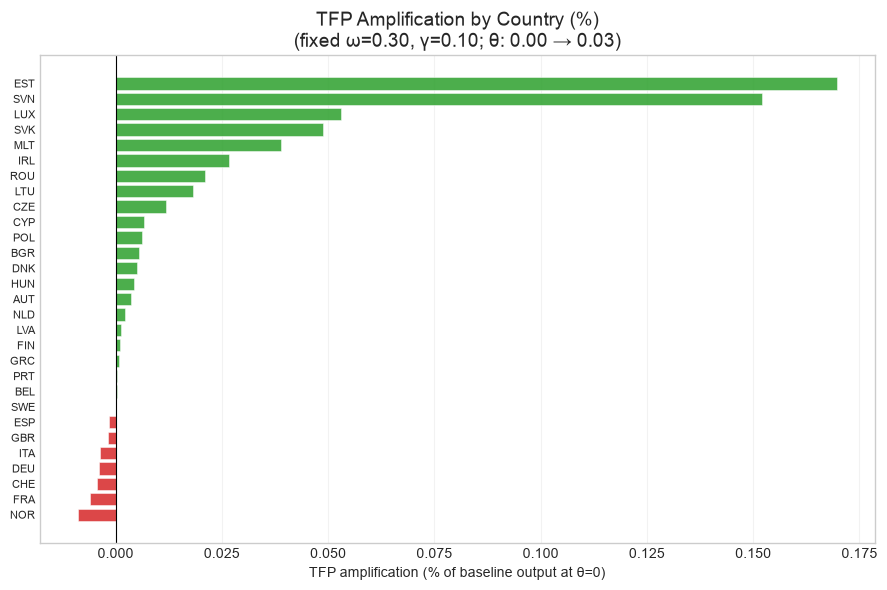

In [58]:
# TFP amplification by country (fixed ω, γ) — shown in percentage
# Definition:
#   TFP amplification_i = Δy_i(θ) - Δy_i(θ=0)
# where Δy_i(θ) = y_i^CMU(θ) - y_i^baseline(θ)
# Plot unit below: % of baseline output at θ=0.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Pick theta=0 and theta=CMU_THETA (or nearest positive if CMU_THETA is 0)
theta0 = thetas[np.argmin(np.abs(thetas - 0.0))]
theta1 = CMU_THETA
if np.isclose(theta1, 0):
    pos_thetas = np.array(sorted([t for t in thetas if t > 0]))
    if len(pos_thetas) == 0:
        raise ValueError("No positive theta values found in grid.")
    theta1 = pos_thetas[np.argmin(np.abs(pos_thetas - 0.03))]

# 2) Hold everything constant except theta (fix ω and γ)
sub_fixed = df_output_country[
    np.isclose(df_output_country["omega"], CMU_OMEGA) &
    np.isclose(df_output_country["gamma"], CMU_GAMMA)
].copy()

if sub_fixed.empty:
    raise ValueError("No rows found for the fixed (ω, γ) values.")

# 3) Helper to build Δy_i robustly
# Prefer dy_abs / dy columns if present; fallback to y_cmu - y_baseline.
def get_delta_y(df, theta_val, out_col):
    sub = df[np.isclose(df["theta"], theta_val)].copy()
    if sub.empty:
        raise ValueError(f"No rows found at theta={theta_val} for fixed (ω, γ).")

    if "dy_abs" in sub.columns:
        sub[out_col] = sub["dy_abs"]
    elif "dy" in sub.columns:
        sub[out_col] = sub["dy"]
    elif {"y_cmu", "y_baseline"}.issubset(sub.columns):
        sub[out_col] = sub["y_cmu"] - sub["y_baseline"]
    else:
        raise KeyError("Need one of {'dy_abs','dy'} or both {'y_cmu','y_baseline'} in df_output_country.")

    if "y_baseline" not in sub.columns:
        raise KeyError("Need 'y_baseline' in df_output_country to express amplification in percentage terms.")

    return sub[["country", out_col, "y_baseline"]]

base = get_delta_y(sub_fixed, theta0, "delta_y_theta0")
t1   = get_delta_y(sub_fixed, theta1, "delta_y_theta1")

cmp = base.merge(t1, on="country", how="inner", suffixes=("_0", "_1"))
cmp["tfp_amplification_abs"] = cmp["delta_y_theta1"] - cmp["delta_y_theta0"]

denom = cmp["y_baseline_0"].replace(0, np.nan)
cmp["tfp_amplification_pct"] = cmp["tfp_amplification_abs"] / denom * 100

cmp = cmp.sort_values("tfp_amplification_pct", ascending=True).reset_index(drop=True)

# 4) Print summary
print("=== TFP amplification (holding ω, γ fixed; varying θ only) ===")
print("Definition: Δy_i(θ) - Δy_i(θ=0), where Δy_i(θ)=y_i^CMU(θ)-y_i^baseline(θ)")
print(f"ω={CMU_OMEGA}, γ={CMU_GAMMA}, θ0={theta0}, θ1={theta1}")
print(f"countries matched: {len(cmp)}")
print(f"Mean amplification (% of y_baseline@θ=0): {cmp['tfp_amplification_pct'].mean():.6f}%")
print(f"Min / Max (%): {cmp['tfp_amplification_pct'].min():.6f} / {cmp['tfp_amplification_pct'].max():.6f}")
print(cmp[["country", "tfp_amplification_pct"]].sort_values("tfp_amplification_pct").head(5).to_string(index=False))
print(cmp[["country", "tfp_amplification_pct"]].sort_values("tfp_amplification_pct", ascending=False).head(5).to_string(index=False))

# 5) Plot amplification by country in percentage
fig, ax = plt.subplots()
y = np.arange(len(cmp))
colors = np.where(cmp["tfp_amplification_pct"] >= 0, "#2ca02c", "#d62728")

ax.barh(y, cmp["tfp_amplification_pct"], color=colors, alpha=0.85, edgecolor="white", linewidth=0.4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(cmp["country"], fontsize=8)
ax.set_xlabel("TFP amplification (% of baseline output at θ=0)")
ax.set_title(
    f"TFP Amplification by Country (%)\n"
    f"(fixed ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}; θ: {theta0:.2f} → {theta1:.2f})"
)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig("imgs/tfp_amplification_percent.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Contour heatmap: EU GDP gain in ω–γ space

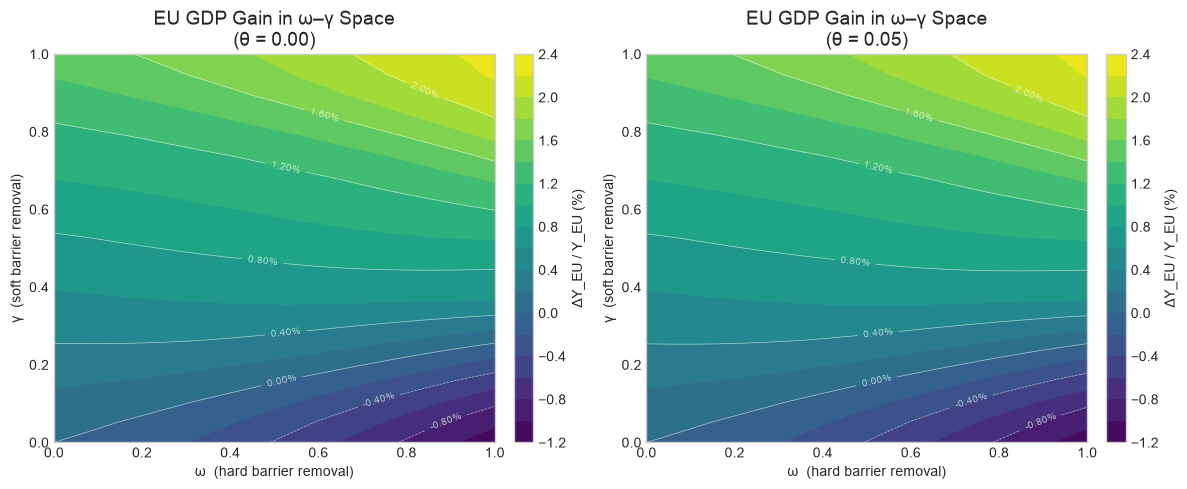

In [59]:
# Filled contour: ΔY_EU/Y_EU (%) in ω–γ space, side-by-side for θ=0 and θ≈0.05
theta_lo = thetas[np.argmin(np.abs(thetas - 0.0))]
theta_hi = thetas[np.argmin(np.abs(thetas - 0.05))]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, theta_val in zip(axes, [theta_lo, theta_hi]):
    sub = df_eu_summary[df_eu_summary['theta'] == theta_val]
    pivot = sub.pivot(index='gamma', columns='omega', values='dY_EU_pct')
    omega_grid = pivot.columns.values
    gamma_grid = pivot.index.values
    Z = pivot.values

    cf = ax.contourf(omega_grid, gamma_grid, Z, levels=20, cmap=CMAP)
    cs = ax.contour(omega_grid, gamma_grid, Z, levels=10,
                    colors='white', linewidths=0.5, alpha=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt='%.2f%%')

    cb = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('ΔY_EU / Y_EU (%)')

    ax.set_xlabel('ω  (hard barrier removal)')
    ax.set_ylabel('γ  (soft barrier removal)')
    ax.set_title(f'EU GDP Gain in ω–γ Space\n(θ = {theta_val:.2f})')

plt.tight_layout()
plt.savefig("imgs/eu_gdp_gain_contour_omega_gamma.png", dpi=150, bbox_inches="tight")
plt.show()


## 7 · Marginal contribution: hard vs soft barrier removal

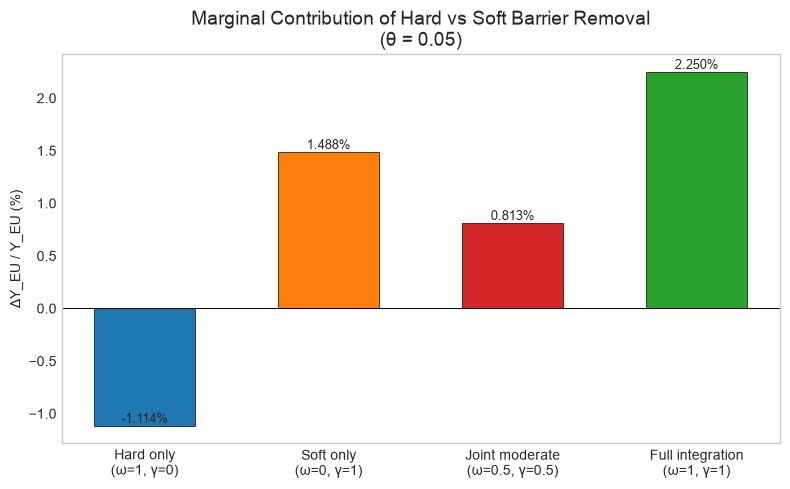

In [60]:
# Four-bar chart: EU GDP gain under four corner scenarios
# Decomposes contribution of hard (ω) vs soft (γ) barrier removal
omega_half = omegas[np.argmin(np.abs(omegas - 0.5))]
omega_full = omegas[np.argmin(np.abs(omegas - 1.0))]
gamma_half = gammas[np.argmin(np.abs(gammas - 0.5))]
gamma_full = gammas[np.argmin(np.abs(gammas - 1.0))]
theta_mid  = thetas[np.argmin(np.abs(thetas - 0.05))]

scenarios = [
    (omega_full, 0.0,         'Hard only\n(ω=1, γ=0)'),
    (0.0,         gamma_full, 'Soft only\n(ω=0, γ=1)'),
    (omega_half,  gamma_half, 'Joint moderate\n(ω=0.5, γ=0.5)'),
    (omega_full,  gamma_full, 'Full integration\n(ω=1, γ=1)'),
]

gains = []
for omega_s, gamma_s, label in scenarios:
    o = omegas[np.argmin(np.abs(omegas - omega_s))]
    g = gammas[np.argmin(np.abs(gammas - gamma_s))]
    row = df_eu_summary[
        (df_eu_summary['omega'] == o) &
        (df_eu_summary['gamma'] == g) &
        (df_eu_summary['theta'] == theta_mid)
    ]
    gains.append(row['dY_EU_pct'].values[0] if len(row) else np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['C0', 'C1', 'C3', 'C2']
bars = ax.bar([s[2] for s in scenarios], gains, color=colors, width=0.55,
              edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, gains):
    if np.isfinite(val):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
                f'{val:.3f}%', ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='black', linewidth=0.7)
ax.set_ylabel('ΔY_EU / Y_EU (%)')
ax.set_title(f'Marginal Contribution of Hard vs Soft Barrier Removal\n(θ = {theta_mid:.2f})')
plt.tight_layout()
plt.savefig("imgs/marginal_contribution_hard_vs_soft.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Bilateral flow change matrix (Δa_ij heatmap)

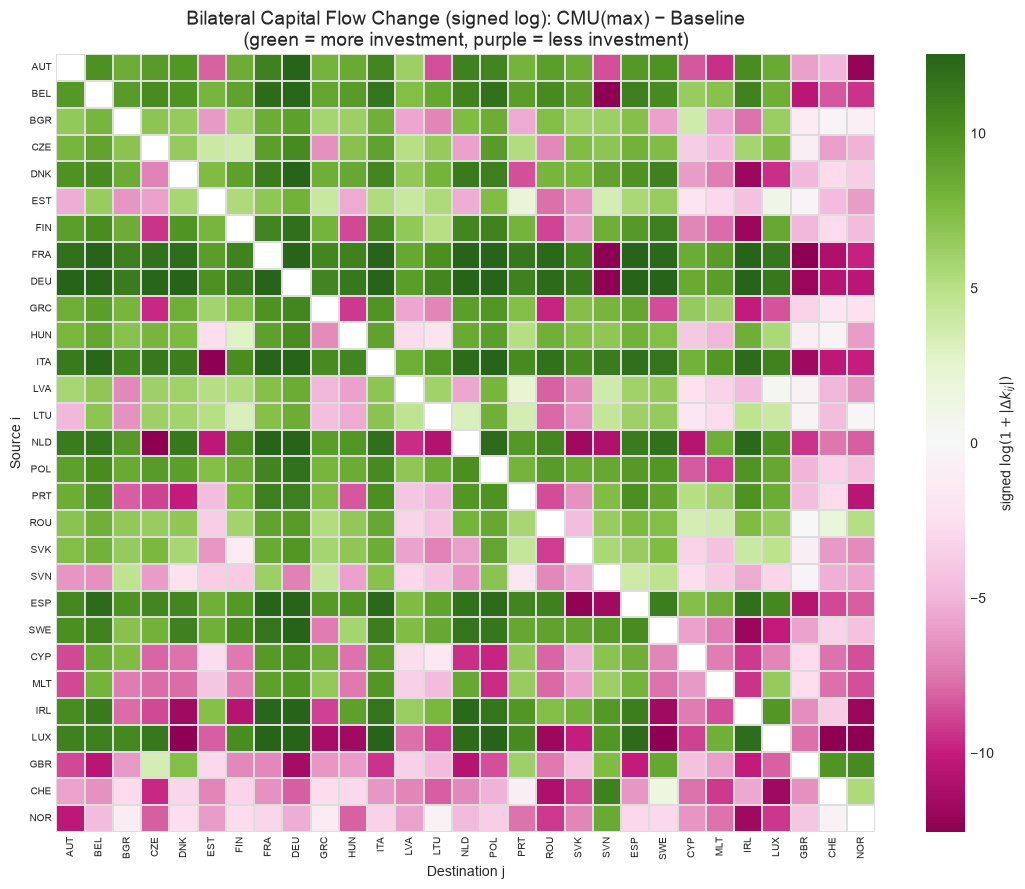

In [61]:
# Bilateral flow change matrix: Δk_ij = k_ij(CMU) - k_ij(baseline)
# Uses Portfolio_Flows sheet; compare 'max' scenario vs 'baseline'
df_flows = pd.read_excel(xls, 'Portfolio_Flows')

base_pivot = (
    df_flows[df_flows['scenario'] == 'baseline']
    .pivot(index='iso3_i', columns='iso3_j', values='k_flow')
    .reindex(index=COUNTRIES, columns=COUNTRIES)
)
cmu_pivot = (
    df_flows[df_flows['scenario'] == 'max']
    .pivot(index='iso3_i', columns='iso3_j', values='k_flow')
    .reindex(index=COUNTRIES, columns=COUNTRIES)
)

delta_matrix = cmu_pivot - base_pivot

# Set diagonal to NaN (domestic — shown elsewhere)
np.fill_diagonal(delta_matrix.values, np.nan)

# Signed log transform: sign(x) * log1p(|x|)
# (handles negatives and zeros safely)
delta_log = np.sign(delta_matrix) * np.log1p(np.abs(delta_matrix))

vlim = np.nanpercentile(np.abs(delta_log.values), 95)
norm_bi = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    delta_log,
    ax=ax,
    cmap='PiYG',
    norm=norm_bi,
    linewidths=0.3,
    linecolor='#dddddd',
    cbar_kws={'label': r'signed $\log(1+|\Delta k_{ij}|)$'},
    xticklabels=True,
    yticklabels=True,
)

ax.set_xlabel('Destination j')
ax.set_ylabel('Source i')
ax.set_title('Bilateral Capital Flow Change (signed log): CMU(max) − Baseline\n'
             '(green = more investment, purple = less investment)')
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.savefig("imgs/bilateral_flow_change_matrix_log.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 · Portfolio composition stacked bars: domestic / EU / non-EU

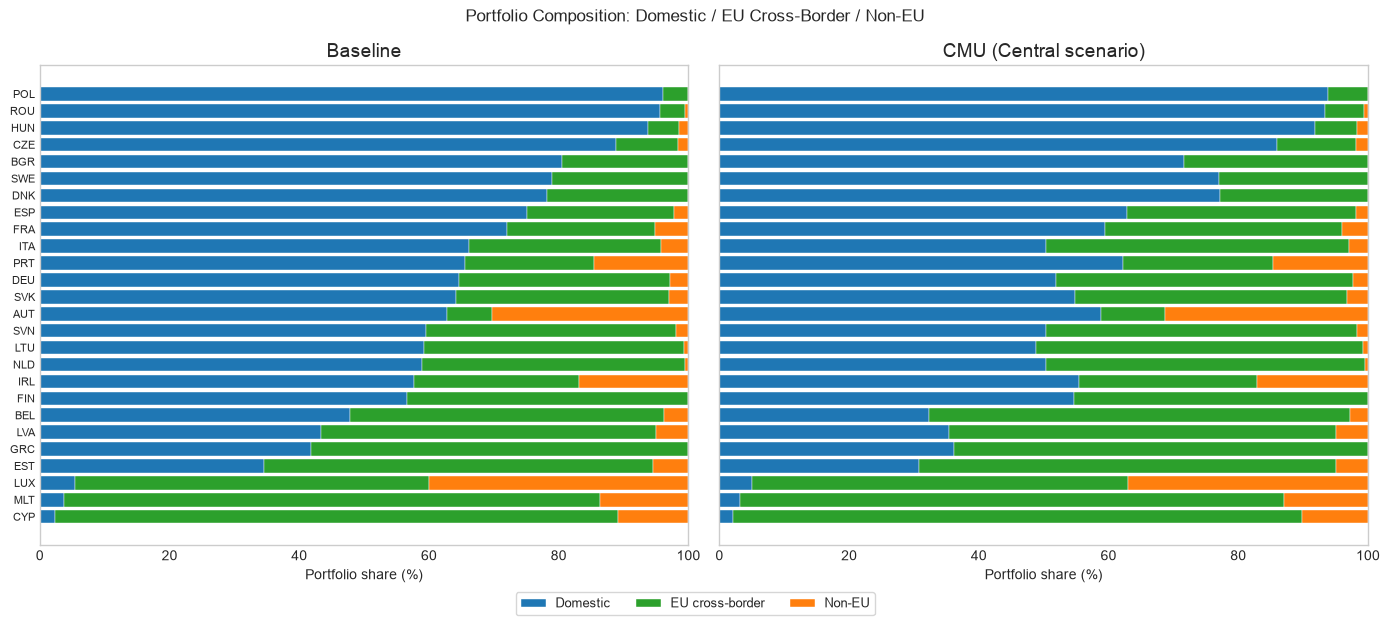

In [62]:
# Portfolio composition: share going to domestic / EU cross-border / non-EU
# Compare baseline vs central scenario CMU for each EU27 country
# EU vs non-EU is defined from EU27 and COUNTRIES (non-EU = COUNTRIES \ EU27)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EU_SET = set(EU27)
COUNTRY_SET = set(COUNTRIES)
NON_EU_SET = COUNTRY_SET - EU_SET

# Use bilateral flows directly to recover destination composition
if "df_flows" not in globals():
    raise KeyError("df_flows not found. Please load the Portfolio_Flows sheet first.")

required_cols = {"scenario", "iso3_i", "iso3_j", "k_flow"}
if not required_cols.issubset(df_flows.columns):
    raise KeyError(f"df_flows is missing required columns: {sorted(required_cols - set(df_flows.columns))}")

def compute_composition(flows_df, scenario, eu_countries, non_eu_countries):
    """Return DataFrame with columns: country, domestic, eu_xborder, non_eu (shares in %)."""
    sub = flows_df[flows_df["scenario"] == scenario].copy()

    # Keep only destinations in model country set
    valid_dest = set(eu_countries) | set(non_eu_countries)
    sub = sub[sub["iso3_j"].isin(valid_dest)]

    rows = []
    for country in eu_countries:
        row_i = sub[sub["iso3_i"] == country]
        total = row_i["k_flow"].sum()

        if total == 0:
            rows.append({"country": country, "domestic": np.nan, "eu_xborder": np.nan, "non_eu": np.nan})
            continue

        domestic = row_i[row_i["iso3_j"] == country]["k_flow"].sum()
        eu_xborder = row_i[(row_i["iso3_j"] != country) & (row_i["iso3_j"].isin(eu_countries))]["k_flow"].sum()
        non_eu = row_i[row_i["iso3_j"].isin(non_eu_countries)]["k_flow"].sum()

        rows.append({
            "country": country,
            "domestic": domestic / total * 100,
            "eu_xborder": eu_xborder / total * 100,
            "non_eu": non_eu / total * 100,
        })

    return pd.DataFrame(rows)

comp_base = compute_composition(df_flows, "baseline", EU27, NON_EU_SET)
comp_cmu = compute_composition(df_flows, "most_probable", EU27, NON_EU_SET)

# Sort by baseline domestic share ascending
order = comp_base.sort_values("domestic", ascending=True)["country"].tolist()
comp_base = comp_base.set_index("country").reindex(order)
comp_cmu = comp_cmu.set_index("country").reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
colors_comp = {"domestic": "C0", "eu_xborder": "C2", "non_eu": "C1"}
labels_comp = {"domestic": "Domestic", "eu_xborder": "EU cross-border", "non_eu": "Non-EU"}

handles, legend_labels = [], []
for ax, df_comp, title in zip(axes, [comp_base, comp_cmu], ["Baseline", "CMU (Central scenario)"]):
    y = np.arange(len(df_comp))
    left = np.zeros(len(df_comp))

    for key in ["domestic", "eu_xborder", "non_eu"]:
        vals = df_comp[key].fillna(0).values
        bar = ax.barh(
            y, vals, left=left, color=colors_comp[key],
            label=labels_comp[key], edgecolor="white", linewidth=0.3
        )
        if ax is axes[0]:
            handles.append(bar)
            legend_labels.append(labels_comp[key])
        left += vals

    ax.set_yticks(y)
    ax.set_yticklabels(df_comp.index, fontsize=8)
    ax.set_xlabel("Portfolio share (%)")
    ax.set_title(title)
    ax.set_xlim(0, 100)

fig.legend(handles, legend_labels, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=True)
fig.suptitle("Portfolio Composition: Domestic / EU Cross-Border / Non-EU")
plt.tight_layout()
plt.savefig("imgs/portfolio_composition_domestic_eu_noneu.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 · Winners / losers bar chart

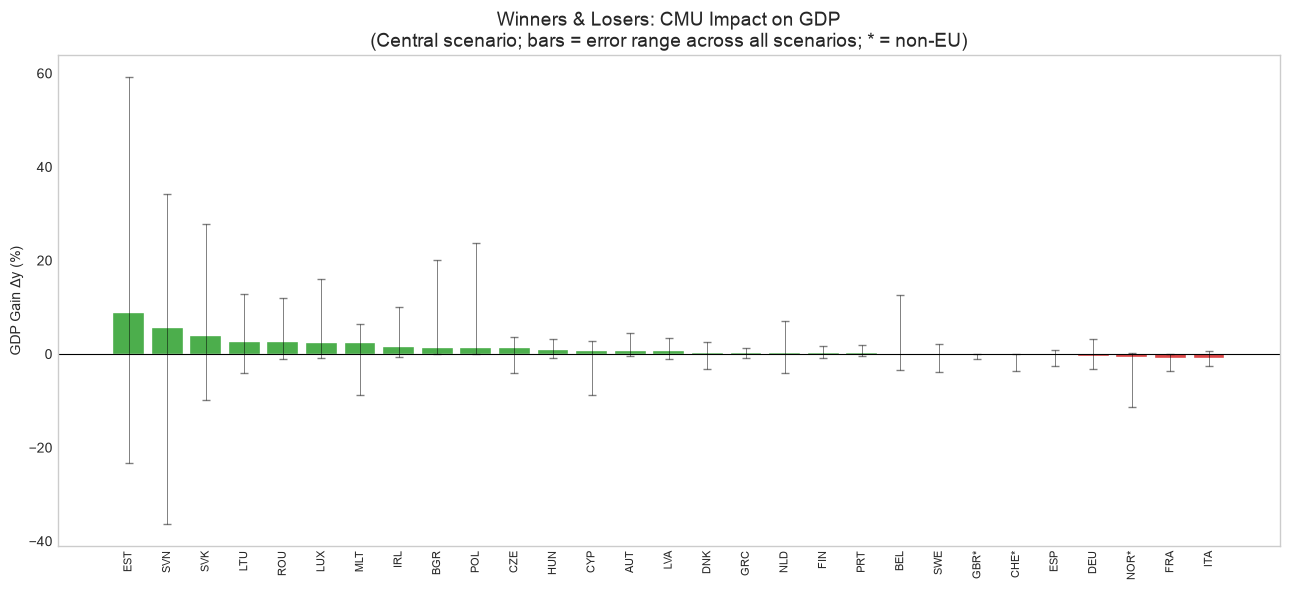

In [63]:
# Vertical bar chart of GDP gain (%) per country — central scenario CMU
# Green = winner, red = loser, with error bars showing full (min,max) range

# Central scenario
df_win = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA)
][['country', 'dy_pct', 'in_EU27']].copy()

# Full range across all scenarios per country
df_range = (
    df_output_country
    .groupby('country')['dy_pct']
    .agg(['min', 'max'])
    .reset_index()
)
df_win = df_win.merge(df_range, on='country')
df_win = df_win.sort_values('dy_pct', ascending=False).reset_index(drop=True)

# Label non-EU with *
df_win['label'] = [f"{row['country']}{'*' if row['in_EU27'] == 0 else ''}" for _, row in df_win.iterrows()]

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df_win))

colors_win = ['#d62728' if v < 0 else '#2ca02c' for v in df_win['dy_pct']]
ax.bar(x, df_win['dy_pct'], color=colors_win, edgecolor='white', linewidth=0.3, alpha=0.85)

# Error bars: range across all ω, γ, θ scenarios
yerr_lo = df_win['dy_pct'] - df_win['min']
yerr_hi = df_win['max'] - df_win['dy_pct']
ax.errorbar(
    x, df_win['dy_pct'],
    yerr=[yerr_lo, yerr_hi],
    fmt='none', color='black', linewidth=0.7, capsize=3, alpha=0.5
)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_win['label'], rotation=90, fontsize=8)
ax.set_ylabel('GDP Gain Δy (%)')
ax.set_title(
    f'Winners & Losers: CMU Impact on GDP\n'
    f'(Central scenario; bars = error range across all scenarios; * = non-EU)'
)
plt.tight_layout()
plt.savefig("imgs/winners_losers_gdp_gain.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 · Distribution of country-level GDP gains across all scenarios

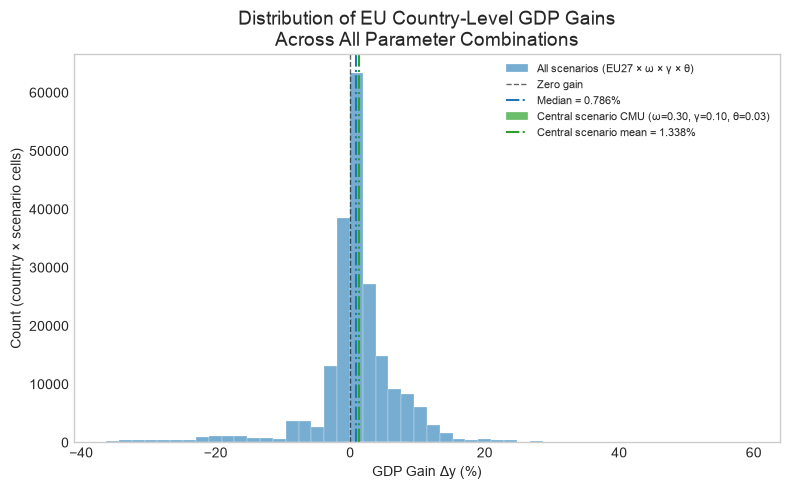

Share of (country, scenario) cells with positive GDP gain: 65.0%


In [64]:
# Histogram of dy_pct across all EU27 countries × all (ω, γ, θ) scenarios
# Annotated with the central scenario scenario mean

all_gains = df_output_country_EU['dy_pct'].dropna().values
prob_gains = df_output_country_EU[
    (df_output_country_EU['theta'] == CMU_THETA) &
    (df_output_country_EU['omega'] == CMU_OMEGA) &
    (df_output_country_EU['gamma'] == CMU_GAMMA)
]['dy_pct'].dropna().values

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_gains, bins=50, color='C0', alpha=0.6, edgecolor='white',
        linewidth=0.3, label='All scenarios (EU27 × ω × γ × θ)')
ax.axvline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6, label='Zero gain')
ax.axvline(np.median(all_gains), color='C0', linewidth=1.5, linestyle='-.',
           label=f'Median = {np.median(all_gains):.3f}%')

# Overlay central scenario scenario as rug / density
ax.hist(prob_gains, bins=20, color='C2', alpha=0.7, edgecolor='white',
        linewidth=0.3, label=f'Central scenario CMU (ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
ax.axvline(np.mean(prob_gains), color='C2', linewidth=1.5, linestyle='-.',
           label=f'Central scenario mean = {np.mean(prob_gains):.3f}%')

ax.set_xlabel('GDP Gain Δy (%)')
ax.set_ylabel('Count (country × scenario cells)')
ax.set_title('Distribution of EU Country-Level GDP Gains\nAcross All Parameter Combinations')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("imgs/distribution_eu_gdp_gains.png", dpi=150, bbox_inches="tight")
plt.show()

pct_pos = (all_gains > 0).mean() * 100
print(f"Share of (country, scenario) cells with positive GDP gain: {pct_pos:.1f}%")


## 1–2 · MPK convergence: σ(MPK) vs ω and before/after bar chart

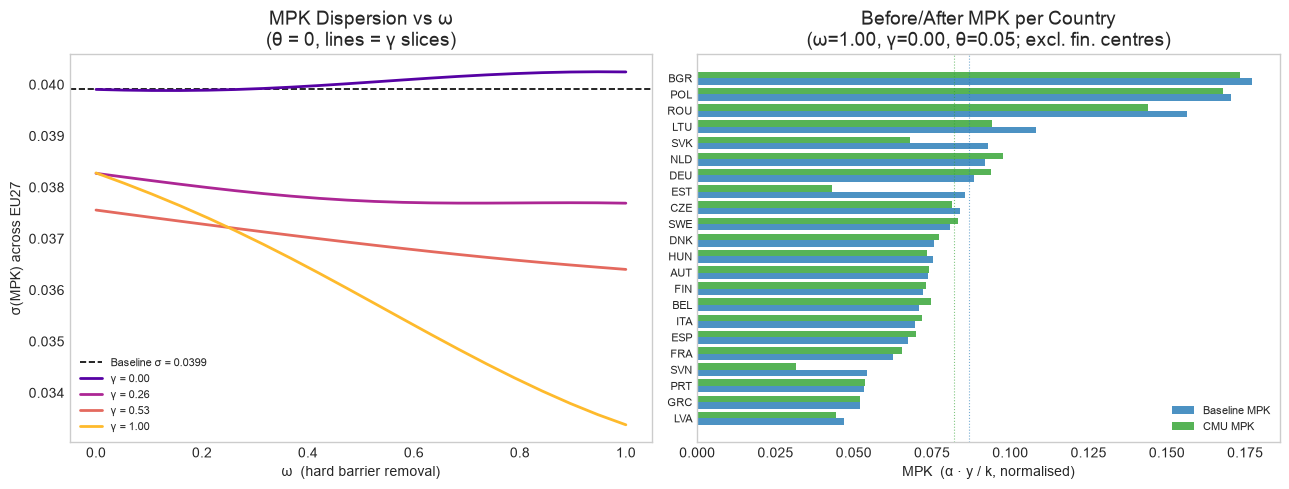

In [65]:
# MPK convergence: σ(MPK) vs ω, one line per γ slice
# Uses EU_Summary sigma_mpk_cmu / sigma_mpk_baseline columns
# θ=0 so that TFP doesn't confound the MPK convergence story

theta_zero = thetas[np.argmin(np.abs(thetas - 0.0))]
df_sigma = df_eu_summary[df_eu_summary['theta'] == theta_zero].copy()

gamma_slices = sorted(df_sigma['gamma'].unique())
# Pick a manageable subset to avoid overplotting
gamma_pick = [gamma_slices[0],
              gamma_slices[len(gamma_slices) // 4],
              gamma_slices[len(gamma_slices) // 2],
              gamma_slices[-1]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: σ(MPK) as function of ω ────────────────────────────
ax = axes[0]
cmap_g = plt.cm.plasma(np.linspace(0.15, 0.85, len(gamma_pick)))
sigma_base_val = df_sigma[df_sigma['omega'] == omegas[0]]['sigma_mpk_baseline'].mean()
ax.axhline(sigma_base_val, color='black', linewidth=1.2, linestyle='--',
           label=f'Baseline σ = {sigma_base_val:.4f}')
for color, gval in zip(cmap_g, gamma_pick):
    sub = df_sigma[df_sigma['gamma'] == gval].sort_values('omega')
    ax.plot(sub['omega'], sub['sigma_mpk_cmu'], linewidth=2, color=color,
            label=f'γ = {gval:.2f}')
ax.set_xlabel('ω  (hard barrier removal)')
ax.set_ylabel('σ(MPK) across EU27')
ax.set_title('MPK Dispersion vs ω\n(θ = 0, lines = γ slices)')
ax.legend(fontsize=8)

# ── Right: before/after MPK bar chart — full vs no integration ─
ax = axes[1]
theta_hi2 = thetas[np.argmin(np.abs(thetas - 0.05))]
omega_full2 = omegas[np.argmin(np.abs(omegas - 1.0))]
gamma_zero2 = gammas[np.argmin(np.abs(gammas - 0.0))]

df_mpk_ctry = df_output_country_EU[
    (df_output_country_EU['theta'] == theta_hi2) &
    (df_output_country_EU['omega'] == omega_full2) &
    (df_output_country_EU['gamma'] == gamma_zero2)
][['country', 'mpk_baseline', 'mpk_cmu']].copy()
df_mpk_ctry = df_mpk_ctry[~df_mpk_ctry['country'].isin(['IRL','LUX','CYP','MLT'])]
df_mpk_ctry = df_mpk_ctry.sort_values('mpk_baseline', ascending=True).reset_index(drop=True)

y2 = np.arange(len(df_mpk_ctry))
ax.barh(y2 - 0.2, df_mpk_ctry['mpk_baseline'], height=0.4,
        color='C0', alpha=0.8, label='Baseline MPK')
ax.barh(y2 + 0.2, df_mpk_ctry['mpk_cmu'], height=0.4,
        color='C2', alpha=0.8, label='CMU MPK')
ax.set_yticks(y2)
ax.set_yticklabels(df_mpk_ctry['country'], fontsize=8)
ax.set_xlabel('MPK  (α · y / k, normalised)')
ax.set_title(f'Before/After MPK per Country\n(ω={omega_full2:.2f}, γ={gamma_zero2:.2f}, θ={theta_hi2:.2f}; excl. fin. centres)')
ax.axvline(df_mpk_ctry['mpk_baseline'].mean(), color='C0', linewidth=0.8, linestyle=':', alpha=0.6)
ax.axvline(df_mpk_ctry['mpk_cmu'].mean(), color='C2', linewidth=0.8, linestyle=':', alpha=0.6)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("imgs/mpk_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


## 12 · Robustness: η sensitivity fan — EU GDP gain vs ω

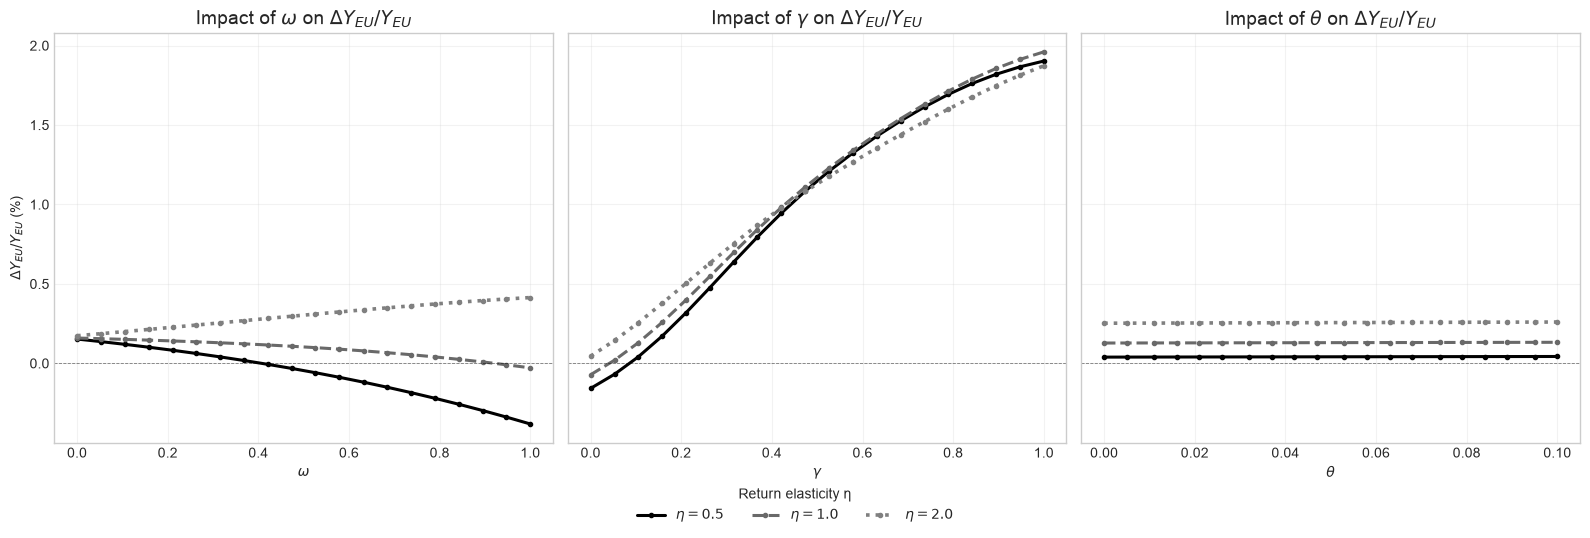

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rob = df_robustness.copy()
rob.columns = rob.columns.str.strip()

# Robust y-column detection
if 'ΔY_EU/Y_EU (%)' in rob.columns:
    y_col = 'ΔY_EU/Y_EU (%)'
elif 'dY_EU_pct' in rob.columns:
    y_col = 'dY_EU_pct'
else:
    raise KeyError("Could not find EU GDP gain column in df_robustness.")

required = {'omega', 'gamma', 'theta', 'eta', y_col}
missing = required - set(rob.columns)
if missing:
    raise KeyError(f"Missing required columns in df_robustness: {missing}")

eta_vals = sorted(rob['eta'].dropna().unique())
if len(eta_vals) != 3:
    raise ValueError(f"Expected exactly 3 eta values, found {len(eta_vals)}: {eta_vals}")

# Three black shades + three linestyles
style_map = {
    eta_vals[0]: {"color": "black",    "linestyle": "-",  "linewidth": 2.2},
    eta_vals[1]: {"color": "dimgray",  "linestyle": "--", "linewidth": 2.2},
    eta_vals[2]: {"color": "gray",     "linestyle": ":",  "linewidth": 2.6},
}

configs = [
    {'param': 'omega', 'fixed': {'gamma': CMU_GAMMA, 'theta': CMU_THETA}, 'symbol': r'$\omega$'},
    {'param': 'gamma', 'fixed': {'omega': CMU_OMEGA, 'theta': CMU_THETA}, 'symbol': r'$\gamma$'},
    {'param': 'theta', 'fixed': {'omega': CMU_OMEGA, 'gamma': CMU_GAMMA}, 'symbol': r'$\theta$'},
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, cfg in zip(axes, configs):
    p = cfg['param']
    s = cfg['symbol']

    for eta in eta_vals:
        st = style_map[eta]
        sub_eta = rob[np.isclose(rob['eta'], eta)].copy()

        # Central scenario path: vary p, keep other two at CMU values
        line = sub_eta.copy()
        for k, v in cfg['fixed'].items():
            line = line[np.isclose(line[k], v)]

        line = (
            line.groupby(p)[y_col]
            .mean()
            .reset_index()
            .sort_values(p)
        )

        ax.plot(
            line[p], line[y_col],
            color=st["color"],
            linestyle=st["linestyle"],
            linewidth=st["linewidth"],
            marker='o',
            markersize=3,
            label=fr'$\eta={eta}$'
        )

    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.set_xlabel(s)
    ax.set_title(rf'Impact of {s} on $\Delta Y_{{EU}}/Y_{{EU}}$')
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r'$\Delta Y_{EU}/Y_{EU}$ (%)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False,
    title='Return elasticity η'
)

plt.tight_layout()
plt.savefig("imgs/robustness_1d_eta_lines_black.png", dpi=150, bbox_inches="tight")
plt.show()

## 13 · Robustness heatmap: η × θ at full integration (ω=1, γ=0)

In [67]:
# # Robustness heatmap: EU GDP gain for all combinations of η × θ
# # Fixed: ω = 1.0 (max hard integration), γ = 0.0
# # Shows how sensitive the result is to the two key structural assumptions

# omega_max = rob['omega'].max()
# gamma_min = rob['gamma'].min()

# rob_hm = rob[
#     (np.abs(rob['omega'] - omega_max) < 1e-6) &
#     (np.abs(rob['gamma'] - gamma_min) < 1e-6)
# ].copy()

# pivot_rob = rob_hm.pivot_table(index='eta', columns='theta', values=dY_col)

# n_cols = pivot_rob.shape[1]
# n_rows = pivot_rob.shape[0]
# fig, ax = plt.subplots(figsize=(max(9, n_cols * 1.2), max(4, n_rows * 0.9)))
# sns.heatmap(
#     pivot_rob,
#     ax=ax,
#     cmap=CMAP,
#     annot=True,
#     fmt='.3f',
#     annot_kws={'size': 8},
#     linewidths=0.4,
#     cbar_kws={'label': 'ΔY_EU / Y_EU (%)'},
# )
# ax.set_xlabel('θ  (TFP spillover elasticity)')
# ax.set_ylabel('η  (return elasticity)')
# ax.set_title(f'Robustness: EU GDP Gain (%) for η × θ\n'
#              f'(ω = {omega_max:.2f}, γ = {gamma_min:.2f}  — full hard integration)')
# plt.tight_layout()
# plt.savefig("imgs/robustness_heatmap_eta_theta.png", dpi=150, bbox_inches="tight")
# plt.show()


## 14 · Tornado chart: parameter uncertainty contribution

In [68]:
# # Tornado chart: how much of the range in EU GDP gain comes from each parameter?
# # Method: vary one parameter at a time while holding others at their midpoint.
# # Midpoints: ω=0.5, γ=0.5, θ=0.05, η=1.0

# mid_omega = omegas[np.argmin(np.abs(omegas - 0.5))]
# mid_gamma = gammas[np.argmin(np.abs(gammas - 0.5))]
# mid_theta = thetas[np.argmin(np.abs(thetas - 0.05))]
# mid_eta   = 1.0

# # ── ω range (γ=mid, θ=mid) ──────────────────────────────────
# sub_omega = df_eu_summary[
#     (df_eu_summary['gamma'] == mid_gamma) &
#     (df_eu_summary['theta'] == mid_theta)
# ]
# omega_min_gain = sub_omega['dY_EU_pct'].min()
# omega_max_gain = sub_omega['dY_EU_pct'].max()

# # ── γ range (ω=mid, θ=mid) ──────────────────────────────────
# sub_gamma = df_eu_summary[
#     (df_eu_summary['omega'] == mid_omega) &
#     (df_eu_summary['theta'] == mid_theta)
# ]
# gamma_min_gain = sub_gamma['dY_EU_pct'].min()
# gamma_max_gain = sub_gamma['dY_EU_pct'].max()

# # ── θ range (ω=mid, γ=mid) ──────────────────────────────────
# sub_theta = df_eu_summary[
#     (df_eu_summary['omega'] == mid_omega) &
#     (df_eu_summary['gamma'] == mid_gamma)
# ]
# theta_min_gain = sub_theta['dY_EU_pct'].min()
# theta_max_gain = sub_theta['dY_EU_pct'].max()

# # ── η range (ω=1, γ=0, θ=mid) ───────────────────────────────
# rob_eta = rob[
#     (np.abs(rob['omega'] - omega_max) < 1e-6) &
#     (np.abs(rob['gamma'] - gamma_min) < 1e-6) &
#     (np.abs(rob['theta'] - mid_theta) < 1e-6)
# ]
# eta_min_gain = rob_eta[dY_col].min() if len(rob_eta) else np.nan
# eta_max_gain = rob_eta[dY_col].max() if len(rob_eta) else np.nan

# tornado_data = pd.DataFrame([
#     {'param': 'ω  (hard barriers)', 'lo': omega_min_gain, 'hi': omega_max_gain},
#     {'param': 'γ  (soft barriers)', 'lo': gamma_min_gain, 'hi': gamma_max_gain},
#     {'param': 'θ  (TFP spillover)', 'lo': theta_min_gain, 'hi': theta_max_gain},
#     {'param': 'η  (return elasticity)', 'lo': eta_min_gain, 'hi': eta_max_gain},
# ])
# tornado_data['range'] = tornado_data['hi'] - tornado_data['lo']
# tornado_data = tornado_data.sort_values('range', ascending=True)

# base_val = df_eu_summary[
#     (df_eu_summary['omega'] == mid_omega) &
#     (df_eu_summary['gamma'] == mid_gamma) &
#     (df_eu_summary['theta'] == mid_theta)
# ]['dY_EU_pct'].values[0]

# fig, ax = plt.subplots(figsize=(8, 4.5))
# y = np.arange(len(tornado_data))

# for i, (_, row) in enumerate(tornado_data.iterrows()):
#     lo, hi = row['lo'] - base_val, row['hi'] - base_val
#     ax.barh(i, lo, left=base_val, color='#d62728', alpha=0.75,
#             edgecolor='white', linewidth=0.3)
#     ax.barh(i, hi - lo, left=base_val + lo, color='#2ca02c', alpha=0.75,
#             edgecolor='white', linewidth=0.3)
#     # Place labels just inside the bar ends to avoid clipping
#     ax.text(row['lo'] + 0.001, i, f'{row["lo"]:.3f}%', va='center', ha='left',  fontsize=8, color='white', fontweight='bold')
#     ax.text(row['hi'] - 0.001, i, f'{row["hi"]:.3f}%', va='center', ha='right', fontsize=8, color='white', fontweight='bold')

# ax.axvline(base_val, color='black', linewidth=1.2, linestyle='--', label=f'Mid-point = {base_val:.3f}%')
# ax.set_yticks(y)
# ax.set_yticklabels(tornado_data['param'], fontsize=9)
# ax.set_xlabel('ΔY_EU / Y_EU (%)')
# ax.set_title('Tornado Chart: Parameter Uncertainty in EU GDP Gain\n(one-at-a-time variation; others held at midpoint)')
# ax.legend(fontsize=8)
# ax.margins(x=0.01)
# plt.tight_layout()
# plt.savefig("imgs/tornado_parameter_uncertainty.png", dpi=150, bbox_inches="tight")
# plt.show()

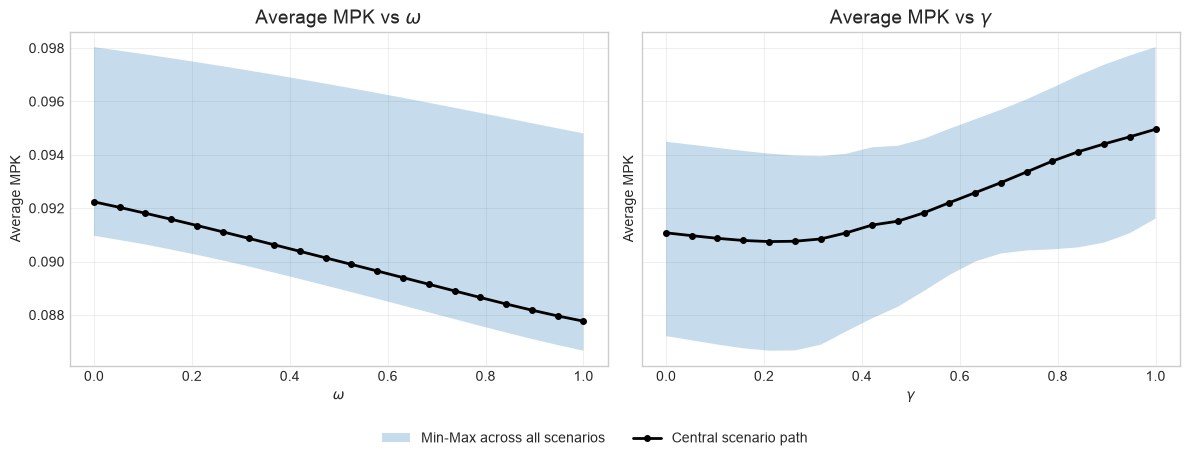

SUMMARY STATS: Average MPK central-scenario paths

Path over $\omega$ (fixed $\gamma,\theta$):
  mean(y):    0.090005
  median(y):  0.090015
  std(y):     0.001424
  min(y):     0.087766
  max(y):     0.092239
  corr(x,y): -0.999854

Path over $\gamma$ (fixed $\omega,\theta$):
  mean(y):    0.092243
  median(y):  0.091668
  std(y):     0.001484
  min(y):     0.090749
  max(y):     0.094957
  corr(x,y):  0.943207


In [69]:
# Average MPK vs ω and γ (simple summary plots)
# Metric: cross-country mean of MPK under CMU

avg_mpk_df = (
    df_output_country_EU
    .groupby(['omega', 'gamma', 'theta'])['mpk_cmu']
    .mean()
    .reset_index(name='mean_mpk')
)

# --- ω plot: summarize over (γ, θ), and overlay the central scenario CMU path ---
omega_band = (
    avg_mpk_df
    .groupby('omega')['mean_mpk']
    .agg(['min', 'max'])
    .reset_index()
    .sort_values('omega')
)

omega_prob = (
    avg_mpk_df[
        (avg_mpk_df['gamma'] == CMU_GAMMA) &
        (avg_mpk_df['theta'] == CMU_THETA)
    ]
    .sort_values('omega')
)

# --- γ plot: summarize over (ω, θ), and overlay the central scenario CMU path ---
gamma_band = (
    avg_mpk_df
    .groupby('gamma')['mean_mpk']
    .agg(['min', 'max'])
    .reset_index()
    .sort_values('gamma')
)

gamma_prob = (
    avg_mpk_df[
        (avg_mpk_df['omega'] == CMU_OMEGA) &
        (avg_mpk_df['theta'] == CMU_THETA)
    ]
    .sort_values('gamma')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# Left: mean MPK vs ω
ax = axes[0]
ax.fill_between(omega_band['omega'], omega_band['min'], omega_band['max'], alpha=0.25, label='Min-Max across all scenarios')
ax.plot(
    omega_prob['omega'], omega_prob['mean_mpk'],
    color='black', linewidth=2, marker='o', markersize=4, label='Central scenario path'
)
ax.set_xlabel(r'$\omega$')
ax.set_ylabel('Average MPK')
ax.set_title(r'Average MPK vs $\omega$')
ax.grid(alpha=0.3)

# Right: mean MPK vs γ
ax = axes[1]
ax.fill_between(gamma_band['gamma'], gamma_band['min'], gamma_band['max'], alpha=0.25, label='Min-Max across all scenarios')
ax.plot(
    gamma_prob['gamma'], gamma_prob['mean_mpk'],
    color='black', linewidth=2, marker='o', markersize=4, label='Central scenario path'
)
ax.set_xlabel(r'$\gamma$')
ax.set_ylabel('Average MPK')
ax.set_title(r'Average MPK vs $\gamma$')
ax.grid(alpha=0.3)

# Shared legend centered below both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.03), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('imgs/avg_mpk_vs_omega_gamma.png', dpi=150, bbox_inches='tight')
plt.show()

# print mean, median, std, min, max, correlation with x
print("=" * 80)
print("SUMMARY STATS: Average MPK central-scenario paths")
print("=" * 80)

for label, df_path, x_col in [
    (r"Path over $\omega$ (fixed $\gamma,\theta$)", omega_prob[["omega", "mean_mpk"]].copy(), "omega"),
    (r"Path over $\gamma$ (fixed $\omega,\theta$)", gamma_prob[["gamma", "mean_mpk"]].copy(), "gamma"),
]:
    d = df_path.dropna()
    corr = d[x_col].corr(d["mean_mpk"]) if d[x_col].nunique() > 1 else np.nan

    print(f"\n{label}:")
    print(f"  mean(y):   {d['mean_mpk'].mean(): .6f}")
    print(f"  median(y): {d['mean_mpk'].median(): .6f}")
    print(f"  std(y):    {d['mean_mpk'].std(): .6f}")
    print(f"  min(y):    {d['mean_mpk'].min(): .6f}")
    print(f"  max(y):    {d['mean_mpk'].max(): .6f}")
    print(f"  corr(x,y): {corr: .6f}")

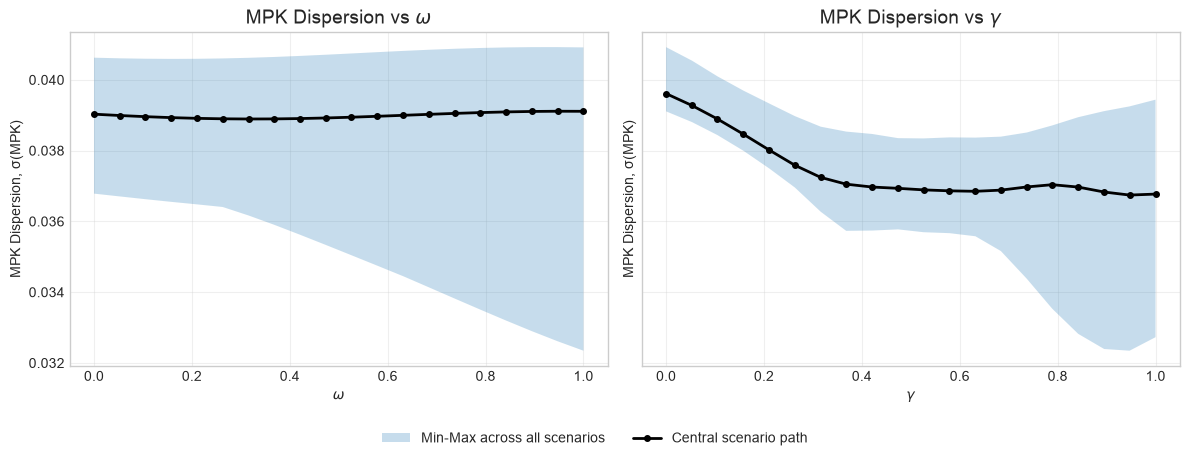

SUMMARY STATS: MPK Dispersion σ(MPK) central-scenario paths

Path over $\omega$ (fixed $\gamma,\theta$):
  mean(σ):    0.038990
  median(σ):  0.038980
  std(σ):     0.000079
  min(σ):     0.038893
  max(σ):     0.039112
  corr(x,σ):  0.715097

Path over $\gamma$ (fixed $\omega,\theta$):
  mean(σ):    0.037442
  median(σ):  0.036971
  std(σ):     0.000902
  min(σ):     0.036743
  max(σ):     0.039610
  corr(x,σ): -0.826248


In [70]:
# MPK dispersion (std) vs ω and γ (simple summary plots)
# Metric: cross-country std of MPK under CMU

std_mpk_df = (
    df_output_country_EU
    .groupby(['omega', 'gamma', 'theta'])['mpk_cmu']
    .std(ddof=0)
    .reset_index(name='std_mpk')
)

# --- ω plot: summarize over (γ, θ), and overlay the central scenario CMU path ---
omega_band_std = (
    std_mpk_df
    .groupby('omega')['std_mpk']
    .agg(['min', 'max'])
    .reset_index()
    .sort_values('omega')
)

omega_prob_std = (
    std_mpk_df[
        (std_mpk_df['gamma'] == CMU_GAMMA) &
        (std_mpk_df['theta'] == CMU_THETA)
    ]
    .sort_values('omega')
)

# --- γ plot: summarize over (ω, θ), and overlay the central scenario CMU path ---
gamma_band_std = (
    std_mpk_df
    .groupby('gamma')['std_mpk']
    .agg(['min', 'max'])
    .reset_index()
    .sort_values('gamma')
)

gamma_prob_std = (
    std_mpk_df[
        (std_mpk_df['omega'] == CMU_OMEGA) &
        (std_mpk_df['theta'] == CMU_THETA)
    ]
    .sort_values('gamma')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# Left: std MPK vs ω
ax = axes[0]
ax.fill_between(omega_band_std['omega'], omega_band_std['min'], omega_band_std['max'], alpha=0.25, label='Min-Max across all scenarios')
ax.plot(
    omega_prob_std['omega'], omega_prob_std['std_mpk'],
    color='black', linewidth=2, marker='o', markersize=4, label='Central scenario path'
)
ax.set_xlabel(r'$\omega$')
ax.set_ylabel('MPK Dispersion, σ(MPK)')
ax.set_title(r'MPK Dispersion vs $\omega$')
ax.grid(alpha=0.3)

# Right: std MPK vs γ
ax = axes[1]
ax.fill_between(gamma_band_std['gamma'], gamma_band_std['min'], gamma_band_std['max'], alpha=0.25, label='Min-Max across all scenarios')
ax.plot(
    gamma_prob_std['gamma'], gamma_prob_std['std_mpk'],
    color='black', linewidth=2, marker='o', markersize=4, label='Central scenario path'
)
ax.set_xlabel(r'$\gamma$')
ax.set_ylabel('MPK Dispersion, σ(MPK)')
ax.set_title(r'MPK Dispersion vs $\gamma$')
ax.grid(alpha=0.3)

# Shared legend centered below both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.03), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('imgs/mpk_dispersion_std_vs_omega_gamma.png', dpi=150, bbox_inches='tight')
plt.show()

# print mean, median, min, max, std, correlation
print("=" * 80)
print("SUMMARY STATS: MPK Dispersion σ(MPK) central-scenario paths")
print("=" * 80)

for label, df_path, x_col in [
    (r"Path over $\omega$ (fixed $\gamma,\theta$)", omega_prob_std[["omega", "std_mpk"]].copy(), "omega"),
    (r"Path over $\gamma$ (fixed $\omega,\theta$)", gamma_prob_std[["gamma", "std_mpk"]].copy(), "gamma"),
]:
    d = df_path.dropna()
    corr = d[x_col].corr(d["std_mpk"]) if d[x_col].nunique() > 1 else np.nan

    print(f"\n{label}:")
    print(f"  mean(σ):   {d['std_mpk'].mean(): .6f}")
    print(f"  median(σ): {d['std_mpk'].median(): .6f}")
    print(f"  std(σ):    {d['std_mpk'].std(): .6f}")
    print(f"  min(σ):    {d['std_mpk'].min(): .6f}")
    print(f"  max(σ):    {d['std_mpk'].max(): .6f}")
    print(f"  corr(x,σ): {corr: .6f}")

## Deepdive Estonia

In [71]:
country = 'EST'

flows_est_in = df_flows[
    (df_flows['iso3_j'] == country) &
    (df_flows['scenario'] == 'most_probable')
][['iso3_i', 'k_flow']].copy().sort_values('k_flow', ascending=False)

print(flows_est_in.head(10))

     iso3_i         k_flow
2996    ITA  443502.776357
3141    NLD   53808.618314
3054    LUX   17965.718949
2532    AUT    6768.655914
2619    CHE    6052.873360
2793    EST    4041.069763
2967    IRL    3279.092893
3170    NOR    1565.870118
2706    DEU    1436.184574
3228    PRT     845.067863


In [72]:
country = "EST"

est = df_output_country[
    (df_output_country["country"] == country) &
    (np.isclose(df_output_country["theta"], CMU_THETA)) &
    (np.isclose(df_output_country["omega"], CMU_OMEGA)) &
    (np.isclose(df_output_country["gamma"], CMU_GAMMA))
].copy()

cols = [c for c in [
    "country",
    "y_baseline", "y_cmu", "dy_pct",
    "k_fin_baseline", "k_fin_cmu",
    "capital_effect_pct",
    "mpk_baseline", "mpk_cmu",
    "dA_pct"
] if c in est.columns]

print(est[cols].T)

                            73147
country                       EST
y_baseline           54013.585289
y_cmu                58761.923351
dy_pct                   8.791007
k_fin_baseline      392546.889835
k_fin_cmu           543705.517494
capital_effect_pct       9.370274
mpk_baseline             0.084369
mpk_cmu                  0.074486


In [73]:
import numpy as np
import pandas as pd

country = "EST"
sc_base = "baseline"
sc_mp   = "most_probable"

# 1) Inflows to Estonia (j=EST), by source i
in_base = (
    df_flows[(df_flows["scenario"] == sc_base) & (df_flows["iso3_j"] == country)]
    .groupby("iso3_i", as_index=False)["k_flow"].sum()
    .rename(columns={"k_flow": "in_base"})
)
in_mp = (
    df_flows[(df_flows["scenario"] == sc_mp) & (df_flows["iso3_j"] == country)]
    .groupby("iso3_i", as_index=False)["k_flow"].sum()
    .rename(columns={"k_flow": "in_mp"})
)
in_cmp = in_base.merge(in_mp, on="iso3_i", how="outer").fillna(0)
in_cmp["d_in"] = in_cmp["in_mp"] - in_cmp["in_base"]
in_cmp["d_in_pct"] = np.where(in_cmp["in_base"] != 0, 100 * in_cmp["d_in"] / in_cmp["in_base"], np.nan)

# 2) Outflows from Estonia (i=EST), by destination j
out_base = (
    df_flows[(df_flows["scenario"] == sc_base) & (df_flows["iso3_i"] == country)]
    .groupby("iso3_j", as_index=False)["k_flow"].sum()
    .rename(columns={"k_flow": "out_base"})
)
out_mp = (
    df_flows[(df_flows["scenario"] == sc_mp) & (df_flows["iso3_i"] == country)]
    .groupby("iso3_j", as_index=False)["k_flow"].sum()
    .rename(columns={"k_flow": "out_mp"})
)
out_cmp = out_base.merge(out_mp, on="iso3_j", how="outer").fillna(0)
out_cmp["d_out"] = out_cmp["out_mp"] - out_cmp["out_base"]

# 3) Totals and net (Portfolio_Flows view)
tot_in_base = in_cmp["in_base"].sum()
tot_in_mp   = in_cmp["in_mp"].sum()
tot_out_base = out_cmp["out_base"].sum()
tot_out_mp   = out_cmp["out_mp"].sum()

print(f"\n=== {country}: Portfolio_Flows totals ===")
print(f"Inflow  baseline: {tot_in_base:,.2f}")
print(f"Inflow  central : {tot_in_mp:,.2f}")
print(f"Δ inflow         : {tot_in_mp - tot_in_base:,.2f} ({(tot_in_mp/tot_in_base-1)*100:.3f}%)")

print(f"\nOutflow baseline: {tot_out_base:,.2f}")
print(f"Outflow central : {tot_out_mp:,.2f}")
print(f"Δ outflow        : {tot_out_mp - tot_out_base:,.2f}")

print(f"\nNet receiver (in-out) baseline: {tot_in_base - tot_out_base:,.2f}")
print(f"Net receiver (in-out) central : {tot_in_mp - tot_out_mp:,.2f}")

print("\nTop bilateral inflow losses into EST:")
print(in_cmp.sort_values("d_in").head(10))

print("\nTop bilateral inflow gains into EST:")
print(in_cmp.sort_values("d_in", ascending=False).head(10))

# 4) Reconcile with Output_Country stock measure
est_row = df_output_country[
    (df_output_country["country"] == country) &
    (np.isclose(df_output_country["omega"], CMU_OMEGA)) &
    (np.isclose(df_output_country["gamma"], CMU_GAMMA)) &
    (np.isclose(df_output_country["theta"], CMU_THETA))
][["country", "k_fin_baseline", "k_fin_cmu", "dy_pct", "capital_effect_pct"]]

print("\n=== Output_Country (stock measure) ===")
print(est_row.T)


=== EST: Portfolio_Flows totals ===
Inflow  baseline: 392,546.89
Inflow  central : 543,705.52
Δ inflow         : 151,158.63 (38.507%)

Outflow baseline: 13,134.10
Outflow central : 13,134.10
Δ outflow        : 0.00

Net receiver (in-out) baseline: 379,412.79
Net receiver (in-out) central : 530,571.41

Top bilateral inflow losses into EST:
   iso3_i      in_base        in_mp        d_in    d_in_pct
9     EST  4548.098786  4041.069763 -507.029023  -11.148153
12    GBR   250.980464   245.141979   -5.838485   -2.326271
17    LTU     0.494370     1.187254    0.692883  140.154703
19    LVA     0.736658     1.651647    0.914989  124.208025
13    GRC     0.657498     1.816127    1.158630  176.218029
27    SVN    57.784182    59.568185    1.784003    3.087356
7     DNK     0.685517     2.538164    1.852648  270.255564
28    SWE     1.064859     4.166348    3.101489  291.258106
10    FIN     1.929776     6.734917    4.805140  248.999860
23    POL    11.466386    35.712492   24.246105  211.45376

/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/2137713132.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  in_cmp["d_in"] = in_cmp["in_mp"] - in_cmp["in_base"]
/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_

In [74]:
# ...existing code...
import numpy as np
import pandas as pd

country = "EST"

# 1) What does each scenario label map to?
print("Scenario -> parameter map in Portfolio_Flows:")
print(
    df_flows.groupby("scenario")[["omega", "gamma", "theta"]]
    .agg(["min", "max", "nunique"])
)

# 2) EST inflow by scenario label
est_by_scn = (
    df_flows[df_flows["iso3_j"] == country]
    .groupby("scenario", as_index=False)["k_flow"].sum()
    .sort_values("k_flow", ascending=False)
)
print("\nEST inflow by scenario label:")
print(est_by_scn)

# 3) EST inflow for the exact central parameter triplet
est_exact = df_flows[
    (df_flows["iso3_j"] == country) &
    np.isclose(df_flows["omega"], CMU_OMEGA) &
    np.isclose(df_flows["gamma"], CMU_GAMMA) &
    np.isclose(df_flows["theta"], CMU_THETA)
]["k_flow"].sum()

print(f"\nEST inflow at exact central params: {est_exact:,.6f}")

# 4) Compare to Output_Country
est_stock = df_output_country[
    (df_output_country["country"] == country) &
    np.isclose(df_output_country["omega"], CMU_OMEGA) &
    np.isclose(df_output_country["gamma"], CMU_GAMMA) &
    np.isclose(df_output_country["theta"], CMU_THETA)
]["k_fin_cmu"].iloc[0]

print(f"EST k_fin_cmu in Output_Country:    {est_stock:,.6f}")
print(f"Gap (flows - stock):                {est_exact - est_stock:,.6f}")
# ...existing code...

Scenario -> parameter map in Portfolio_Flows:
               omega                 gamma                 theta         \
                 min    max nunique    min    max nunique    min    max   
scenario                                                                  
baseline       0.000  0.000       1  0.000  0.000       1  0.000  0.000   
max            1.000  1.000       1  1.000  1.000       1  0.100  0.100   
mid            0.474  0.474       1  0.474  0.474       1  0.053  0.053   
most_probable  0.316  0.316       1  0.105  0.105       1  0.032  0.032   

                       
              nunique  
scenario               
baseline            1  
max                 1  
mid                 1  
most_probable       1  

EST inflow by scenario label:
        scenario         k_flow
3  most_probable  543705.517494
0       baseline  392546.889835
2            mid  239721.446420
1            max   84140.961851

EST inflow at exact central params: 543,705.517494
EST k_fin_cmu in 

In [75]:
# ...existing code...
import numpy as np
import pandas as pd

country = "EST"

print("CMU tuple used in Output_Country/EU_Summary:")
print((CMU_OMEGA, CMU_GAMMA, CMU_THETA))

flow_tuples = (
    df_flows[["omega", "gamma", "theta", "scenario"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
print("\nAvailable tuples in Portfolio_Flows:")
print(flow_tuples.sort_values(["omega", "gamma", "theta"]))

# Exact match count in flows
exact_mask = (
    np.isclose(df_flows["omega"], CMU_OMEGA) &
    np.isclose(df_flows["gamma"], CMU_GAMMA) &
    np.isclose(df_flows["theta"], CMU_THETA)
)
print(f"\nExact rows in Portfolio_Flows at CMU tuple: {exact_mask.sum()}")

# Nearest tuple in flows (euclidean distance in parameter space)
tu = flow_tuples.copy()
tu["dist"] = np.sqrt(
    (tu["omega"] - CMU_OMEGA)**2 +
    (tu["gamma"] - CMU_GAMMA)**2 +
    (tu["theta"] - CMU_THETA)**2
)
nearest = tu.sort_values("dist").iloc[0]
print("\nNearest tuple in Portfolio_Flows:")
print(nearest)

nearest_inflow_est = df_flows[
    (df_flows["iso3_j"] == country) &
    np.isclose(df_flows["omega"], nearest["omega"]) &
    np.isclose(df_flows["gamma"], nearest["gamma"]) &
    np.isclose(df_flows["theta"], nearest["theta"])
]["k_flow"].sum()
print(f"\nEST inflow at nearest flow tuple: {nearest_inflow_est:,.6f}")
# ...existing code...

CMU tuple used in Output_Country/EU_Summary:
(np.float64(0.316), np.float64(0.105), np.float64(0.032))

Available tuples in Portfolio_Flows:
   omega  gamma  theta       scenario
0  0.000  0.000  0.000       baseline
3  0.316  0.105  0.032  most_probable
2  0.474  0.474  0.053            mid
1  1.000  1.000  0.100            max

Exact rows in Portfolio_Flows at CMU tuple: 841

Nearest tuple in Portfolio_Flows:
omega               0.316
gamma               0.105
theta               0.032
scenario    most_probable
dist                  0.0
Name: 3, dtype: object

EST inflow at nearest flow tuple: 543,705.517494


/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_62637/714832257.py:28: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  tu["dist"] = np.sqrt(
